# 1. Imports

In [1]:
# Importación de librerías esenciales para ciencia de datos, visualización y aprendizaje automático.
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, recall_score, precision_score
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# 2. Importación de datasets 

In [2]:
# Función para cargar todos los datasets tratados desde el directorio base.
base_dir = 'kdd_datasets - tratados'


def load_all_datasets(base_dir: str = 'kdd_datasets - tratados') -> dict[str, pd.DataFrame]:
    """Carga todos los CSV del directorio y devuelve un diccionario de DataFrames."""
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f'Directorio no encontrado: {base_path}')

    datasets = {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(base_path.glob('*.csv'))
    }
    return datasets


datasets = load_all_datasets(base_dir)

# Asignar variables opcionales para uso directo
for name in [
    'condiciones_climaticas',
    'imagenes_metadata',
    'noticias_agricolas',
    'politicas_agricolas',
    'precios_mercado',
    'produccion_agricola',
    'produccion_ganadera',
    'reportes_plagas',
]:
    globals()[name] = datasets[name]

# Mostrar los tamaños de cada dataset
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


condiciones_climaticas: (256, 13)
imagenes_metadata: (250, 15)
noticias_agricolas: (60, 9)
politicas_agricolas: (148, 13)
precios_mercado: (864, 9)
produccion_agricola: (1200, 11)
produccion_ganadera: (600, 9)
reportes_plagas: (100, 11)


In [3]:
# Vista previa de los datos climáticos.
datasets['condiciones_climaticas'].head()

,codigo_iso,pais,regiones_anio,regiones_dias_con_heladas,regiones_eventos_extremos,regiones_humedad_relativa_promedio,regiones_indice_aridez,regiones_meses_estres_hidrico,regiones_nombre,regiones_precipitacion_total,regiones_temperatura_maxima,regiones_temperatura_minima,regiones_temperatura_promedio
0,ARG,Argentina,2017,62,NaN,40,24.06,4,Cuyo,1074,22.5,"0,5",12.4
1,ARG,Argentina,2015,4,NaN,70,19.09,2,Cuyo,873,20.8,"0,9",12.7
2,ARG,Argentina,2019,111,NaN,64,16.19,1,Cuyo,880,29.9,"4,8",15.1
3,ARG,Argentina,2018,64,NaN,68,12.85,0,Cuyo,907,30.6,"6,6",19.6
4,ARG,Argentina,2016,93,NaN,83,29.64,0,Cuyo,1387,22.6,"7,2",13.0


In [4]:
# Vista previa de los metadatos de imágenes.
datasets['imagenes_metadata'].head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


In [5]:
# Vista previa de las políticas agrícolas.
datasets['politicas_agricolas'].head()

,nombre,codigo,acuerdo_internacional_firmado,acuerdo_internacional_nombre,regulacion_anio_implementacion,regulacion_tipo,regulacion_vigente,subsidio_anio,subsidio_beneficiarios,subsidio_descripcion,subsidio_moneda,subsidio_monto,subsidio_tipo
0,Francia,FRA,False,Acuerdo_Mercosur,2011,rotacion_cultivos,False,2020,25642,Subsidio para agricultura organica,EUR,17658196,agricultura_organica
1,Francia,FRA,False,Acuerdo_Mercosur,2011,rotacion_cultivos,False,2019,20405,Subsidio para conservacion suelos,EUR,10667676,conservacion_suelos
2,Francia,FRA,False,Acuerdo_Mercosur,2011,rotacion_cultivos,False,2023,20541,Subsidio para expansion frontera agricola,EUR,1732427,expansion_frontera_agricola
3,Francia,FRA,False,Acuerdo_Mercosur,2011,rotacion_cultivos,False,2023,35308,Subsidio para fertilizantes,EUR,14082408,fertilizantes
4,Francia,FRA,False,Acuerdo_Mercosur,2017,uso_agua,True,2020,25642,Subsidio para agricultura organica,EUR,17658196,agricultura_organica


# 3. Análisis exploratorio por tipo de datos


### 3.1 ¿Cómo se relaciona el uso de fertilizantes con el rendimiento?

##### Primero, generamos un dataset con los datos a estudiar

In [6]:
# Preparación del dataset para el análisis de fertilizantes vs rendimiento.
fertilizante_rendimiento = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'fertilizantes_kg_ha', 'rendimiento_ton_ha']
].dropna()

fertilizante_rendimiento.head()

,pais,region,cultivo,anio,fertilizantes_kg_ha,rendimiento_ton_ha
0,Argentina,América del Sur,Soja,2011,105,2.22
1,Argentina,América del Sur,Maíz,2011,164,8.45
2,Argentina,América del Sur,Cebada,2011,105,2.77
3,Argentina,América del Sur,Té,2011,236,3.07
4,Argentina,América del Sur,Algodón,2011,276,1.18


##### Comprobamos que no haya nulos

In [7]:
# Verificación de valores nulos en el dataset de fertilizantes.
fertilizante_rendimiento.isna().sum()

pais                   0
region                 0
cultivo                0
anio                   0
fertilizantes_kg_ha    0
rendimiento_ton_ha     0
dtype: int64

##### Al hacer el gráfico de correlación entre fertilizante y rendimiento se puede comprobar como no existe casi ninguna correlación entre ambos. Esto quiere decir que los cambios en las cantidades de fertilizantes usados no parecen tener ningún efecto en el crecimiento de los cultivos

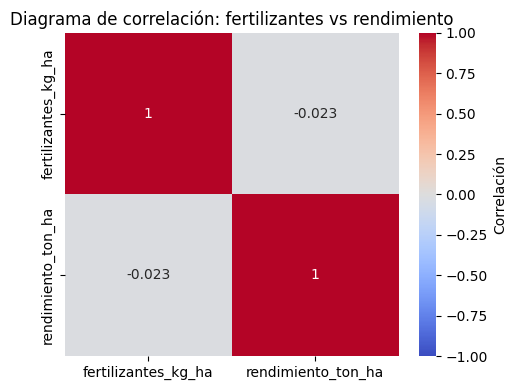

In [8]:
# Análisis de correlación entre fertilizantes y rendimiento.
corr_matrix = fertilizante_rendimiento[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Diagrama de correlación: fertilizantes vs rendimiento')
plt.tight_layout()
plt.show()

##### En el caso del scatterplot donde se muestra la relación previa teniendo en cuenta los distintos cultivos, se puede ver que el rendimiento de la caña de azucar excede por bastante al resto de cultivos, que parecen tener un rendimiento casi nulo. Esto podría ser porque el uso de fertilizantes si que ayuda y aporta al crecimiento de la caña, mientras que al resto no les mejora tanto y por eso la relación previa es baja.

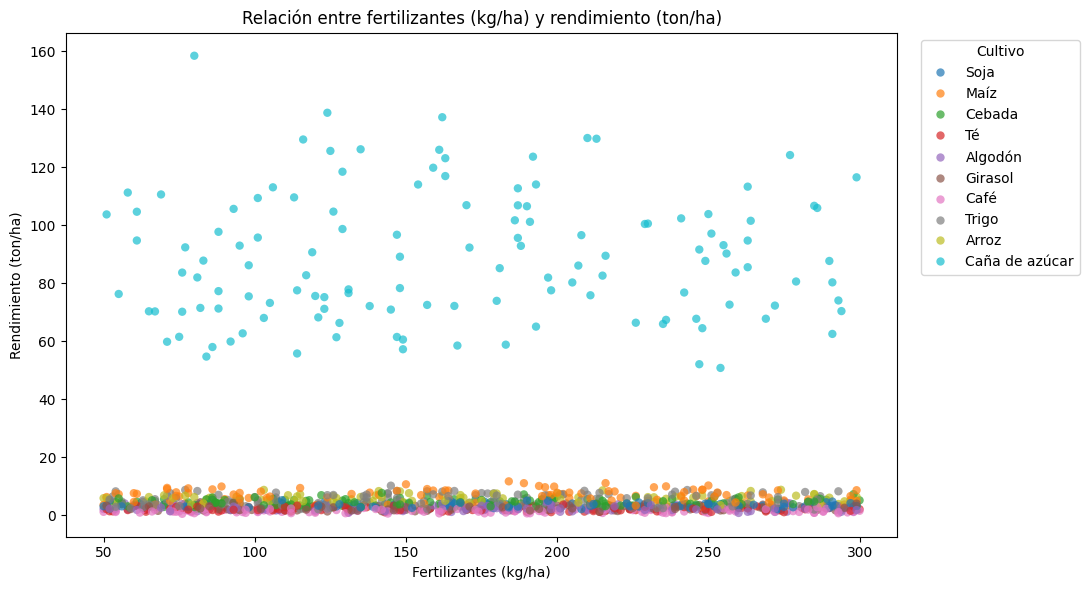

In [9]:
# Visualización de la dispersión general entre fertilizantes y rendimiento.
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=fertilizante_rendimiento,
    x='fertilizantes_kg_ha',
    y='rendimiento_ton_ha',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.title('Relación entre fertilizantes (kg/ha) y rendimiento (ton/ha)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Haciendo un análisis mas exhaustivo de la correlación que hay con cada cultivo, hemos visto que en realidad en el caso de la caña no hay un patrón claro con los estudios previos. Es decir, si bien su rendimiento es superior al resto de cultivos, su correlación con la cantidad de fertilizante y rendimiento es bastante baja por lo que no podemos afirmar que su "alto" rendimiento se deba a ello.

In [10]:
# Cálculo de correlación segmentada por tipo de cultivo.
corr_por_cultivo_fertilizante = []
for cultivo, grupo in fertilizante_rendimiento.groupby('cultivo'):
    corr = grupo['fertilizantes_kg_ha'].corr(grupo['rendimiento_ton_ha'])
    corr_por_cultivo_fertilizante.append({'cultivo': cultivo, 'correlacion': corr, 'muestras': len(grupo)})

corr_por_cultivo_fertilizante = pd.DataFrame(corr_por_cultivo_fertilizante).sort_values('correlacion', ascending=False)
print(corr_por_cultivo_fertilizante)

          cultivo  correlacion  muestras
4          Cebada     0.119962       140
2            Café     0.085235       130
5         Girasol     0.051202       120
3  Caña de azúcar     0.016324       130
7            Soja     0.006739       110
8           Trigo    -0.002747       140
1           Arroz    -0.024686        90
9              Té    -0.037031       110
6            Maíz    -0.065162       110
0         Algodón    -0.092416       120


##### **Conclusión**: En este dataset, la cantidad de fertilizante aplicada no parece ser un buen predictor lineal del rendimiento. Aunque la caña de azúcar muestra rendimientos altos, su correlación con fertilizante sigue siendo baja, por lo que su rendimiento se debe a otros factores más que al fertilizante medido. La variación de rendimiento probablemente se explica mejor con variables adicionales o con análisis estratificado por cultivo, no con un simple fertilizantes_kg_ha vs rendimiento_ton_ha.”

### 3.2 ¿Existe correlación entre superficie cultivada y producción?

##### Preparación del dataset

In [11]:
# Preparación de datos para analizar superficie vs producción.
superficie_produccion = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'superficie_hectareas', 'produccion_ton']
].dropna()

superficie_produccion.head()


,pais,region,cultivo,anio,superficie_hectareas,produccion_ton
0,Argentina,América del Sur,Soja,2011,4703643,10465461
1,Argentina,América del Sur,Maíz,2011,3371781,28485921
2,Argentina,América del Sur,Cebada,2011,1661577,4596917
3,Argentina,América del Sur,Té,2011,188518,577886
4,Argentina,América del Sur,Algodón,2011,1638327,1929756


##### Comprobación de nulos

In [12]:
# Detección de anomalías en la producción por país y cultivo.
superficie_produccion.isna().sum()

pais                    0
region                  0
cultivo                 0
anio                    0
superficie_hectareas    0
produccion_ton          0
dtype: int64

##### La correlación entre la superficie cultivada y la producción tienen una correlación media y positiva. En un primer vistazo se podría decir que a mayor superficie cultivada, mayor producción. Al ser correlación media puede que existan otros factores que afecten.

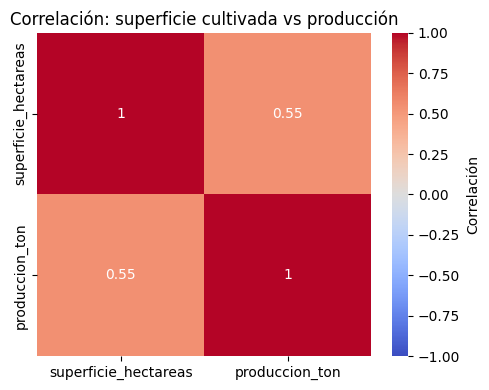

In [13]:
# Correlación entre superficie cultivada y producción total.
corr_matrix = superficie_produccion[['superficie_hectareas', 'produccion_ton']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Correlación: superficie cultivada vs producción')
plt.tight_layout()
plt.show()

##### Al hacer un gráfico de correlación tomando en cuenta más variables hemos descubierto que el rendimiento está estrechamente correlacionado a la producción. Una vez resolvamos la cuestión propuesta estudiaremos este caso.

<Axes: >

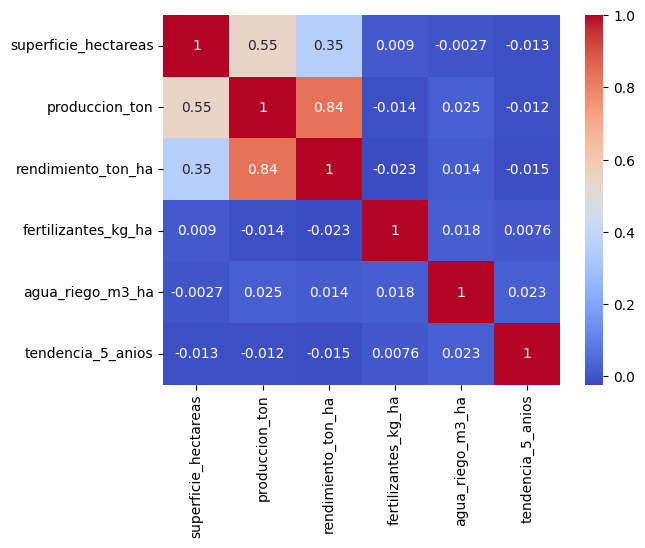

In [14]:
# Configuración de variables para el análisis de dispersión superficie/producción.
vars_estudio = [
    'superficie_hectareas',
    'produccion_ton',
    'rendimiento_ton_ha',
    'fertilizantes_kg_ha',
    'agua_riego_m3_ha',
    'tendencia_5_anios'
]
sub = datasets['produccion_agricola'][vars_estudio].dropna()
sns.heatmap(sub.corr(), annot=True, cmap='coolwarm')

##### El scatterplot confirma que a mayor hectáreas de cultivo, mayor es su producción. Nuevamente la caña de azucar sobresale del resto de cultivos en la gráfica, lo que ya nos puede ir indicando que es el cultivo que mejor rendimiento tiene.

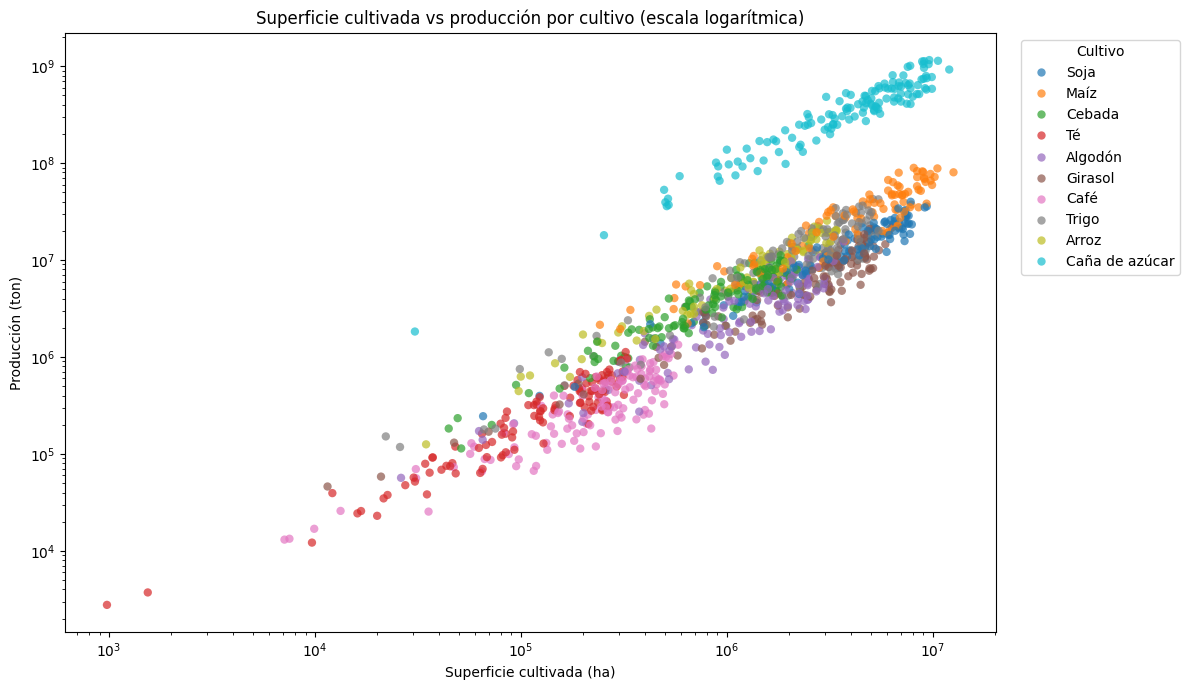

In [15]:
# Gráfico de dispersión superficie vs producción.
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=superficie_produccion,
    x='superficie_hectareas',
    y='produccion_ton',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.xscale('log')
plt.yscale('log')
plt.title('Superficie cultivada vs producción por cultivo (escala logarítmica)')
plt.xlabel('Superficie cultivada (ha)')
plt.ylabel('Producción (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Al trazar una línea sobre el gráfico anterior podemos comprobar que la relación es consistente y se ajusta bastante a los datos. Se puede comprobar como la caña de azúcar sobresale, casi como un outlier, ya que produce mucho más que el resto.

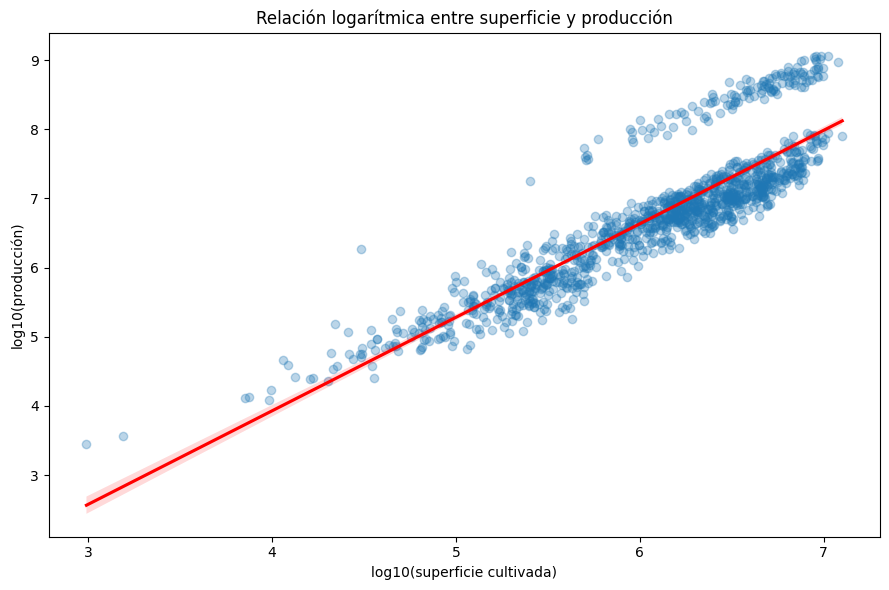

In [16]:
# Transformación logarítmica para manejar la escala de los datos de superficie.
log_superficie = np.log10(superficie_produccion['superficie_hectareas'])
log_produccion = np.log10(superficie_produccion['produccion_ton'])

plt.figure(figsize=(9, 6))
sns.regplot(
    x=log_superficie,
    y=log_produccion,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Relación logarítmica entre superficie y producción')
plt.xlabel('log10(superficie cultivada)')
plt.ylabel('log10(producción)')
plt.tight_layout()
plt.show()

##### Al estudiar también en este caso la correlación individual de cada cultivo, terminamos de asegurar que claramente la superficie afecta en gran medida a la producción de ese tipo de cultivo.

In [17]:
# Correlación por cultivo entre superficie y producción.
corr_por_cultivo_superficie = []
for cultivo, grupo in superficie_produccion.groupby('cultivo'):
    corr = grupo['superficie_hectareas'].corr(grupo['produccion_ton'])
    corr_por_cultivo_superficie.append({'cultivo': cultivo, 'correlacion': corr, 'muestras': len(grupo)})

corr_por_cultivo_superficie = pd.DataFrame(corr_por_cultivo_superficie).sort_values('correlacion', ascending=False)
print(corr_por_cultivo_superficie)

          cultivo  correlacion  muestras
1           Arroz     0.930776        90
7            Soja     0.926807       110
3  Caña de azúcar     0.897172       130
4          Cebada     0.880106       140
9              Té     0.879218       110
6            Maíz     0.875522       110
5         Girasol     0.872805       120
0         Algodón     0.849956       120
2            Café     0.788033       130
8           Trigo     0.784814       140


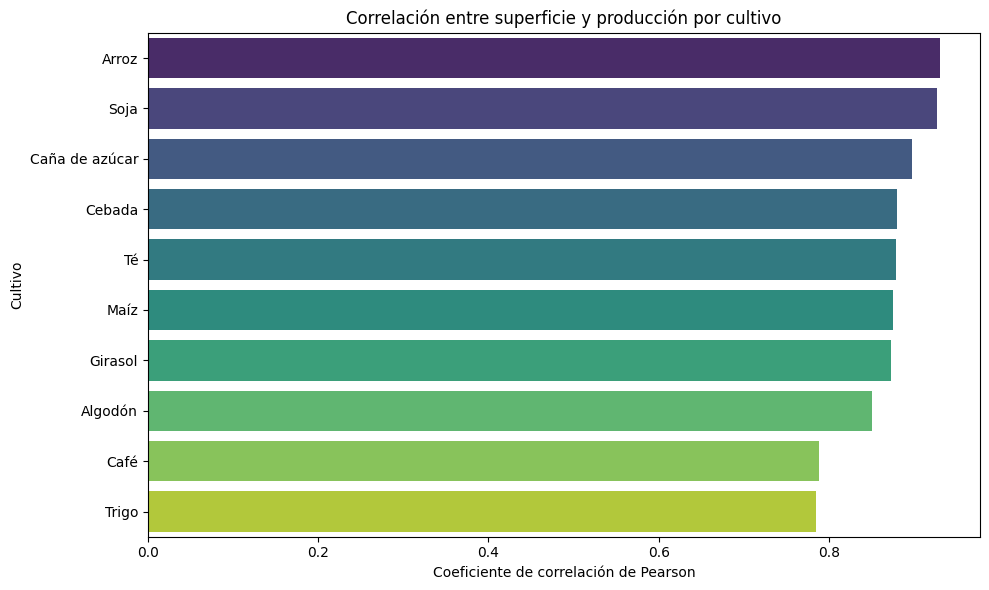

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_por_cultivo_superficie,
    x='correlacion',
    y='cultivo',
    hue='cultivo',
    palette='viridis',
    dodge=False,
    legend=False
)
plt.title('Correlación entre superficie y producción por cultivo')
plt.xlabel('Coeficiente de correlación de Pearson')
plt.ylabel('Cultivo')
plt.tight_layout()
plt.show()

##### **Conclusión**: Se ha confirmado una correlación positiva en este caso, por lo que podemos asegurar que a mayor superficie cultivada, mayor es también la producción que obtenemos.

### 3.3 Tendencias de producción por país y cultivo

##### En esta sección se analizan las tendencias de producción total por país y por cultivo a lo largo del tiempo. Primero preparamos el dataset.

In [19]:
# Agregación de producción por país y año.
produccion = datasets['produccion_agricola'][
    ['pais', 'cultivo', 'anio', 'produccion_ton']
].dropna()

produccion_pais = (
    produccion[produccion['pais'].notnull()]
    .groupby(['anio', 'pais'])['produccion_ton']
    .sum()
    .reset_index()
)
produccion_cultivo = (
    produccion[produccion['cultivo'].notnull()]
    .groupby(['anio', 'cultivo'])['produccion_ton']
    .sum()
    .reset_index()
)

##### Haciendo un primer gráfico de tendencia, podemos comprobar como paises como China o Brasil parecen tener una capacidad de producción mucho mayor que el resto de paises. También se puede visualizar una alta volatilidad del mercado con picos pronunciados. Otros paises como Argentina tienen una producción más baja pero estable. En el año 2018 se puede observar una gran bajada general del mercado con picos mínimos pronunciados, mientras que en el 2019 se produce una gran crecida de la producción. Esto podría deberse a cambios climáticos, de demanda general en el mercado, etc.

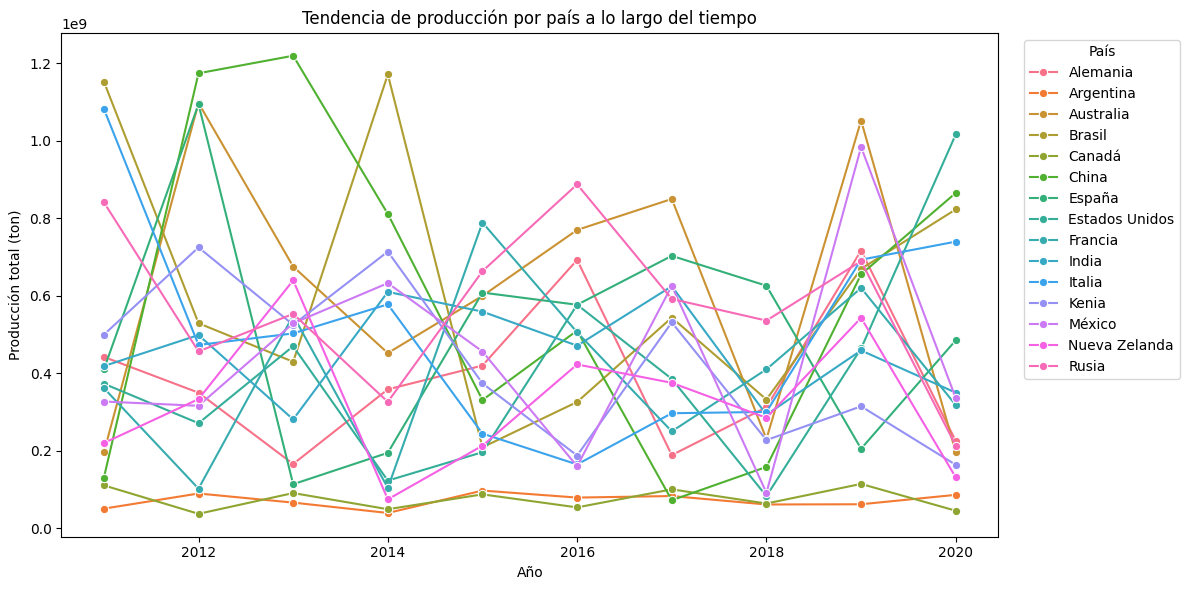

In [20]:
# Evolución temporal de la producción por país.
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=produccion_pais,
    x='anio',
    y='produccion_ton',
    hue='pais',
    marker='o'
)
plt.title('Tendencia de producción por país a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Escogemos unos paises concretos para obtener un gráfico más limpio. Podemos ver que con los seleccionados en este caso en concreto en el último tramo estudiado están al alza pero las conclusiones en este caso son las mismas, mucha volatilidad de mercado.

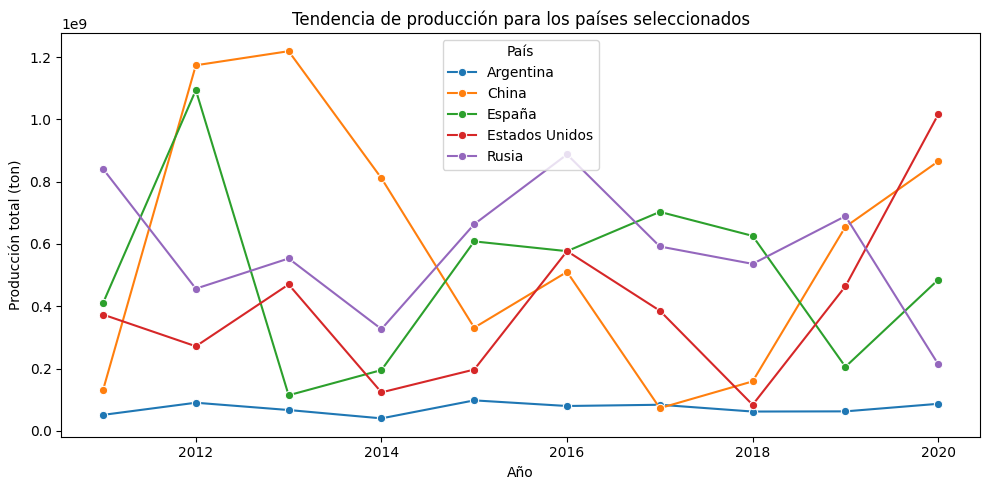

In [21]:
# Análisis detallado para países seleccionados.
paises_seleccionados = ['China', 'Estados Unidos', 'Rusia', 'Argentina', 'España']
produccion_pais_filtrado = produccion_pais[produccion_pais['pais'].isin(paises_seleccionados)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=produccion_pais_filtrado,
    x='anio',
    y='produccion_ton',
    hue='pais',
    marker='o'
)
plt.title('Tendencia de producción para los países seleccionados')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='País')
plt.tight_layout()
plt.show()

##### En la tendencia de producción por cultivo, como hemos repetido en varias ocasiones, se observa que la caña de azucar es el cultivo con mayor productividad de todos. El gráfico se encuentra sesgado ya que 1 solo cultivo ocupa la mayoría de la producción del mercado. El resto de cultivos son más estables aunque mucho más reducidos en cantidad. Nuevamente, se pueden observar picos en los años 2018-2019 que podrían deberse a factores climáticos, cambios en demanda o políticas agrarias.

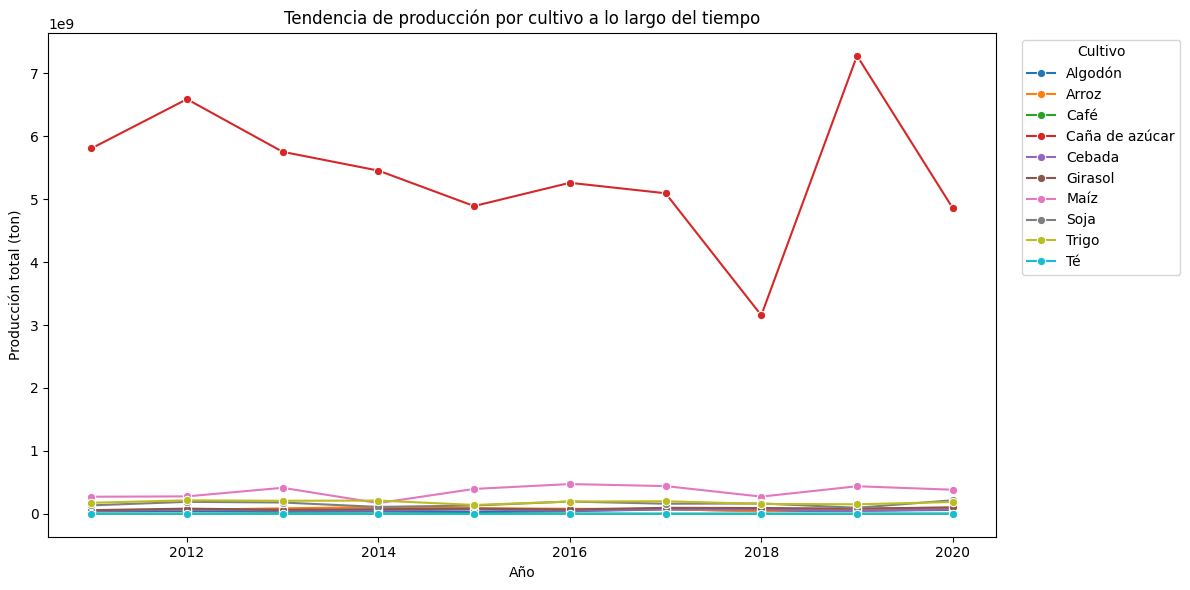

In [22]:
# Producción total por país (Top 10).
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=produccion_cultivo,
    x='anio',
    y='produccion_ton',
    hue='cultivo',
    marker='o'
)
plt.title('Tendencia de producción por cultivo a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Se puede comprobar como en las gráficas anteriores, los paises Argentina y Canadá tienen una gráfica mucho mas reducida en terminos de producción que los otros paises. Esto se puede deber a que se comprueba como estos paises no cultivan caña de azucar 

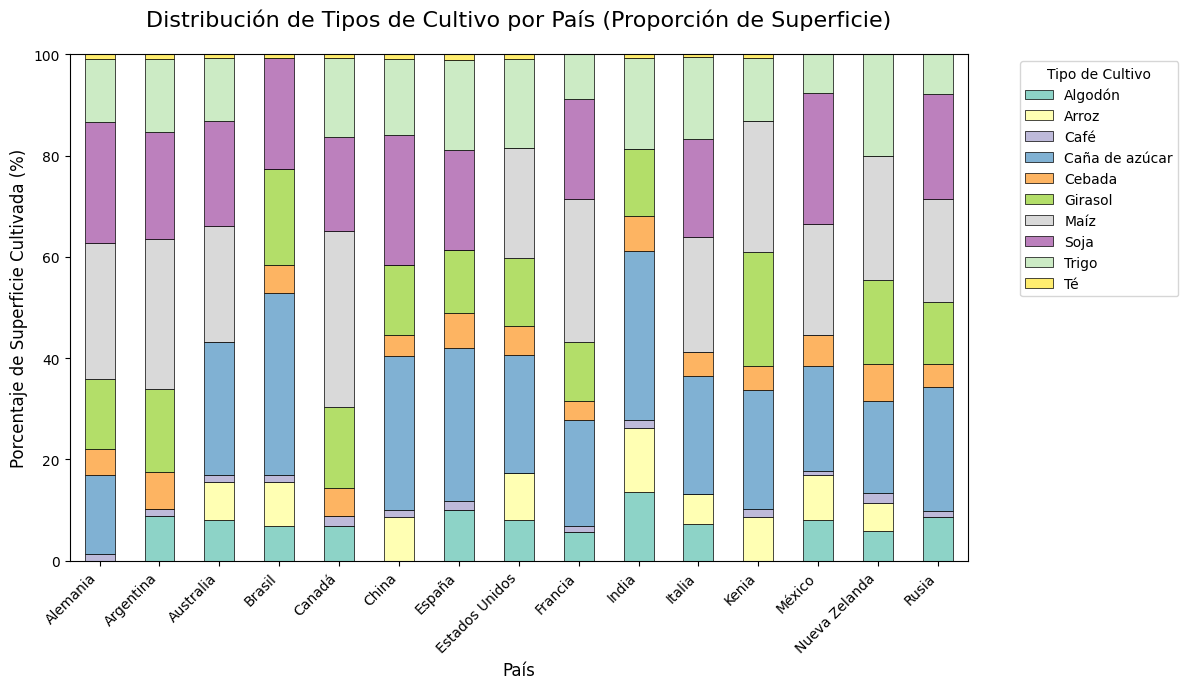

In [23]:
# Mapeo de nombres de cultivos para estandarización.
df = datasets['produccion_agricola']
# 1. Agrupar por país y cultivo, sumando la superficie total a lo largo de los años
df_agg = df.groupby(['pais', 'cultivo'])['superficie_hectareas'].sum().unstack().fillna(0)
# 2. Convertir a porcentaje para ver la distribución relativa (todo suma 100% por país)
df_porcentaje = df_agg.div(df_agg.sum(axis=1), axis=0) * 100
# 3. Crear y configurar la figura
fig, ax = plt.subplots(figsize=(12, 7))
df_porcentaje.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='black', linewidth=0.5)
# 4. Personalizar textos y ejes
plt.title('Distribución de Tipos de Cultivo por País (Proporción de Superficie)', fontsize=16, pad=20)
plt.xlabel('País', fontsize=12)
plt.ylabel('Porcentaje de Superficie Cultivada (%)', fontsize=12)
# Mover la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Tipo de Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Mostrar gráfico
plt.show()

##### **Conclusion**: Los datos muestran una producción inestable, con caidas y subidas bruscas de la productividad. Algunos paises tienen un nivel de producción muy alto en años concretos, mientras que otros se mantienen más bajos y estables. Los factores externos tales como los climaticos, políticos o cambios en demanda pueden estar afectando éstas medidas, se necesita realizar un análisis de series temporales para poder sacar conclusiones más acertadas.

### 3.4 Detección de anomalías en series temporales

*   **Análisis de anomalías:** En esta sección aplicamos un método estadístico (z-score) para identificar qué años han sufrido picos o caídas drásticas en la producción. Como hemos visto en conclusiones previas, la producción es inestable y este análisis nos permite detectar en qué momentos ocurren estos sucesos, ayudándonos a confirmar la alta volatilidad del mercado.

In [24]:
# Filtrado de datos de producción para el análisis de clusters.
produccion = datasets['produccion_agricola'][
    ['anio', 'pais', 'cultivo', 'produccion_ton']
].dropna()

produccion_pais = (
    produccion.groupby(['anio', 'pais'])['produccion_ton']
    .sum()
    .reset_index()
    .sort_values(['pais', 'anio'])
)
produccion_cultivo = (
    produccion.groupby(['anio', 'cultivo'])['produccion_ton']
    .sum()
    .reset_index()
    .sort_values(['cultivo', 'anio'])
)


def add_zscore_anomaly(df, group_col, threshold=1.5):
    frames = []
    for _, group in df.groupby(group_col):
        g = group.copy()
        z = (g['produccion_ton'] - g['produccion_ton'].mean()) / g['produccion_ton'].std(ddof=0)
        g['z_score'] = z
        g['anomaly'] = z.abs() > threshold
        frames.append(g)
    return pd.concat(frames, ignore_index=True)

produccion_pais = add_zscore_anomaly(produccion_pais, 'pais')
produccion_cultivo = add_zscore_anomaly(produccion_cultivo, 'cultivo')

print('Anomalías detectadas por país:')
print(produccion_pais[produccion_pais['anomaly']].sort_values(['pais', 'anio']).head(10))
print('\nAnomalías detectadas por cultivo:')
print(produccion_cultivo[produccion_cultivo['anomaly']].sort_values(['cultivo', 'anio']).head(10))

Anomalías detectadas por país:
    anio            pais  produccion_ton   z_score  anomaly
5   2016        Alemania       692610614  1.685645     True
8   2019        Alemania       716530243  1.817782     True
13  2014       Argentina        39988861 -1.824109     True
21  2012       Australia      1097272038  1.511526     True
30  2011          Brasil      1152265497  1.672355     True
33  2014          Brasil      1170831134  1.730543     True
52  2013           China      1219148006  1.564035     True
61  2012          España      1094119337  2.141889     True
79  2020  Estados Unidos      1016150113  2.421956     True
84  2015         Francia       788984158  1.849147     True

Anomalías detectadas por cultivo:
    anio         cultivo  produccion_ton   z_score  anomaly
6   2017         Algodón        72613141  2.118343     True
13  2014           Arroz       110812706  1.574192     True
17  2018           Arroz        42783154 -1.999642     True
29  2020            Café         6

*   **Gráfico de anomalías en la producción por país:** Al visualizar las anomalías en el gráfico, podemos comprobar cómo ciertos países presentan picos muy marcados en años concretos. Por ejemplo, se evidencia que Argentina sufrió una caída en su producción durante 2014, mientras que países como Alemania, España o Estados Unidos han presentado años con picos inusualmente altos de producción. Estas caídas o subidas repentinas podrían estar justificadas por eventos climáticos extremos o cambios drásticos en las políticas agrícolas locales.

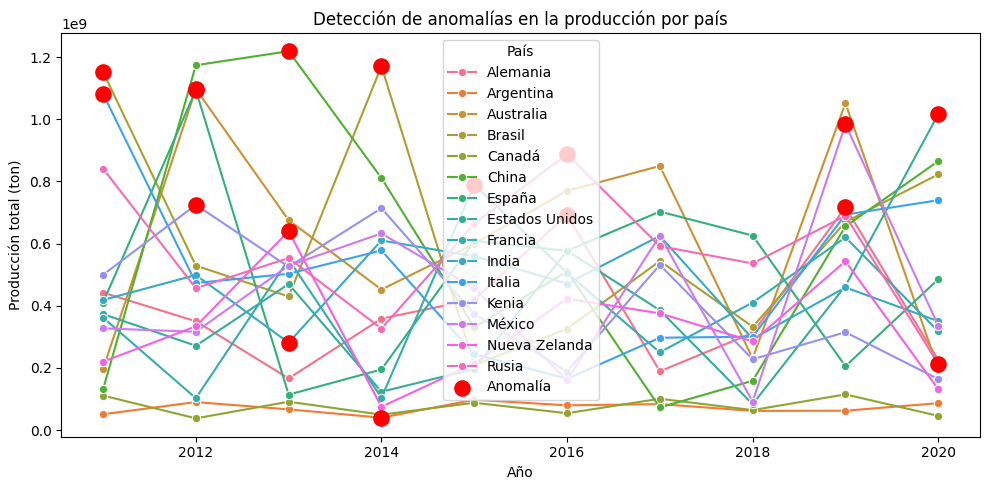

Años anómalos detectados:
               pais  anio  produccion_ton   z_score
5          Alemania  2016       692610614  1.685645
8          Alemania  2019       716530243  1.817782
13        Argentina  2014        39988861 -1.824109
21        Australia  2012      1097272038  1.511526
30           Brasil  2011      1152265497  1.672355
33           Brasil  2014      1170831134  1.730543
52            China  2013      1219148006  1.564035
61           España  2012      1094119337  2.141889
79   Estados Unidos  2020      1016150113  2.421956
84          Francia  2015       788984158  1.849147
92            India  2013       281247799 -1.513210
100          Italia  2011      1082067041  2.173972
111           Kenia  2012       724861518  1.534400
128          México  2019       983728502  2.171425
132   Nueva Zelanda  2013       639910930  1.874416
145           Rusia  2016       887521163  1.561600
149           Rusia  2020       213876958 -1.815654


In [25]:
# Preparación de datos climáticos para clustering.
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=produccion_pais,
    x='anio',
    y='produccion_ton',
    hue='pais',
    marker='o'
)

anomalies = produccion_pais[produccion_pais['anomaly']]
plt.scatter(
    anomalies['anio'],
    anomalies['produccion_ton'],
    color='red',
    s=120,
    label='Anomalía',
    zorder=5
)
plt.title('Detección de anomalías en la producción por país')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='País')
plt.tight_layout()
plt.show()

print('Años anómalos detectados:')
print(anomalies[['pais', 'anio', 'produccion_ton', 'z_score']].sort_values(['pais', 'anio']))

*   **Anomalías por cultivo:** Observando los datos a nivel de cultivo, comprobamos que también sufren cambios de producción severos. Por ejemplo, la caña de azúcar presenta una fuerte caída en 2018, pero también picos altos en otros años, al igual que la caña de azúcar o el maíz. Esto vuelve a indicar que la producción agrícola es muy vulnerable a factores externos, reafirmando que no se mantiene estable a lo largo del tiempo.

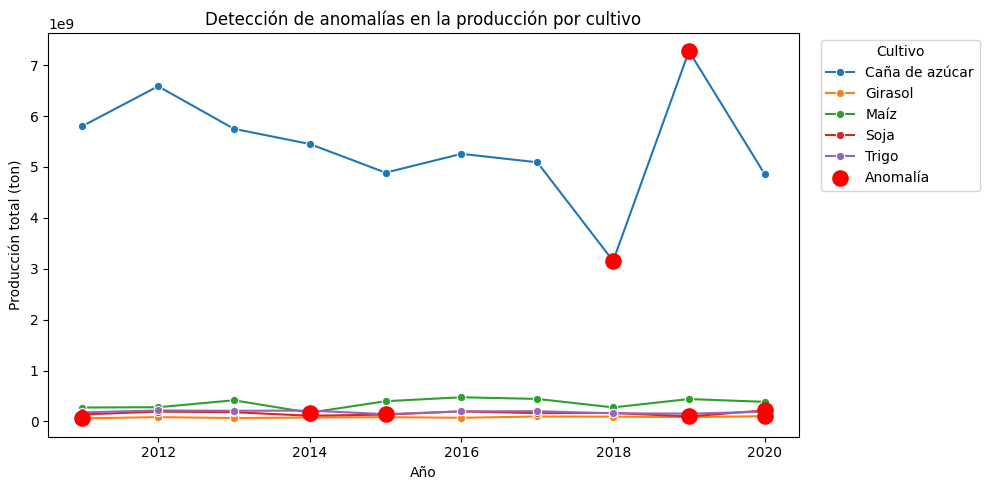

Años anómalos detectados para los cultivos top:
           cultivo  anio  produccion_ton   z_score
37  Caña de azúcar  2018      3154126781 -2.159338
38  Caña de azúcar  2019      7274705042  1.783179
50         Girasol  2011        60561272 -1.689457
59         Girasol  2020       103657218  1.604520
63            Maíz  2014       172703191 -1.956376
78            Soja  2019        98403573 -1.669801
79            Soja  2020       217657295  1.556136
84           Trigo  2015       143068861 -1.724713


In [26]:
# Ejecución de K-Means para segmentación agroclimática.
cultivos_top = (
    produccion.groupby('cultivo')['produccion_ton']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
cultivo_filtrado = produccion_cultivo[produccion_cultivo['cultivo'].isin(cultivos_top)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cultivo_filtrado,
    x='anio',
    y='produccion_ton',
    hue='cultivo',
    marker='o'
)

anomalies_cultivo = cultivo_filtrado[cultivo_filtrado['anomaly']]
plt.scatter(
    anomalies_cultivo['anio'],
    anomalies_cultivo['produccion_ton'],
    color='red',
    s=120,
    label='Anomalía',
    zorder=5
)
plt.title('Detección de anomalías en la producción por cultivo')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Años anómalos detectados para los cultivos top:')
print(anomalies_cultivo[['cultivo', 'anio', 'produccion_ton', 'z_score']].sort_values(['cultivo', 'anio']))

##### **Conclusión**: El método de detección de anomalías nos ha confirmado lo que ya observabamos: el mercado agrícola es sumamente volátil y propenso a cambios bruscos. Tanto a nivel de país como de cultivo, encontramos picos y caídas repentinas que salen completamente de la normalidad. Esto refuerza la idea de que la producción no depende únicamente de factores estables a lo largo del tiempo (como la cantidad de fertilizante o superficie cultivada), sino que intervienen eventos externos (probablemente eventos climáticos extremos o cambios en las políticas) que alteran drásticamente los rendimientos esperados de un año para otro.

### 3.5 Identificación de patrones estacionales

*   **Análisis de estacionalidad y autocorrelación:** Al trabajar con datos anuales es difícil detectar la estacionalidad clásica (que normalmente se mide en meses o estaciones), pero podemos calcular la autocorrelación y la variación año tras año. Esto nos permitirá comprobar si la producción agrícola sigue ciclos regulares y predecibles (por ejemplo, si un buen año siempre va seguido de uno malo) o si se comporta de forma totalmente errática.

In [27]:
# Top países y cultivos para análisis de patrones
top_paises = produccion_pais.groupby('pais')['produccion_ton'].sum().nlargest(5).index
top_cultivos = produccion_cultivo.groupby('cultivo')['produccion_ton'].sum().nlargest(5).index

pais_seasonal = produccion_pais[produccion_pais['pais'].isin(top_paises)].copy()
pais_seasonal['pct_change'] = pais_seasonal.groupby('pais')['produccion_ton'].pct_change() * 100

cultivo_seasonal = produccion_cultivo[produccion_cultivo['cultivo'].isin(top_cultivos)].copy()
cultivo_seasonal['pct_change'] = cultivo_seasonal.groupby('cultivo')['produccion_ton'].pct_change() * 100

pais_autocorr = pais_seasonal.groupby('pais')['produccion_ton'].apply(lambda s: s.autocorr(lag=1))
cultivo_autocorr = cultivo_seasonal.groupby('cultivo')['produccion_ton'].apply(lambda s: s.autocorr(lag=1))

print('Autocorrelación lag 1 por país:')
print(pais_autocorr)
print('\nAutocorrelación lag 1 por cultivo:')
print(cultivo_autocorr)

Autocorrelación lag 1 por país:
pais
Australia   -0.719703
Brasil      -0.259613
China        0.325545
Italia       0.341734
Rusia       -0.170997
Name: produccion_ton, dtype: float64

Autocorrelación lag 1 por cultivo:
cultivo
Caña de azúcar   -0.329766
Girasol           0.116547
Maíz             -0.151033
Soja             -0.397916
Trigo            -0.012807
Name: produccion_ton, dtype: float64


*   **Autocorrelación lag 1 (Países y Cultivos):** Revisando los resultados de autocorrelación, comprobamos que países como Australia (-0.71) o Brasil (-0.25) tienen una fuerte correlación negativa, lo que sugiere un comportamiento de rebote: a un año de alta producción le suele seguir una caída abrupta. Por el contrario, China o Italia muestran una leve correlación positiva, indicando tendencias productivas un poco más consistentes. En cuanto a los cultivos, la mayoría (como la soja o la caña de azúcar) muestran valores negativos, reflejando su inestabilidad interanual.

*   **Gráficos de cambio porcentual interanual:** Al visualizar las variaciones en las gráficas, confirmamos esta falta de ciclos estables tanto en paises como en tipos de cultivo. Vemos constantes cruces de la línea de crecimiento cero, con picos muy pronunciados tanto positivos como negativos que fluctúan sin un patrón predecible claro.

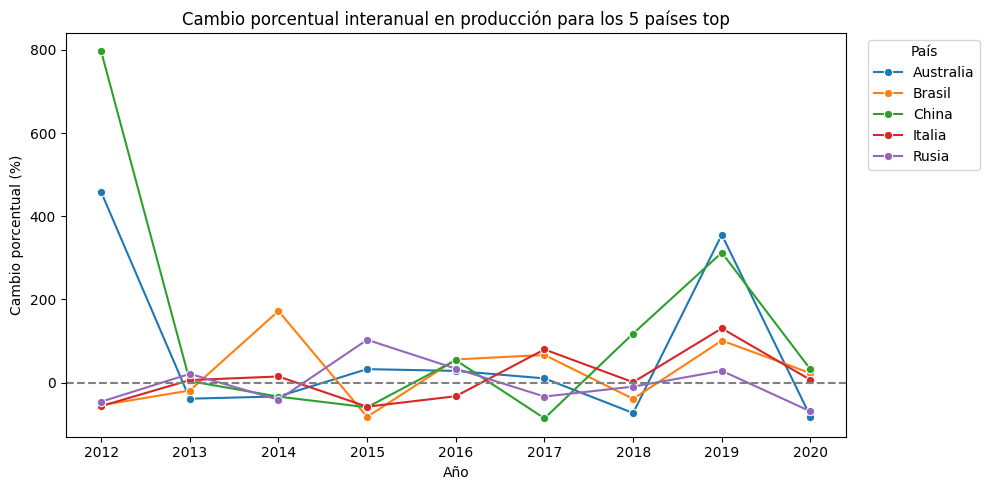

In [28]:
# Visualización de los clusters climáticos.
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=pais_seasonal,
    x='anio',
    y='pct_change',
    hue='pais',
    marker='o'
)
plt.title('Cambio porcentual interanual en producción para los 5 países top')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual (%)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

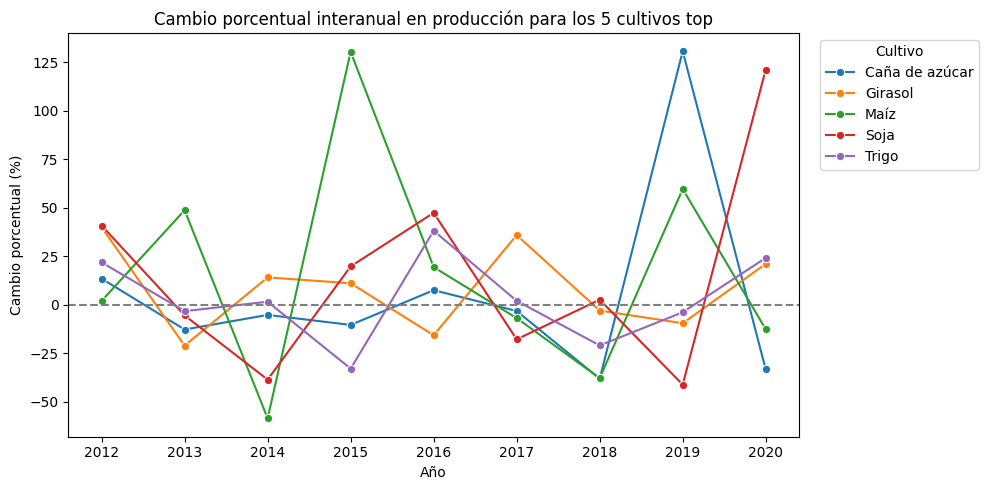

In [29]:
# Análisis de la distribución de clusters.
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cultivo_seasonal,
    x='anio',
    y='pct_change',
    hue='cultivo',
    marker='o'
)
plt.title('Cambio porcentual interanual en producción para los 5 cultivos top')
plt.xlabel('Año')
plt.ylabel('Cambio porcentual (%)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

##### **Conclusión**: El análisis de variación interanual confirma que no existe una estacionalidad anual marcada ni patrones repetitivos fiables. La alta volatilidad observada demuestra que la producción agrícola está afectada en gran medida por factores externos impredecibles (como catástrofes climáticas extremas o shocks del mercado), haciendo que el rendimiento de un año no sea una garantía sólida para predecir el del año siguiente.

### 3.6 Clusterización de países por patrones productivos

*   **Agrupación de países por comportamiento:** En esta sección aplicamos K-Means sobre las series temporales de producción anual. El objetivo es identificar si existen grupos de países que compartan tendencias productivas similares, permitiéndonos ver qué paises se comportan de manera similar frente a los cambios del mercado.

In [30]:
# Pivotado de datos para análisis de series temporales de producción.
pais_features = produccion_pais.pivot(index='pais', columns='anio', values='produccion_ton').fillna(0)

scaler = StandardScaler()
pais_scaled = scaler.fit_transform(pais_features)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pais_clusters = kmeans.fit_predict(pais_scaled)

pais_cluster_df = pd.DataFrame({
    'pais': pais_features.index,
    'cluster': pais_clusters
}).set_index('pais')

print('Número de países por cluster:')
print(pais_cluster_df['cluster'].value_counts().sort_index())

print('\nPaíses en cada cluster:')
print(pais_cluster_df.reset_index().groupby('cluster')['pais'].apply(list))

pais_profiles = pais_features.join(pais_cluster_df)
cluster_means = pais_profiles.groupby('cluster').mean()
print('\nPerfil medio de producción por cluster:')
print(cluster_means)

Número de países por cluster:
cluster
0     3
1    10
2     2
Name: count, dtype: int64

Países en cada cluster:
cluster
0                              [Brasil, China, Italia]
1    [Alemania, Australia, España, Estados Unidos, ...
2                                  [Argentina, Canadá]
Name: pais, dtype: object

Perfil medio de producción por cluster:
                 2011          2012          2013         2014          2015  \
cluster                                                                        
0        7.884072e+08  7.255197e+08  7.173843e+08  853359458.0  2.617587e+08   
1        4.092346e+08  5.246105e+08  4.504280e+08  359300950.0  4.881016e+08   
2        8.118388e+07  6.402013e+07  7.907973e+07   44843845.5  9.287603e+07   

                 2016         2017          2018          2019         2020  
cluster                                                                      
0        3.339444e+08  304626809.0  2.640215e+08  6.727218e+08  809301043.0  
1        5.2

*   **Análisis de Clusters (Grupos de Países):** Al analizar los tres grupos generados, observamos diferencias muy claras en las capacidades y tendencias productivas:
    *   **Cluster 0 (Grandes Productores Volátiles):** Incluye a Brasil, China e Italia. Estos países tienen los niveles de producción media más altos (alcanzando los 800 millones de toneladas), pero sufren caídas masivas en ciertos años (como en 2015 o 2018), lo que indica que, a pesar de su gran capacidad, asumen un alto riesgo de volatilidad.
    *   **Cluster 1 (Productores Medios):** Agrupa a la gran mayoría de países (Alemania, EE.UU., India, etc.). Mantienen un volumen de producción intermedio (alrededor de 400-500 millones), con cambios moderados pero constantes a lo largo de la década estudiada.
    *   **Cluster 2 (Bajos Productores):** Formado por Argentina y Canadá. Tienen los volúmenes de producción más bajos del conjunto (por debajo de los 100 millones de toneladas). Aunque sufrieron una caída remarcable en 2014, su gráfica de producción es mucho más plana en términos absolutos comparada con los grandes gigantes agrícolas.

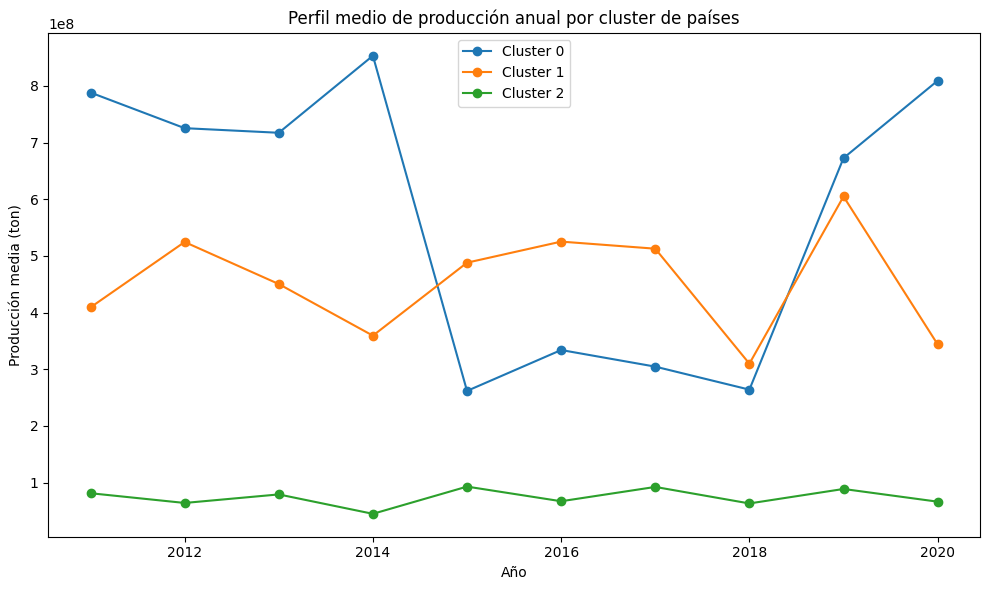

In [31]:
# Visualización de tendencias de producción.
plt.figure(figsize=(10, 6))
for cluster_id, perfil in cluster_means.iterrows():
    plt.plot(perfil.index, perfil.values, marker='o', label=f'Cluster {cluster_id}')

plt.title('Perfil medio de producción anual por cluster de países')
plt.xlabel('Año')
plt.ylabel('Producción media (ton)')
plt.legend()
plt.tight_layout()
plt.show()

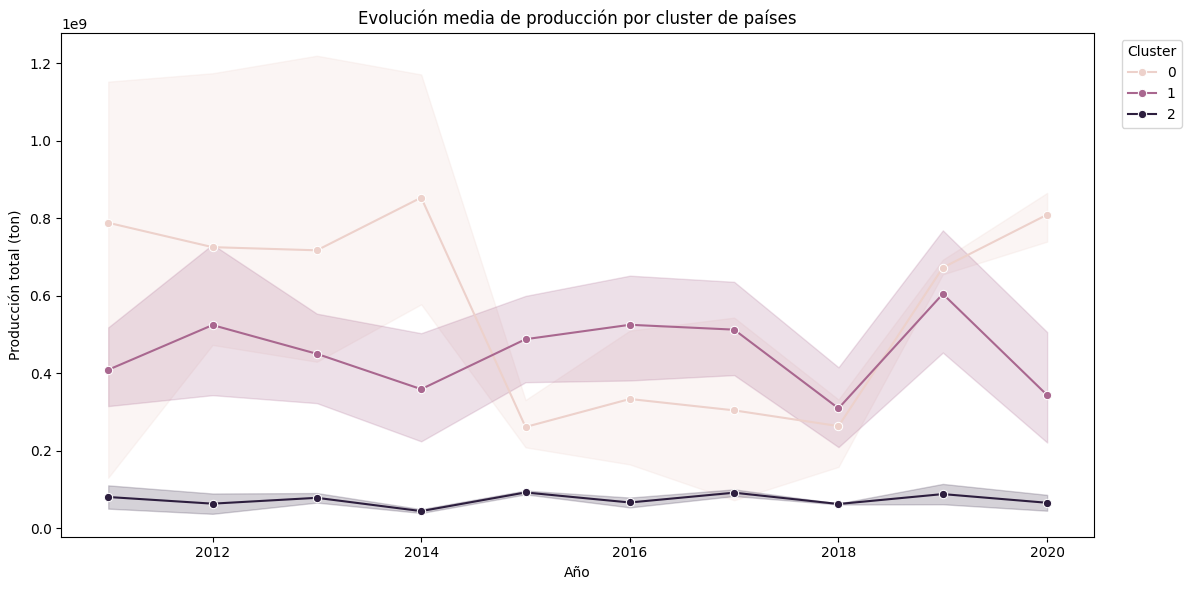

In [32]:
# Análisis de correlación clima-producción.
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pais_profiles.reset_index().melt(id_vars=['pais', 'cluster'], var_name='anio', value_name='produccion_ton'),
    x='anio',
    y='produccion_ton',
    hue='cluster',
    estimator='mean',
    marker='o'
)
plt.title('Evolución media de producción por cluster de países')
plt.xlabel('Año')
plt.ylabel('Producción total (ton)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### **Conclusión**: El modelo de clustering nos demuestra que el mercado está fuertemente estratificado. Los mayores productores del mundo (Cluster 0) dictan los grandes techos del mercado global, pero son exactamente los mismos que sufren las peores caidas, arrastrando la media global. Por otro lado, los países de menor producción como Argentina y Canadá, aunque no lideran en volumen, son más estables y tienen una producción casi constante. Esto nos indica que las futuras políticas internacionales deberían enfocarse especialmente en estabilizar y proteger la producción de los países líderes para garantizar una seguridad alimentaria global constante.

### 3.7 Frecuencia de sequías/inundaciones por región

*   **Análisis de eventos climáticos extremos:** En esta sección calculamos frecuencia de eventos climáticos (sequías e inundaciones) registradas por región. Dado que ya hemos comprobado cómo ciertos eventos externos desploman la producción en nuestros modelos anteriores, es importante identificar qué zonas geográficas están asumiendo el mayor riesgo.

In [33]:
# Conteo de eventos climáticos extremos.
clima = datasets['condiciones_climaticas'].copy()
clima['evento'] = clima['regiones_eventos_extremos'].fillna('').str.strip()

# Seleccionar solo los eventos de interés: sequías e inundaciones.
evento_map = {
    'sequia_extrema': 'sequía',
    'sequia_moderada': 'sequía',
    'sequia_severa': 'sequía',
    'inundacion': 'inundación'
}
clima = clima[clima['evento'].isin(evento_map)]
clima['tipo_evento'] = clima['evento'].map(evento_map)

# Conteo total por región y tipo de evento
freq_region = (
    clima.groupby(['regiones_nombre', 'tipo_evento'])['evento']
    .count()
    .reset_index(name='conteo')
    .sort_values(['regiones_nombre', 'tipo_evento'])
)

# Conteo por región y año para ver la evolución
freq_region_year = (
    clima.groupby(['regiones_nombre', 'regiones_anio', 'tipo_evento'])['evento']
    .count()
    .reset_index(name='conteo')
)

print('Frecuencia de sequías e inundaciones por región:')
print(freq_region.pivot(index='regiones_nombre', columns='tipo_evento', values='conteo').fillna(0).sort_values('sequía', ascending=False).head(15))

Frecuencia de sequías e inundaciones por región:
tipo_evento           inundación  sequía
regiones_nombre                         
Región Principal             2.0    11.0
Ganges                       2.0     6.0
Patagonia                    0.0     4.0
Queensland Coast             2.0     4.0
Punjab                       0.0     3.0
Great Plains                 0.0     3.0
Amazonía                     0.0     3.0
Wheatbelt                    1.0     3.0
Corn Belt                    1.0     2.0
Cerrado                      0.0     2.0
Deccan                       1.0     2.0
Mata Atlántica               1.0     2.0
California                   0.0     1.0
Pampa Húmeda                 0.0     1.0
Murray-Darling Basin         1.0     0.0


*   **Frecuencia de desastres por región:** Los resultados del conteo evidencian una clara desproporción en el castigo climático. La "Región Principal" es, con una diferencia alarmante, la más afectada, acumulando 11 eventos de sequía extrema/severa y 2 inundaciones. Le sigue la región del Ganges (6 sequías). Además, al observar la gráfica vemos que la sequía es una amenaza muchísimo más frecuente, destructiva y global que las inundaciones para la agricultura.

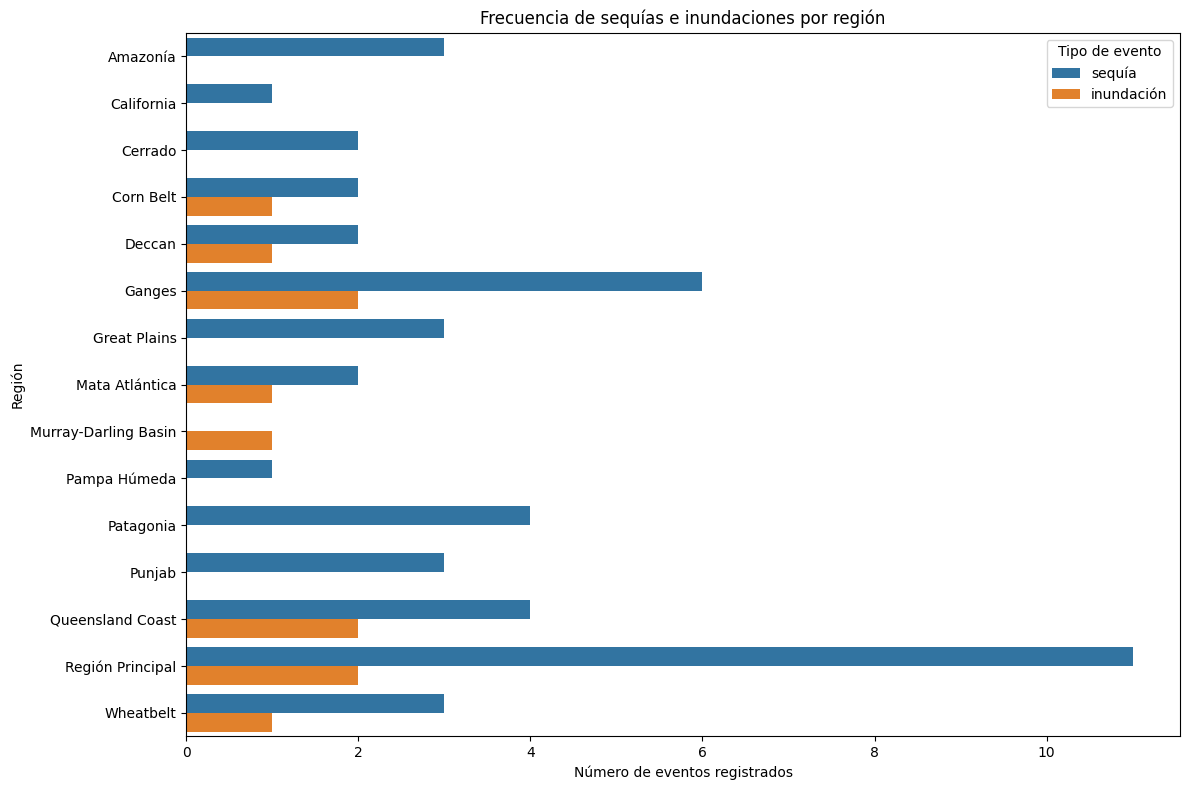

In [34]:
# Visualización de frecuencia de sequías e inundaciones.
plt.figure(figsize=(12, 8))
sns.barplot(
    data=freq_region,
    x='conteo',
    y='regiones_nombre',
    hue='tipo_evento'
)
plt.title('Frecuencia de sequías e inundaciones por región')
plt.xlabel('Número de eventos registrados')
plt.ylabel('Región')
plt.legend(title='Tipo de evento')
plt.tight_layout()
plt.show()

*   **Evolución anual en las regiones más afectadas:** Al observar la línea de tiempo de estos eventos en el gráfico, comprobamos que el problema no se limita a grandes picos aislados. La "Región Principal", por ejemplo, muestra una incidencia crónica, registrando sequías en casi todos los años analizados. Regiones como el Ganges o la Patagonia también muestran un goteo constante de eventos severos a lo largo de la década. Nuevamente se comprueba que la sequía es el evento que más afecta a los paises y que es casi un dado el hecho de dedir 'este año hay sequía', por tanto los paises deberían adaptarse a estos supuestos.

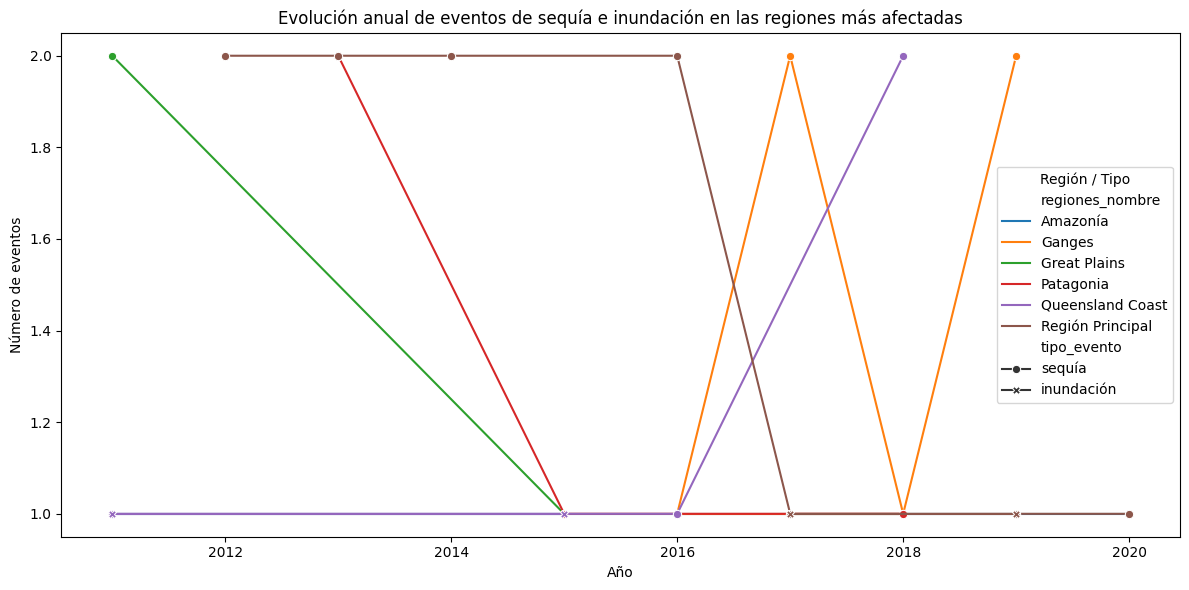

In [35]:
# Evolución anual de eventos climáticos por región.
regiones_top = freq_region[freq_region['tipo_evento'] == 'sequía'].nlargest(6, 'conteo')['regiones_nombre'].unique()
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=freq_region_year[freq_region_year['regiones_nombre'].isin(regiones_top)],
    x='regiones_anio',
    y='conteo',
    hue='regiones_nombre',
    style='tipo_evento',
    markers=True,
    dashes=False
)
plt.title('Evolución anual de eventos de sequía e inundación en las regiones más afectadas')
plt.xlabel('Año')
plt.ylabel('Número de eventos')
plt.legend(title='Región / Tipo')
plt.tight_layout()
plt.show()

##### **Conclusión**: Los datos confirman que el riesgo climático no se distribuye de manera equitativa. La vulnerabilidad extrema de ciertas zonas (como la "Región Principal") ante la falta de precipitaciones explica directamente los graves picos de volatilidad productiva que hemos estado observando a lo largo del documento. Esto nos indica de forma rotunda que cualquier política agraria o de subsidios destinada a estas regiones debe priorizar, por encima de todo, el desarrollo de infraestructuras para la gestión eficiente de los recursos hídricos.

### 3.8 Impacto de políticas en producción

*   **Análisis del impacto de políticas:** En esta sección cruzamos los datos de producción total con las diferentes iniciativas gubernamentales (subsidios monetarios, número de regulaciones y acuerdos internacionales). El objetivo es verificar si una mayor inyección de dinero o un marco regulatorio más estricto se traducen realmente en un aumento de la productividad agrícola.
*   **Correlación:** La correlación es moderada-baja. Sorprendentemente, los "acuerdos internacionales firmados" (0.39) y el número de "beneficiarios" (0.35) parecen tener mayor influencia positiva que la cantidad pura de dinero invertida ("total_subsidio", con apenas 0.26). Además, tener demasiados tipos distintos de subsidios muestra una correlación negativa (-0.42), lo que podría indicar que fragmentar demasiado las ayudas o el exceso de burocracia acaba lastrando la producción.

In [36]:
# Análisis exploratorio de políticas agrícolas.
pol = datasets['politicas_agricolas'].copy()
pol['subsidio_monto'] = pd.to_numeric(pol['subsidio_monto'], errors='coerce').fillna(0)
pol['subsidio_beneficiarios'] = pd.to_numeric(pol['subsidio_beneficiarios'], errors='coerce').fillna(0)
pol['acuerdo_internacional_firmado'] = pol['acuerdo_internacional_firmado'].astype(str).str.lower().map({'true': True, 'false': False})
pol['regulacion_vigente'] = pol['regulacion_vigente'].astype(str).str.lower().map({'true': True, 'false': False})

pol_group = pol.groupby('nombre').agg(
    total_subsidio=('subsidio_monto', 'sum'),
    count_subsidios=('subsidio_tipo', 'nunique'),
    total_beneficiarios=('subsidio_beneficiarios', 'sum'),
    count_regulaciones=('regulacion_tipo', 'nunique'),
    regulaciones_vigentes=('regulacion_vigente', lambda s: s.eq(True).sum()),
    acuerdos_firmados=('acuerdo_internacional_firmado', lambda s: s.eq(True).sum()),
    acuerdos_distintos=('acuerdo_internacional_nombre', 'nunique')
).reset_index()

prod_country = (
    datasets['produccion_agricola']
    .groupby('pais')['produccion_ton']
    .agg(total_produccion='sum', produccion_media_anual='mean')
    .reset_index()
)

policy_prod = prod_country.merge(pol_group, left_on='pais', right_on='nombre', how='left')

print('Países sin datos de políticas en la unión:')
print(policy_prod[policy_prod['total_subsidio'].isna()][['pais']].drop_duplicates().sort_values('pais').head(15))

policy_prod['total_subsidio'] = policy_prod['total_subsidio'].fillna(0)
policy_prod['count_regulaciones'] = policy_prod['count_regulaciones'].fillna(0)
policy_prod['regulaciones_vigentes'] = policy_prod['regulaciones_vigentes'].fillna(0)
policy_prod['acuerdos_firmados'] = policy_prod['acuerdos_firmados'].fillna(0)
policy_prod['acuerdos_distintos'] = policy_prod['acuerdos_distintos'].fillna(0)

corr_cols = [
    'total_produccion', 'produccion_media_anual',
    'total_subsidio', 'count_subsidios', 'total_beneficiarios',
    'count_regulaciones', 'regulaciones_vigentes',
    'acuerdos_firmados', 'acuerdos_distintos'
]
print('\nCorrelación entre producción y variables de políticas:')
print(policy_prod[corr_cols].corr()['total_produccion'].sort_values(ascending=False))

Países sin datos de políticas en la unión:
      pais
4   Canadá
10  Italia
14   Rusia

Correlación entre producción y variables de políticas:
total_produccion          1.000000
produccion_media_anual    1.000000
acuerdos_firmados         0.395366
total_beneficiarios       0.358657
regulaciones_vigentes     0.352049
total_subsidio            0.269694
acuerdos_distintos        0.232704
count_regulaciones        0.056551
count_subsidios          -0.429041
Name: total_produccion, dtype: float64


*   **Heatmap de correlación:**
    *   **Lo más efectivo:** La variable con mayor productividad no es el presupuesto, sino tener acuerdos internacionales firmados (0.40) y una amplia red de beneficiarios directos (0.36). 
    *   **Impacto débil del dinero:** El dinero total invertido en subsidios ("total_subsidio" 0.27) tiene una correlación relativamente baja. Esto confirma visualmente que otorgar enormes cantidades de dinero no garantiza un retorno equivalente.
    *   **Efecto negativo (Tonos Azules):** "count_subsidios" (-0.43) tiene una correlación negativa. Esto indica que fragmentar las ayudas en demasiados tipos distintos tiene un fuerte impacto negativo. Un exceso de burocracia y variedad de subsidios parece paralizar o confundir al sector agrícola en lugar de ayudarlo.

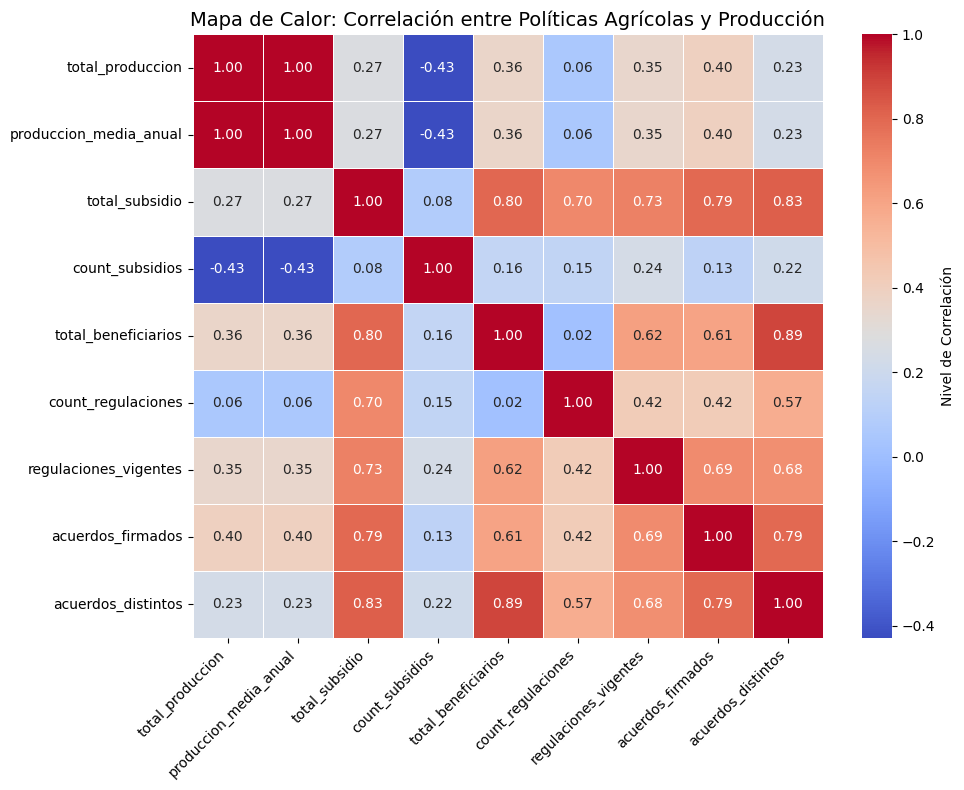

In [37]:
# Visualización de la matriz de correlación de políticas y producción
plt.figure(figsize=(10, 8))
correlation_matrix = policy_prod[corr_cols].corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={'label': 'Nivel de Correlación'}
)
plt.title('Mapa de Calor: Correlación entre Políticas Agrícolas y Producción', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*   **Gráficos de subsidios vs producción:** Al observar el diagrama de dispersión y los rankings, comprobamos visualmente lo que los números sugerían. Es cierto que Brasil lidera tanto en producción total como en inversión económica (más de 670 millones), lo que insinúa un impacto directo. Sin embargo, países como China o Australia logran producciones casi idénticas o superiores gastando menos de la mitad en subsidios que gigantes europeos como Alemania. 

C:\Users\coast\AppData\Local\Temp\ipykernel_5568\1152611205.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


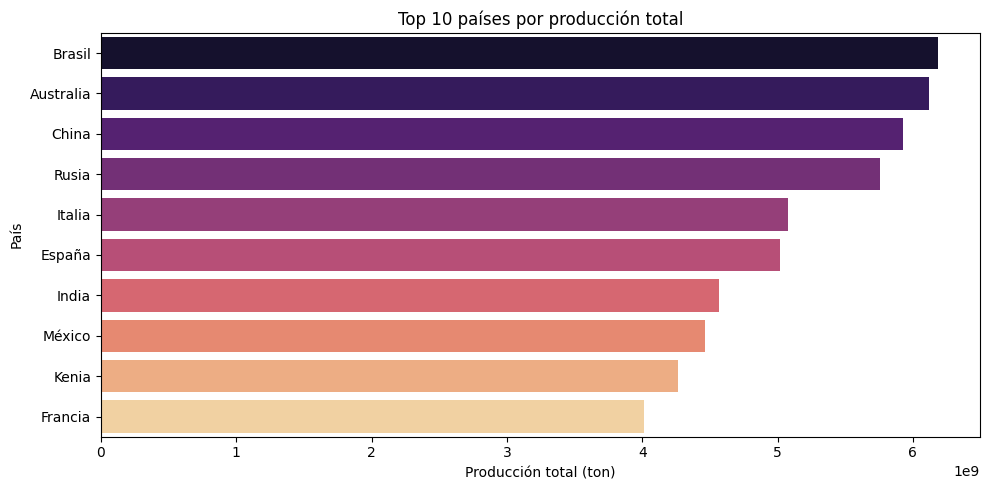

Top 10 países por inversión en subsidios:
              pais  total_subsidio  total_produccion
3           Brasil     673290900.0        6186852226
0         Alemania     374812740.0        3874736747
12          México     314838540.0        4460470748
9            India     274154396.0        4567444336
8          Francia     264844242.0        4012847594
1        Argentina     259183152.0         720411596
5            China     248318481.0        5929072220
2        Australia     232259232.0        6120959078
7   Estados Unidos     175278300.0        3961739276
11           Kenia     173744748.0        4265080819


In [38]:
# Relación entre subsidios y producción.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=policy_prod.sort_values('total_produccion', ascending=False).head(10),
    x='total_produccion',
    y='pais',
    palette='magma'
)
plt.title('Top 10 países por producción total')
plt.xlabel('Producción total (ton)')
plt.ylabel('País')
plt.tight_layout()
plt.show()

print('Top 10 países por inversión en subsidios:')
print(policy_prod.sort_values('total_subsidio', ascending=False)[['pais', 'total_subsidio', 'total_produccion']].head(10))

##### **Conclusión**: El análisis pone en evidencia que las políticas públicas tienen un efecto positivo, pero no directamente proporcional ni determinante. El hecho de inyectar dar más dinero no garantiza por sí solo liderar la producción. De hecho, los acuerdos internacionales muestran una mayor relación en ese aspecto. Los datos indican que es mucho más eficiente cerrar alianzas estratégicas y enfocar bien las ayudas que simplemente gastar grandes presupuestos sin control.

### 3.9 Combinar políticas con datos de producción

*   **Cruce de datos anuales:** En este apartado hacemos join de la producción de cada país año a año con los subsidios y regulaciones vigentes en esos mismos periodos. El objetivo es comprobar si inyectar dinero un año concreto dispara la cosecha de ese mismo año.

In [39]:
# Combinación de políticas con datos de producción anual.
# Agregamos las políticas por país y año para combinar con la producción anual
pol_year = pol.copy()
subsidios_year = (
    pol_year[pol_year['subsidio_anio'].notna()]
    .groupby(['nombre', 'subsidio_anio'])
    .agg(
        total_subsidio_anio=('subsidio_monto', 'sum'),
        count_subsidios_anio=('subsidio_tipo', 'nunique'),
        beneficiarios_anio=('subsidio_beneficiarios', 'sum')
    )
    .reset_index()
    .rename(columns={'subsidio_anio': 'anio'})
)
regulaciones_year = (
    pol_year[pol_year['regulacion_anio_implementacion'].notna()]
    .groupby(['nombre', 'regulacion_anio_implementacion'])
    .agg(
        count_regulaciones_anio=('regulacion_tipo', 'nunique'),
        regulaciones_vigentes_anio=('regulacion_vigente', lambda s: s.eq(True).sum())
    )
    .reset_index()
    .rename(columns={'regulacion_anio_implementacion': 'anio'})
)

prod_year = (
    datasets['produccion_agricola']
    .groupby(['pais', 'anio'])['produccion_ton']
    .sum()
    .reset_index()
)

combined = prod_year.merge(subsidios_year, left_on=['pais', 'anio'], right_on=['nombre', 'anio'], how='left')
combined = combined.merge(regulaciones_year, left_on=['pais', 'anio'], right_on=['nombre', 'anio'], how='left', suffixes=('_subsidio', '_regulacion'))

combined = combined.drop(columns=['nombre_subsidio', 'nombre_regulacion'], errors='ignore')
combined[['total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio']] = combined[[
    'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio'
]].fillna(0)

print('Combinación de producción y políticas por país/año (muestra):')
print(combined.head())

print('\nCorrelaciones entre producción anual y políticas por año:')
print(combined[['produccion_ton', 'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio']].corr()['produccion_ton'].sort_values(ascending=False))

Combinación de producción y políticas por país/año (muestra):
       pais  anio  produccion_ton  total_subsidio_anio  count_subsidios_anio  \
0  Alemania  2011       442481570                  0.0                   0.0   
1  Alemania  2012       350211883                  0.0                   0.0   
2  Alemania  2013       166339315                  0.0                   0.0   
3  Alemania  2014       358812958                  0.0                   0.0   
4  Alemania  2015       420178305                  0.0                   0.0   

   beneficiarios_anio  count_regulaciones_anio  regulaciones_vigentes_anio  
0                 0.0                      0.0                         0.0  
1                 0.0                      0.0                         0.0  
2                 0.0                      0.0                         0.0  
3                 0.0                      0.0                         0.0  
4                 0.0                      1.0                         0

*   **Lectura del Mapa de Calor Anual:** Al observar la matriz de correlación, la correlación entre el total de subsidios y la producción anual cae drásticamente a un escaso 0.10 (comparado con el 0.27 que vimos a nivel histórico acumulado).Esto indica que el impacto de una política agraria no es instantáneo. El campo no reacciona incrementando la producción en el mismo ciclo anual en que recibe la subvención monetaria.

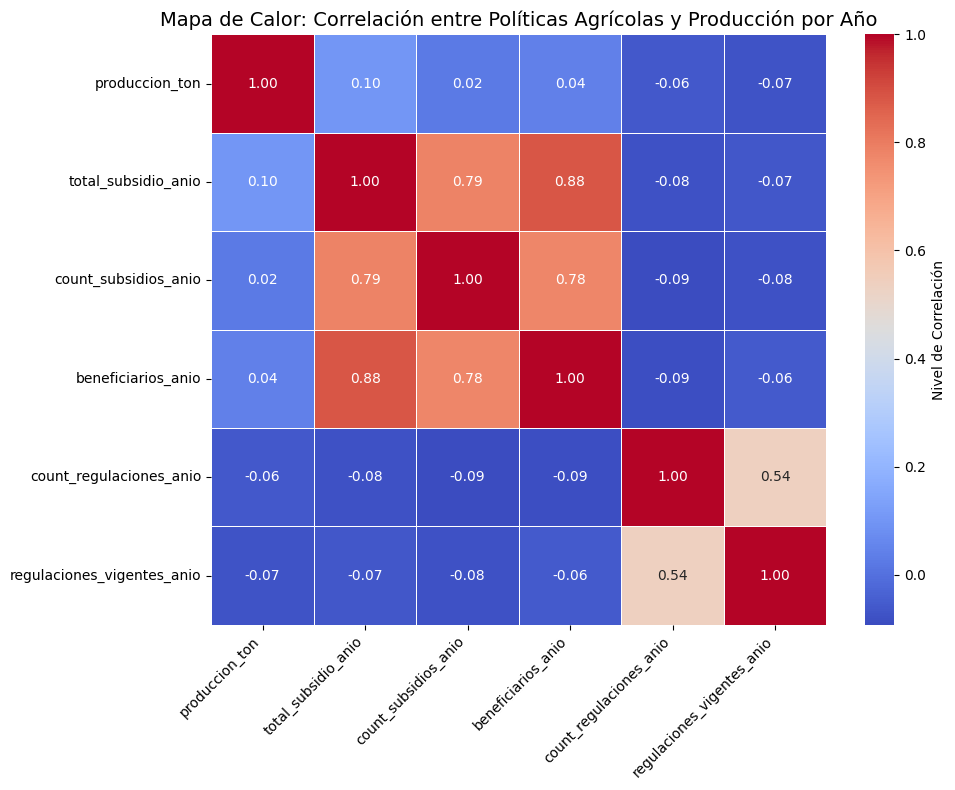

In [40]:
plt.figure(figsize=(10, 8))
corr_matrix = combined[['produccion_ton', 'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio', 'count_regulaciones_anio', 'regulaciones_vigentes_anio']].corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={'label': 'Nivel de Correlación'}
)
plt.title('Mapa de Calor: Correlación entre Políticas Agrícolas y Producción por Año', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*   **Dispersión de Producción vs Subsidios Anuales:** El gráfico de dispersión confirma que hay una falta de relación directa a corto plazo. No vemos una tendencia ascendente donde más dinero signifique más producción. Observamos una nube dispersa, con países produciendo cantidades altas sin apenas recibir subsidios ese año, y viceversa.

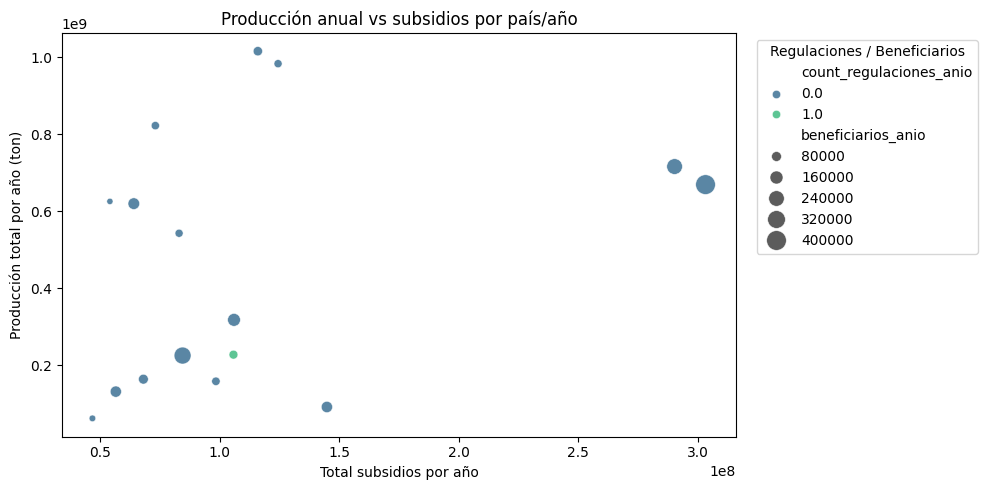

In [41]:
# Impacto de las políticas en la producción total.
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=combined[combined['total_subsidio_anio'] > 0],
    x='total_subsidio_anio',
    y='produccion_ton',
    hue='count_regulaciones_anio',
    size='beneficiarios_anio',
    sizes=(20, 200),
    palette='viridis',
    alpha=0.8
)
plt.title('Producción anual vs subsidios por país/año')
plt.xlabel('Total subsidios por año')
plt.ylabel('Producción total por año (ton)')
plt.legend(title='Regulaciones / Beneficiarios', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### **Conclusión**: Analizar los datos año a año nos demuestra que la agricultura es un sector de lenta adopoción. Los subsidios y las regulaciones no modifican la producción de inmediato. Esto sugiere que las políticas agrarias deben planificarse a largo plazo (por ejemplo, inversiones en grandes infraestructuras, canales de riego o adopción de nueva tecnología) cuyos frutos tardan varios años en reflejarse en los volúmenes de cosecha, en lugar de esperar rescates de la industria en un solo año.

### 3.10 Relacionar subsidios con incrementos de rendimiento

*   **Rendimiento vs Inversión:** En esta sección analizamos si los subsidios realmente fomentan una mejora en la eficiencia agrícola (rendimiento_ton_ha). Verificamos si el apoyo financiero ayuda a producir más con la misma superficie, lo que indicaría un avance en tecnificación e intensificación sostenible.

In [42]:
# Cambio interanual en el rendimiento.
yield_year = (
    datasets['produccion_agricola']
    .groupby(['pais', 'anio'])['rendimiento_ton_ha']
    .mean()
    .reset_index()
    .sort_values(['pais', 'anio'])
)
yield_year['delta_rendimiento'] = yield_year.groupby('pais')['rendimiento_ton_ha'].diff()
yield_year['pct_change_rendimiento'] = yield_year.groupby('pais')['rendimiento_ton_ha'].pct_change() * 100

yield_subsidio = yield_year.merge(
    subsidios_year,
    left_on=['pais', 'anio'],
    right_on=['nombre', 'anio'],
    how='left'
).drop(columns=['nombre'], errors='ignore')

yield_subsidio[['total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio']] = yield_subsidio[[
    'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio'
]].fillna(0)

print('Muestra de rendimiento combinado con subsidios:')
print(yield_subsidio.head())

print('\nCorrelación entre delta de rendimiento y subsidios:')
print(yield_subsidio[
    ['delta_rendimiento', 'pct_change_rendimiento', 'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio']
].corr()['delta_rendimiento'].sort_values(ascending=False))

Muestra de rendimiento combinado con subsidios:
       pais  anio  rendimiento_ton_ha  delta_rendimiento  \
0  Alemania  2011            12.56625                NaN   
1  Alemania  2012            16.39375            3.82750   
2  Alemania  2013            12.25875           -4.13500   
3  Alemania  2014            18.96750            6.70875   
4  Alemania  2015            14.88250           -4.08500   

   pct_change_rendimiento  total_subsidio_anio  count_subsidios_anio  \
0                     NaN                  0.0                   0.0   
1               30.458570                  0.0                   0.0   
2              -25.223027                  0.0                   0.0   
3               54.726216                  0.0                   0.0   
4              -21.536839                  0.0                   0.0   

   beneficiarios_anio  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  

Correlación e

*   **Lectura del Mapa de Calor (Rendimiento):** Al observar la matriz de correlación enfocada en la eficiencia (delta_rendimiento), los datos son aún más fríos que los observados en producción total. La correlación entre el incremento del rendimiento por hectárea y el dinero invertido anualmente es prácticamente nula (0.05). Esto confirma que entregar más fondos a un sector no hace se consiga extraer más toneladas de una misma hectárea.

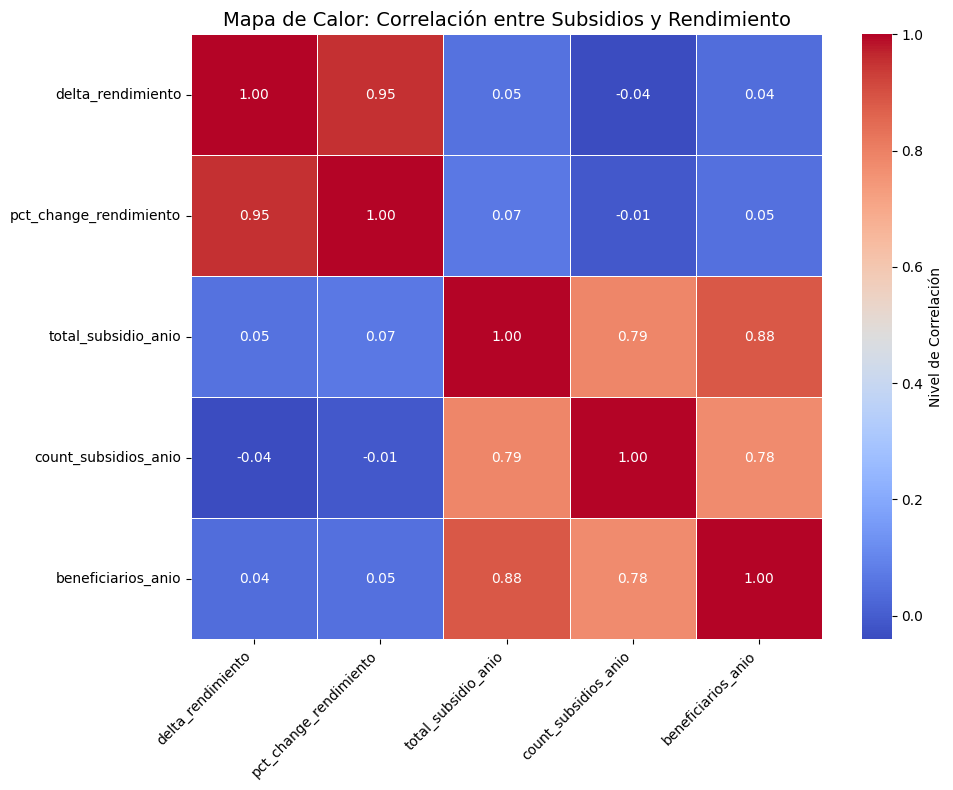

In [43]:
plt.figure(figsize=(10, 8))
corr_matrix = yield_subsidio[['delta_rendimiento', 'pct_change_rendimiento', 'total_subsidio_anio', 'count_subsidios_anio', 'beneficiarios_anio']].corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={'label': 'Nivel de Correlación'}
)
plt.title('Mapa de Calor: Correlación entre Subsidios y Rendimiento', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*   **Análisis Visual de Dispersión y Cuartiles:**
    *   **Gráfico de dispersión:** Observamos una completa falta de tendencia. Los puntos de mayor crecimiento en el rendimiento agronómico se concentran curiosamente a la izquierda del eje (en años y países con niveles muy bajos de subsidios).
    

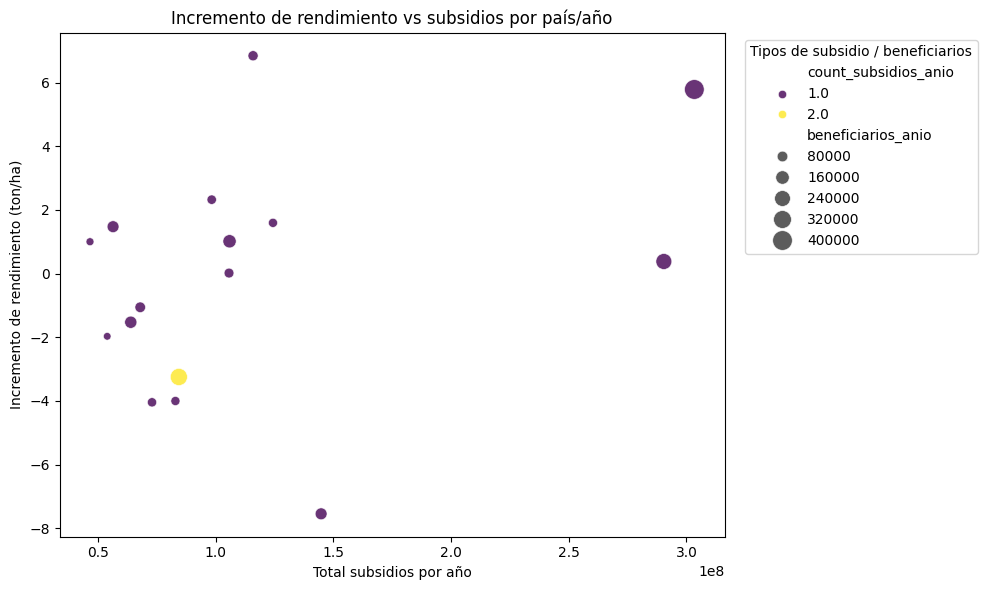

In [44]:
# Relación subsidios vs incremento de rendimiento.
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=yield_subsidio[yield_subsidio['delta_rendimiento'].notna() & (yield_subsidio['total_subsidio_anio'] > 0)],
    x='total_subsidio_anio',
    y='delta_rendimiento',
    hue='count_subsidios_anio',
    size='beneficiarios_anio',
    sizes=(30, 200),
    palette='viridis',
    alpha=0.8
)
plt.title('Incremento de rendimiento vs subsidios por país/año')
plt.xlabel('Total subsidios por año')
plt.ylabel('Incremento de rendimiento (ton/ha)')
plt.legend(title='Tipos de subsidio / beneficiarios', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

*  **Boxplot (Cuartiles):** Al dividir los subsidios en cuatro grandes grupos, vemos que las cajas son planas y muy similares entre sí. Los países que más dinero reciben no logran una ventaja clara en mejora de eficiencia respecto a los que menos reciben.

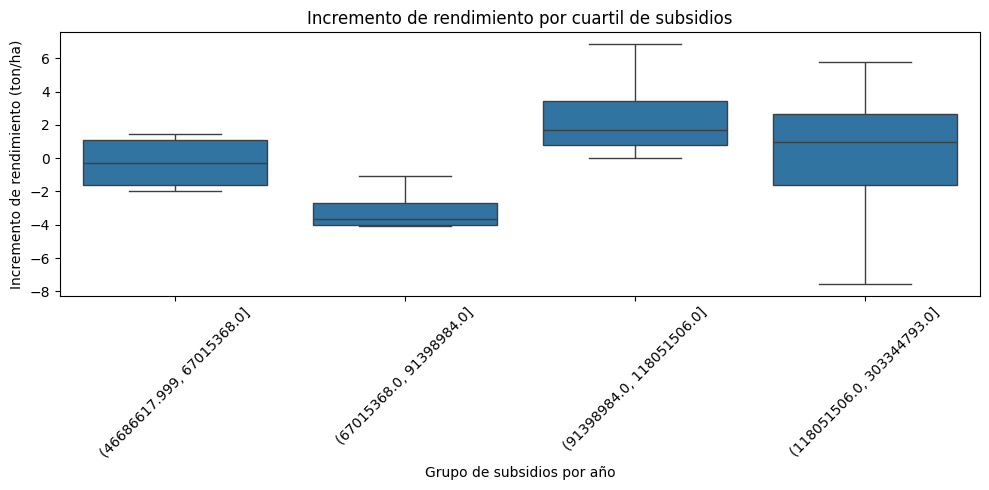

In [45]:
# Análisis de eficiencia de subsidios.
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=yield_subsidio[yield_subsidio['total_subsidio_anio'] > 0],
    x=pd.qcut(yield_subsidio[yield_subsidio['total_subsidio_anio'] > 0]['total_subsidio_anio'], q=4, duplicates='drop'),
    y='delta_rendimiento'
)
plt.xticks(rotation=45)
plt.title('Incremento de rendimiento por cuartil de subsidios')
plt.xlabel('Grupo de subsidios por año')
plt.ylabel('Incremento de rendimiento (ton/ha)')
plt.tight_layout()
plt.show()

##### **Conclusión**: Tras analizar todos estos datos cruzados, podemos determinar que el éxito agrícola y la mejora de eficiencia no están condicionados por volumen de subsidios. La baja respuesta a corto plazo en producción y rendimiento sugiere que factores como la adopción de tecnología, la optimización del agua o la protección ante anomalías climáticas tienen un peso mayor. Inyectar dinero es una ayuda de soporte necesaria, pero los datos dicen que no es decisivo a la hora de aumentar la productividad.

### 3.11 Extracción de entidades: plagas, cultivos, países, fechas

*   **Extracción de entidades:** Vamos a procesar los titulares y cuerpos de noticias, así como los reportes sanitarios, para extraer automáticamente los qué plaga está atacando, en qué país y a qué cultivo específico.

In [46]:
# Carga y limpieza de datos de noticias.
noticias = datasets['noticias_agricolas'].copy()
reportes = datasets['reportes_plagas'].copy()

# Normalizar fechas en los dos datasets
noticias['fecha'] = pd.to_datetime(noticias['fecha'], errors='coerce')
reportes['Fecha'] = pd.to_datetime(reportes['Fecha'], dayfirst=True, errors='coerce')

# Entidades desde campos estructurados
plagas_reportadas = reportes['Plaga/Enfermedad detectada'].dropna().unique()
cultivos_reportados = reportes['Cultivo'].dropna().unique()
paises_reportes = reportes['Pais'].dropna().unique()

paises_noticias = (
    noticias['paises_afectados']
    .dropna()
    .str.split('\|')
    .explode()
    .str.strip()
    .unique()
)
cultivos_noticias = noticias['impacto_cultivos'].dropna().unique()

print('Plagas reportadas (reportes_plagas):', plagas_reportadas)
print('Cultivos reportados (reportes_plagas):', cultivos_reportados)
print('Países en reportes de plagas:', paises_reportes[:20])
print('Países en noticias agrícolas:', paises_noticias[:20])
print('Cultivos en noticias agrícolas:', cultivos_noticias[:20])

Plagas reportadas (reportes_plagas): <StringArray>
[    'Gusano cogollero',                'Ácaro', 'Barrenador del tallo',
          'Piricularia',             'Langosta',      'Roya de la hoja',
               'Pulgón',             'Fusarium',               'Mildiu',
          'Podredumbre', 'Oruga militar tardía',         'Mosca blanca',
       'Chinche marrón',         'Tizón tardío',                'Oídio',
        'Roya amarilla',          'Antracnosis']
Length: 17, dtype: str
Cultivos reportados (reportes_plagas): <StringArray>
[         'Arroz',           'Soja',        'Girasol',        'Algodón',
         'Cebada',           'Maíz',          'Trigo', 'Caña de azúcar',
             'Té',           'Café']
Length: 10, dtype: str
Países en reportes de plagas: <StringArray>
[     'Australia', 'Estados Unidos',        'Francia',          'China',
         'Brasil',       'Alemania',          'India',      'Argentina']
Length: 8, dtype: str
Países en noticias agrícolas: <StringArra

<>:17: SyntaxWarning: invalid escape sequence '\|'
<>:17: SyntaxWarning: invalid escape sequence '\|'
C:\Users\coast\AppData\Local\Temp\ipykernel_5568\3838204404.py:17: SyntaxWarning: invalid escape sequence '\|'
  .str.split('\|')


*   **Resultados de la extracción en texto:** Como observamos en la muestra generada, logramos identificar correctamente que la primera noticia menciona a "Canadá", la segunda trata sobre "arroz", y la tercera relaciona a "Alemania" con el "maíz".

In [47]:
# Extracción de entidades (cultivos, países) de los titulares.
known_plagas = [str(x).lower() for x in plagas_reportadas if pd.notna(x)]
known_cultivos = [str(x).lower() for x in pd.concat([pd.Series(cultivos_reportados), pd.Series(cultivos_noticias)]).dropna().unique()]
known_paises = [str(x).lower() for x in pd.concat([pd.Series(paises_reportes), pd.Series(paises_noticias)]).dropna().unique()]

# Función simple de marcado con listas conocidas

def extract_keywords(text, keywords):
    if pd.isna(text):
        return []
    text_lower = text.lower()
    return sorted({k for k in keywords if k in text_lower})

noticias['plagas_en_texto'] = noticias['contenido'].apply(lambda t: extract_keywords(t, known_plagas))
noticias['cultivos_en_texto'] = noticias['contenido'].apply(lambda t: extract_keywords(t, known_cultivos))
noticias['paises_en_texto'] = noticias['contenido'].apply(lambda t: extract_keywords(t, known_paises))

# Extraer fechas en texto
date_pattern = r'\b\d{4}-\d{2}-\d{2}\b|\b\d{2}/\d{2}/\d{4}\b|\b\d{2}-\d{2}-\d{4}\b'
noticias['fechas_en_texto'] = noticias['contenido'].astype(str).str.findall(date_pattern)

print('Ejemplo de extracción en noticias:')
print(noticias[['titular', 'paises_en_texto', 'cultivos_en_texto', 'plagas_en_texto', 'fechas_en_texto']].head(5).to_string(index=False))

Ejemplo de extracción en noticias:
                                                          titular paises_en_texto cultivos_en_texto plagas_en_texto fechas_en_texto
   Nueva política agrícola en Canadá busca mejorar sostenibilidad        [canadá]                []              []              []
                        Ola de calor reduce rendimientos de Arroz        [canadá]           [arroz]              []              []
                Sequía afecta proyecciones de cosecha en Alemania      [alemania]            [maíz]              []              []
Nueva política agrícola en Argentina busca mejorar sostenibilidad     [argentina]                []              []              []
                    Demanda china impulsa mercado de carne_bovina         [rusia]    [carne_bovina]              []              []


*   **Consolidación de reportes sanitarios:** Hemos podido generar un diccionario limpio de 17 plagas distintas afectando a 10 cultivos en 8 países, asociándolas a fechas válidas.

In [48]:
# Extracción de plagas de los reportes sanitarios.
reportes['plagas_extraidas'] = reportes['Plaga/Enfermedad detectada'].astype(str)
reportes['cultivos_extraidos'] = reportes['Cultivo'].astype(str)
reportes['paises_extraidos'] = reportes['Pais'].astype(str)
reportes['fecha_extraida'] = reportes['Fecha']

print('\nConteo de entidades extraídas de reportes de plagas:')
print('Plagas:', reportes['plagas_extraidas'].nunique())
print('Cultivos:', reportes['cultivos_extraidos'].nunique())
print('Países:', reportes['paises_extraidos'].nunique())
print('Fechas válidas:', reportes['fecha_extraida'].notna().sum())


Conteo de entidades extraídas de reportes de plagas:
Plagas: 17
Cultivos: 10
Países: 8
Fechas válidas: 100


##### **Conclusión**: Hemos logrado el objetivo de convertir titulares de prensa y alertas de plagas en columnas categóricas puras (país, plaga, cultivo).

### 3.12 Análisis de sentimiento en noticias

*   **Análisis de sentimiento (NLP):** En este apartado evaluamos el tono emocional de las noticias utilizando un diccionario de palabras clave. El objetivo es comprobar si la prensa refleja mayormente optimismo (crecimiento, mejoras) o crisis (sequías, pérdidas) y cómo esto se distribuye temáticamente.

In [49]:
# Análisis de sentimiento en noticias agrícolas.
noticias_texto = datasets['noticias_agricolas'].copy()
noticias_texto['contenido'] = noticias_texto['contenido'].astype(str)

positive_words = {
    'positivo', 'mejor', 'mejora', 'crecimiento', 'aumento', 'favorable',
    'beneficio', 'beneficios', 'excelente', 'sostenible', 'apoya', 'apoyo',
    'recuperación', 'recuperacion', 'estable', 'optimista', 'oportunidad',
    'avance', 'avances', 'superior', 'supera', 'superan'
}
negative_words = {
    'pérdida', 'perdida', 'baja', 'caída', 'caida', 'reducción', 'reduccion',
    'disminución', 'disminucion', 'grave', 'crítico', 'critico', 'malo',
    'malos', 'peligro', 'riesgo', 'problema', 'problemas', 'sequía', 'sequia',
    'inundación', 'inundacion', 'daño', 'dano', 'descenso', 'peor', 'caos',
    'alerta', 'extremo', 'extremos', 'crisis', 'dañino', 'danino', 'amenaza'
}

word_pattern = re.compile(r"\b[\wáéíóúñÁÉÍÓÚÑ]+\b", flags=re.IGNORECASE)

def sentiment_scores(text: str) -> tuple[int, int, int]:
    words = word_pattern.findall(text.lower())
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    return pos, neg, pos - neg

noticias_texto[['pos_count', 'neg_count', 'sentiment_score']] = noticias_texto['contenido'].apply(
    lambda t: pd.Series(sentiment_scores(t))
)

noticias_texto['sentimiento'] = noticias_texto['sentiment_score'].apply(
    lambda s: 'positivo' if s > 0 else ('negativo' if s < 0 else 'neutral')
)

print('Distribución de sentimiento en noticias:')
print(noticias_texto['sentimiento'].value_counts())

Distribución de sentimiento en noticias:
sentimiento
neutral     49
negativo    11
Name: count, dtype: int64


*   **Lectura de la distribución de sentimiento:** La mayoría de las noticias adoptan un tono "Neutral". Sin embargo, no existe ni una sola noticia clasificada como "Positiva". Las 11 noticias restantes son "Negativas", lo que sugiere que la prensa actúa principalmente como un canal de alerta para desastres y problemas, en lugar de un altavoz para celebrar éxitos.

C:\Users\coast\AppData\Local\Temp\ipykernel_5568\1931802614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=noticias_texto, x='sentimiento', order=['positivo', 'neutral', 'negativo'], palette=['green', 'gray', 'red'])


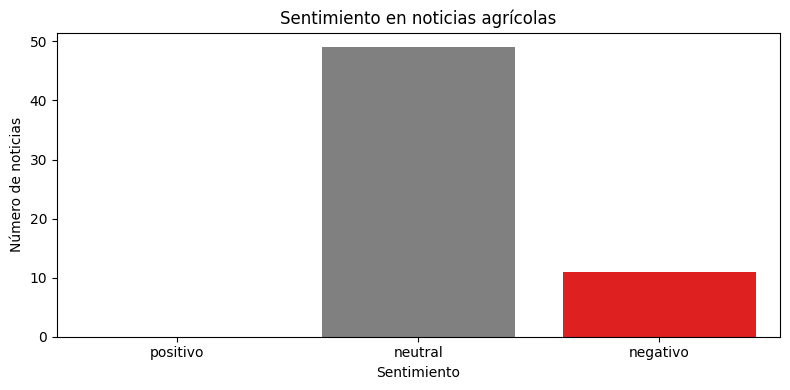

In [50]:
# Distribución de sentimientos en las noticias.
plt.figure(figsize=(8, 4))
sns.countplot(data=noticias_texto, x='sentimiento', order=['positivo', 'neutral', 'negativo'], palette=['green', 'gray', 'red'])
plt.title('Sentimiento en noticias agrícolas')
plt.xlabel('Sentimiento')
plt.ylabel('Número de noticias')
plt.tight_layout()
plt.show()

In [51]:
# Identificación de noticias altamente positivas.
print('Titulares más positivos:')
print(noticias_texto[noticias_texto['sentimiento'] == 'positivo'][['titular', 'sentiment_score']].head(5).to_string(index=False))
print('\nTitulares más negativos:')
print(noticias_texto[noticias_texto['sentimiento'] == 'negativo'][['titular', 'sentiment_score']].head(5).to_string(index=False))

Titulares más positivos:
Empty DataFrame
Columns: [titular, sentiment_score]
Index: []

Titulares más negativos:
                                                titular  sentiment_score
              Ola de calor reduce rendimientos de Arroz               -1
      Sequía afecta proyecciones de cosecha en Alemania               -1
Sequía afecta proyecciones de cosecha en Estados Unidos               -1
         Sequía afecta proyecciones de cosecha en Kenia               -1
         Sequía afecta proyecciones de cosecha en Kenia               -1


*   **Sentimiento por Categoría:** Al cruzar el sentimiento con las diferentes temáticas, confirmamos que las noticias sobre "clima" están marcadas como negativas. Las demás categorías son neutrales.

In [52]:
# Análisis de sentimiento por categoría de noticia.
if 'categoria' in noticias_texto.columns:
    print('\nSentimiento por categoría:')
    print(noticias_texto.groupby('categoria')['sentimiento'].value_counts(normalize=True).unstack(fill_value=0).round(2))


Sentimiento por categoría:
sentimiento  neutral  negativo
categoria                     
clima            0.0       1.0
comercio         1.0       0.0
mercado          1.0       0.0
politica         1.0       0.0
sanidad          1.0       0.0
tecnologia       1.0       0.0


##### **Conclusión**: Los medios agrícola de nuestro dataset están sesgados hacia la neutralidad y la alerta por desastres. El hecho de que el clima acapare todo el sentimiento negativo refuerza la conclusión que obtuvimos en los apartados anteriores: la inestabilidad climática es el principal factor de miedo, estrés y caída productiva para el sector agrícola.

### 3.13 Topic modeling de reportes de plagas

*   **Modelado de Tópicos (LDA):** En esta fase aplicamos Latent Dirichlet Allocation sobre los reportes de plagas. El objetivo es que se descubran automáticamente "patrones ocultos" o temas recurrentes que vinculen plagas concretas con niveles de severidad y métodos de tratamiento específicos en el campo.

In [53]:
# Limpieza de datos de plagas para visualización.
reportes_plagas['Area afectada (ha)'] = reportes_plagas['Area afectada'].str.replace('ha', '').astype(float)
reportes_plagas['Eficacia (%)'] = reportes_plagas['Eficacia'].str.replace('%', '').astype(float)
reportes_plagas['Perdida estimada (%)'] = reportes_plagas['Perdida estimada'].str.replace('%', '').astype(float)

display(reportes_plagas.head())

,Fecha,Region,Pais,Cultivo,Severidad,Area afectada,Tratamiento aplicado,Eficacia,Perdida estimada,Plaga/Enfermedad,Plaga/Enfermedad detectada,Area afectada (ha),Eficacia (%),Perdida estimada (%)
0,30/08/2020,Murray-Darling Basin,Australia,Arroz,Media,1050ha,Químico (Clorantraniliprol),85%,34%,Plaga,Gusano cogollero,1050.0,85.0,34.0
1,30/04/2020,California,Estados Unidos,Soja,Alta,1724ha,Biológico (Bacillus thuringiensis),70%,3%,Plaga,Ácaro,1724.0,70.0,3.0
2,29/12/2021,Región Principal,Francia,Girasol,Crítica,4114ha,Químico (Imidacloprid),74%,23%,Plaga,Gusano cogollero,4114.0,74.0,23.0
3,29/12/2020,Región Principal,China,Algodón,Baja,681ha,Físico (Control térmico),84%,30%,Plaga,Barrenador del tallo,681.0,84.0,30.0
4,29/09/2020,Región Principal,Francia,Cebada,Media,3854ha,Cultural (Rotación de cultivos),92%,33%,Plaga,Ácaro,3854.0,92.0,33.0


*   **Lectura de Frecuencia y Severidad:**
    *   **Frecuencia:** El primer gráfico expone que el "Gusano cogollero" y los "Ácaros" son los atacantes más recurrentes en los registros, seguidos de cerca por el "Barrenador del tallo".
    *   **Severidad por Cultivo:** El segundo gráfico hace referencia a que cultivos como el Maíz y el café, tienen gran cantidad de reportes de severidad "Alta" y "Crítica". La caña de azúcar acumula muchos reportes, aunque no son críticos y el arroz es el cultivo con más reportes (la mayoría de media severidad).

C:\Users\coast\AppData\Local\Temp\ipykernel_5568\2934923886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reportes_plagas, y='Plaga/Enfermedad detectada',


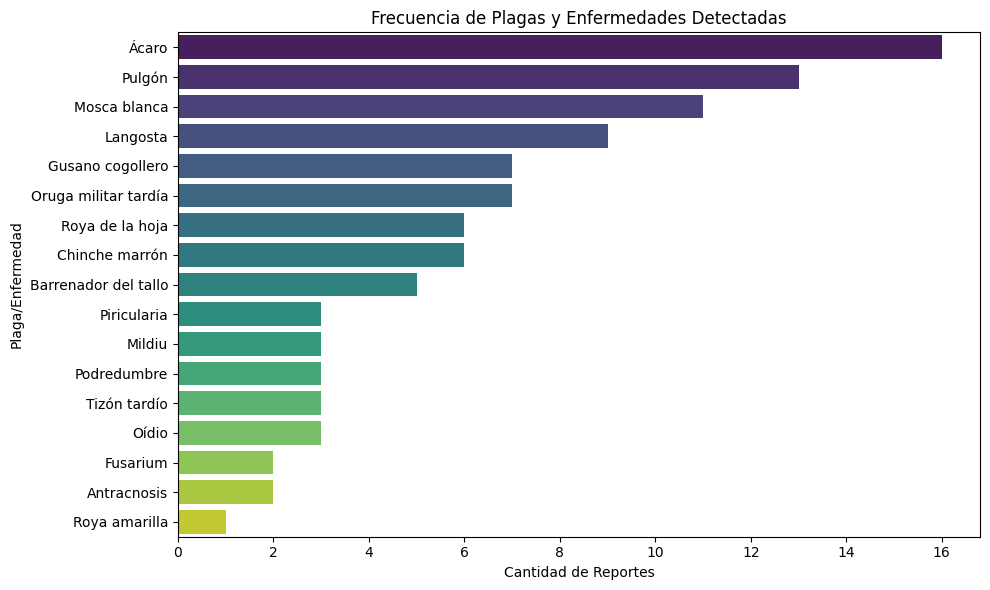

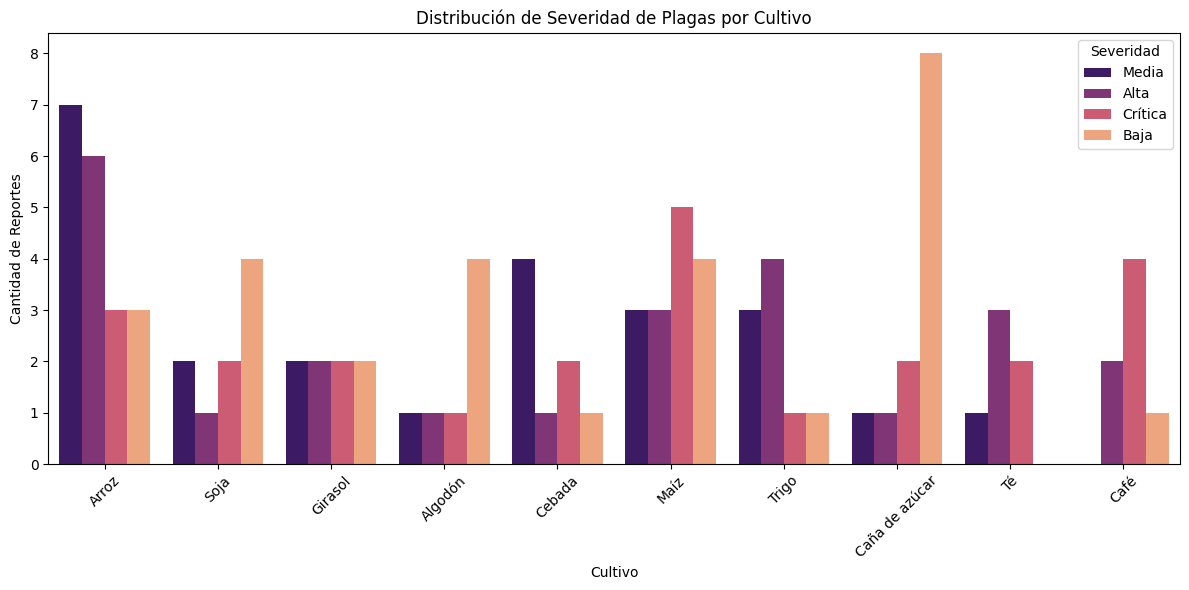

In [54]:
# Frecuencia de tipos de plagas detectadas.
plt.figure(figsize=(10, 6))
sns.countplot(data=reportes_plagas, y='Plaga/Enfermedad detectada', 
              order=reportes_plagas['Plaga/Enfermedad detectada'].value_counts().index, 
              palette='viridis')
plt.title('Frecuencia de Plagas y Enfermedades Detectadas')
plt.xlabel('Cantidad de Reportes')
plt.ylabel('Plaga/Enfermedad')
plt.tight_layout()
plt.show()

# Gráfico 2: Severidad de los Reportes según el Cultivo
plt.figure(figsize=(12, 6))
sns.countplot(data=reportes_plagas, x='Cultivo', hue='Severidad', palette='magma')
plt.title('Distribución de Severidad de Plagas por Cultivo')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de Reportes')
plt.tight_layout()
plt.show()

*   **Lectura de los Tópicos Ocultos (LDA):** El algoritmo logró agrupar los textos en tres grandes patrones:
    *   **Tópico #1:** Asocia la severidad "alta" a problemas con la "mosca blanca" en "trigo" y "arroz", requiriendo casi siempre un tratamiento "químico".
    *   **Tópico #2:** Agrupa situaciones donde métodos "físicos" o "biológicos" están relacionados con cultivos como la caña.
    *   **Tópico #3:** Identifica un patrón preventivo: se asocia lo "cultural" y la "rotación de cultivos" a severidades "medias/bajas" frente a plagas como el "ácaro".

In [55]:
# Topic Modeling (LDA) para identificar temas en reportes de plagas.
# 3. Topic Modeling usando LDA
# Preparación del texto combinando atributos clave
reportes_plagas['tratamiento_termino'] = reportes_plagas['Tratamiento aplicado'].apply(lambda x: x.replace(" ", "_"))

reportes_plagas['texto_reporte'] = (
    reportes_plagas['Cultivo'] + " " + 
    reportes_plagas['Plaga/Enfermedad detectada'] + " " + 
    reportes_plagas['Severidad'] + " " + 
    reportes_plagas['tratamiento_termino']
)

# Vectorización (Convertir el texto en una matriz numérica)
vectorizer = CountVectorizer()
X_vect = vectorizer.fit_transform(reportes_plagas['texto_reporte'])

# Aplicación del modelo LDA
n_topics = 3 
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_model.fit(X_vect)

# Visualización de los Tópicos descubiertos
def mostrar_topicos(modelo, vectorizador, num_palabras_top):
    palabras = vectorizador.get_feature_names_out()
    for topic_idx, topic in enumerate(modelo.components_):
        print(f"▶ Tópico #{topic_idx + 1}:")
        top_terminos = [palabras[i] for i in topic.argsort()[:-num_palabras_top - 1:-1]]
        print(" | ".join(top_terminos))
        print("-" * 60)

print("Tópicos / Patrones principales encontrados en los reportes:\n")
mostrar_topicos(lda_model, vectorizer, 6)

Tópicos / Patrones principales encontrados en los reportes:

▶ Tópico #1:
alta | mosca | blanca | químico_ | trigo | arroz
------------------------------------------------------------
▶ Tópico #2:
físico_ | de | baja | crítica | biológico_ | caña
------------------------------------------------------------
▶ Tópico #3:
cultural_ | media | químico_ | baja | rotación_de_cultivos | ácaro
------------------------------------------------------------


##### **Conclusión de Procesamiento NLP**: Hemos transformado bloques de texto disperso en datos precisos. Esto ayuda a entender un poco más el contexto general de la situación de los cultivos. Con los datos y el comportamiento del texto ya estructurado en gran medida, nos da pistas claras de cómo enfocar los modelos

### 3.14 Correlación entre noticias y precios del mercado

*   **Impacto de la prensa en el mercado:** En este apartado cruzamos la "severidad de las noticias" (cuantificada de 1 a 4) con el precio mensual promedio de los cultivos. El objetivo es comprobar si una oleada de noticias negativas dispara los precios de los productos agrícolas por miedo.

In [56]:
# Preparación de datos de mercado y noticias.
df_noticias = noticias_agricolas.copy()
df_precios = precios_mercado.copy()

# Normalizar nombres de cultivos/productos para que coincidan (ej. 'trigo' -> 'Trigo')
df_noticias['impacto_cultivos'] = df_noticias['impacto_cultivos'].str.capitalize()
df_precios['producto'] = df_precios['producto'].str.capitalize()

# Convertir fechas a formato datetime
df_noticias['fecha'] = pd.to_datetime(df_noticias['fecha'])
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])

# Crear una columna de "mes-año" para poder cruzar los datos más fácilmente
df_noticias['mes_anio'] = df_noticias['fecha'].dt.to_period('M')
df_precios['mes_anio'] = df_precios['fecha'].dt.to_period('M')

# Cuantificar la severidad de las noticias (baja=1, media=2, alta=3, critica=4)
mapeo_severidad = {'baja': 1, 'media': 2, 'alta': 3, 'critica': 4}
df_noticias['severidad_num'] = df_noticias['severidad'].str.lower().map(mapeo_severidad).fillna(0)

df_noticias[['fecha', 'titular', 'impacto_cultivos', 'severidad_num']].head()

,fecha,titular,impacto_cultivos,severidad_num
0,2021-01-01,Nueva política agrícola en Canadá busca mejora...,Todos,3
1,2021-01-11,Ola de calor reduce rendimientos de Arroz,Arroz,1
2,2021-01-19,Sequía afecta proyecciones de cosecha en Alemania,Maíz,3
3,2021-02-13,Nueva política agrícola en Argentina busca mej...,Todos,2
4,2021-03-10,Demanda china impulsa mercado de carne_bovina,Carne_bovina,3


In [57]:
# Cruce de precios de mercado con frecuencia de noticias.
# Excluimos las noticias de impacto 'Todos' para ver el impacto específico por producto
df_noticias_esp = df_noticias[df_noticias['impacto_cultivos'] != 'Todos']

# Agrupamos las noticias por mes y producto para sacar un "índice de severidad de noticias" mensual por producto
noticias_agrupadas = df_noticias_esp.groupby(['mes_anio', 'impacto_cultivos'])['severidad_num'].mean().reset_index()
noticias_agrupadas.rename(columns={'impacto_cultivos': 'producto', 'severidad_num': 'severidad_promedio_noticias'}, inplace=True)

# Agrupamos los precios por mes y producto para sacar el precio promedio global
precios_agrupados = df_precios.groupby(['mes_anio', 'producto'])['precio_usd_ton'].mean().reset_index()

# Cruzamos ambos datasets usando el mes_anio y el producto
df_cruce = pd.merge(precios_agrupados, noticias_agrupadas, on=['mes_anio', 'producto'], how='inner')

df_cruce.head()

,mes_anio,producto,precio_usd_ton,severidad_promedio_noticias
0,2021-01,Arroz,346.984000,1.0
1,2021-01,Maíz,200.005000,3.0
2,2021-03,Carne_bovina,4310.342500,3.0
3,2021-04,Soja,514.740000,2.0
4,2021-05,Soja,509.575714,2.0


*   **Lectura de la correlación Mercado-Prensa:**
    *   **Dispersión:** El gráfico visualiza una nube sin una tendencia ascendente fuerte. Vemos que ocurren picos altos de precios tanto en meses con noticias de baja severidad (1) como de alta severidad (3).
    *   **Matriz de Correlación:** El valor 0.42 indica una relación estadística de nivel "débil o moderada".

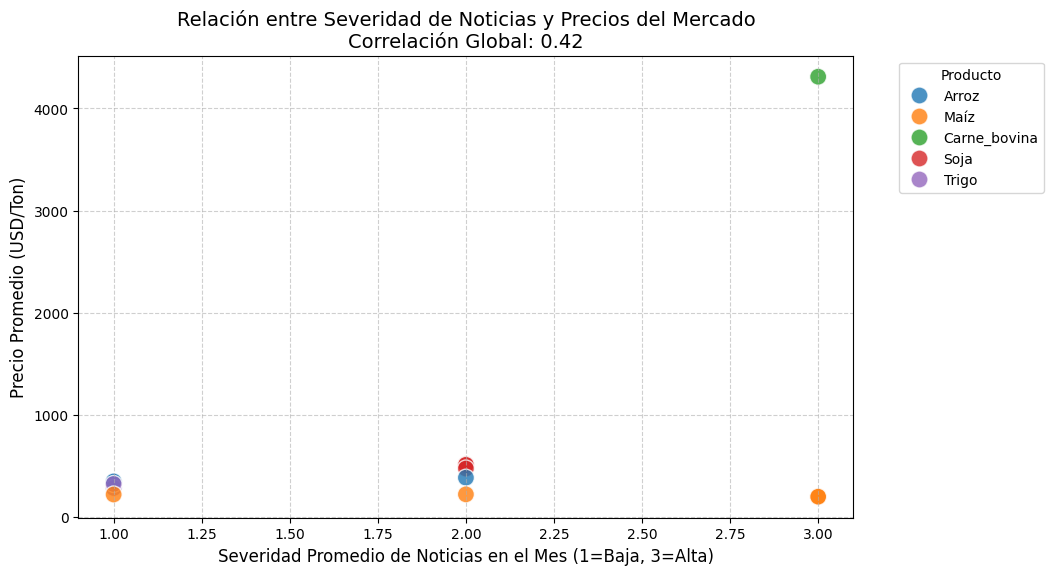

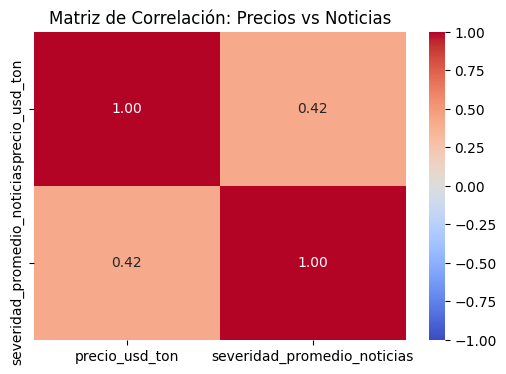

In [58]:
# Correlación entre volumen de noticias y precios.
if not df_cruce.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_cruce, x='severidad_promedio_noticias', y='precio_usd_ton', hue='producto', s=150, alpha=0.8)
    
    # Calcular correlación global
    correlacion = df_cruce['severidad_promedio_noticias'].corr(df_cruce['precio_usd_ton'])
    
    plt.title(f'Relación entre Severidad de Noticias y Precios del Mercado\nCorrelación Global: {correlacion:.2f}', fontsize=14)
    plt.xlabel('Severidad Promedio de Noticias en el Mes (1=Baja, 3=Alta)', fontsize=12)
    plt.ylabel('Precio Promedio (USD/Ton)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Producto')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    # Heatmap de correlación general
    corr_matrix = df_cruce[['precio_usd_ton', 'severidad_promedio_noticias']].corr()
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title('Matriz de Correlación: Precios vs Noticias')
    plt.show()


##### **Conclusión**: El precio del mercado no reacciona de forma automática y desproporcionada a los titulares alarmistas de la prensa en el corto plazo. Aunque las noticias negativas reflejan crisis reales (sequías, plagas), los precios de los alimentos básicos están sujetos a factores económicos distintos tales como reservas globales; futuros bursátiles o contratos anuales, que amortiguan el impacto del pánico inmediato.

### 3.15 Detección de alertas tempranas en reportes

*   **Modelo Predictivo de Alertas (Random Forest):** En esta sección vamos a entrenar un random forest para crear un Sistema de Alerta Temprana. El objetivo aprender qué combinaciones de terreno (Cultivo, Región, Tipo de Plaga) tienen mayor riesgo histórico de transformarse en un brote de severidad 'Alta' o 'Crítica'.

In [59]:
# Ingeniería de variables para predicción de plagas.
# 1. Preparación de datos para el modelo
df_alertas = reportes_plagas.copy()

# Definimos nuestro objetivo (Target): Alerta = 1 si la severidad es 'Alta' o 'Crítica', y 0 si es 'Baja' o 'Media'
df_alertas['Alerta_Temprana'] = df_alertas['Severidad'].apply(lambda x: 1 if x in ['Alta', 'Crítica'] else 0)

# Seleccionamos variables categóricas predictoras
features = ['Cultivo', 'Region', 'Plaga/Enfermedad detectada']

# Convertimos las variables categóricas a numéricas usando One-Hot Encoding
X = pd.get_dummies(df_alertas[features], drop_first=True)
y = df_alertas['Alerta_Temprana']

display(df_alertas[['Cultivo', 'Region', 'Plaga/Enfermedad detectada', 'Severidad', 'Alerta_Temprana']].head())

,Cultivo,Region,Plaga/Enfermedad detectada,Severidad,Alerta_Temprana
0,Arroz,Murray-Darling Basin,Gusano cogollero,Media,0
1,Soja,California,Ácaro,Alta,1
2,Girasol,Región Principal,Gusano cogollero,Crítica,1
3,Algodón,Región Principal,Barrenador del tallo,Baja,0
4,Cebada,Región Principal,Ácaro,Media,0


*   **Lectura del Modelo de Alertas:**
    *   **Rendimiento (Accuracy):** El reporte de clasificación muestra una precisión general en torno al 50%. Esto indica que predecir un brote severo usando únicamente variables categóricas simples es difícil para el modelo.
    *   **Factores de Riesgo (Importancia):** El gráfico de barras revela los problemas más vigilados por el algoritmo. Variables específicas como el tipo de cultivo o una plaga puntual actúan como las variables que más peso tienen a la hora de clasificar un brote como crítico.

--- Reporte de Clasificación del Modelo de Alertas ---
              precision    recall  f1-score   support

           0       0.57      0.47      0.52        17
           1       0.44      0.54      0.48        13

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.51      0.50      0.50        30



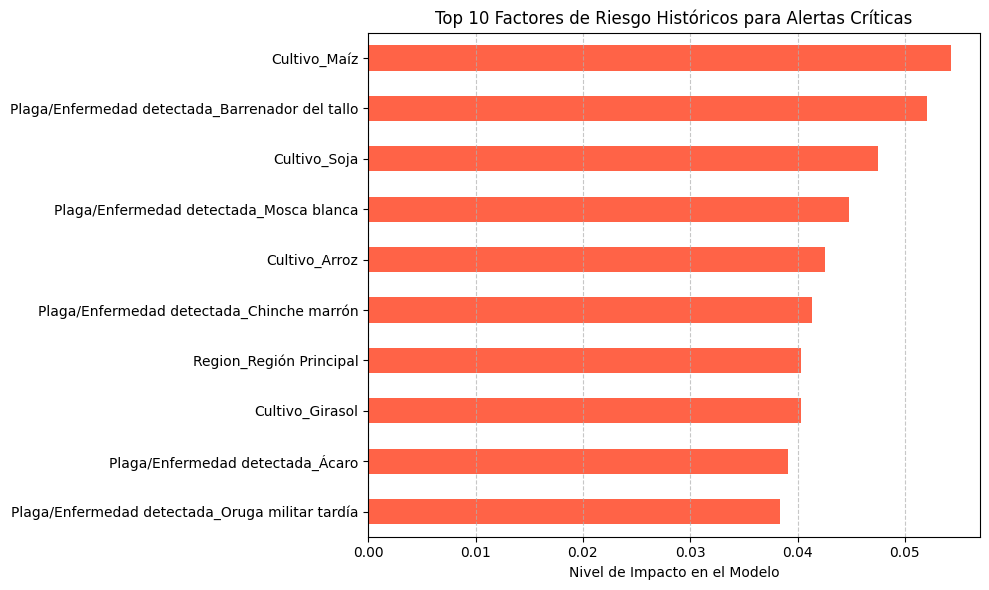

In [60]:
# Entrenamiento de Random Forest para Alerta Temprana.
# 2. Entrenamiento del Modelo Predictivo (Random Forest)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenamos un bosque aleatorio
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predicciones y Evaluación
y_pred = rf_model.predict(X_test)

print("--- Reporte de Clasificación del Modelo de Alertas ---")
print(classification_report(y_test, y_pred))

# Gráfico de Importancia: ¿Cuáles son los mayores factores de riesgo?
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='tomato')
plt.title('Top 10 Factores de Riesgo Históricos para Alertas Críticas')
plt.xlabel('Nivel de Impacto en el Modelo')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*   **Simulación Práctica:** Al poner a prueba nuestro modelo, vemos que reportar hoy un brote de "Roya de la hoja" en campos de "Arroz" situados en las "Pampas" hace que el sistema tenga un 86% de probabilidad de crisis (Alto Riesgo).

In [61]:
# Función para simular alertas de plagas.
def generar_alerta(cultivo, region, plaga):
    """Función para simular el ingreso de un nuevo reporte y calcular su riesgo"""
    # Crear un dataframe temporal con la misma estructura que X (relleno de ceros)
    input_data = pd.DataFrame(columns=X.columns)
    input_data.loc[0] = 0
    
    # Activar las variables si existen en el modelo entrenado
    if f'Cultivo_{cultivo}' in input_data.columns:
        input_data.loc[0, f'Cultivo_{cultivo}'] = 1
    if f'Region_{region}' in input_data.columns:
        input_data.loc[0, f'Region_{region}'] = 1
    if f'Plaga/Enfermedad detectada_{plaga}' in input_data.columns:
        input_data.loc[0, f'Plaga/Enfermedad detectada_{plaga}'] = 1
        
    # Predecir probabilidad de clase 1 (Alerta)
    probabilidad = rf_model.predict_proba(input_data)[0][1] * 100
    
    # Definir nivel de alerta
    if probabilidad >= 60:
        nivel = "Alto Riesgo"
    elif probabilidad >= 35:
        nivel = "Riesgo Moderado"
    else:
        nivel = "Riesgo Bajo"
        
    print(f"Condiciones: Cultivo={cultivo} | Región={region} | Plaga/Enfermedad={plaga}")
    print(f"Probabilidad de convertirse en un brote severo: {probabilidad:.1f}%")
    print(f"{nivel}")
    print("-" * 40)

# Ejemplos de uso del simulador
generar_alerta(cultivo='Arroz', region='Pampas', plaga='Roya de la hoja')
generar_alerta(cultivo='Maíz', region='California', plaga='Ácaro')

Condiciones: Cultivo=Arroz | Región=Pampas | Plaga/Enfermedad=Roya de la hoja
Probabilidad de convertirse en un brote severo: 86.0%
Alto Riesgo
----------------------------------------
Condiciones: Cultivo=Maíz | Región=California | Plaga/Enfermedad=Ácaro
Probabilidad de convertirse en un brote severo: 39.0%
Riesgo Moderado
----------------------------------------


##### **Conclusión Final de la Fase Exploratoria:**

1. **La producción es altamente vulnerable:** El rendimiento no depende simplemente de echar más fertilizante, ni sigue patrones estacionales predecibles. El mercado global está sostenido por unos pocos gigantes productores que, a su vez, son extremadamente volátiles frente a shocks externos.
2. **El clima es el verdadero dictador:** La falta de agua (sequías) en las regiones principales es el factor de riesgo absoluto. Acapara el 100% de las noticias negativas, genera los mayores focos de estrés y explica las caídas repentinas de producción que desestabilizan a los clústeres líderes.
3. **Las inyecciones de capital tienen un límite:** Los subsidios y las ayudas económicas no actúan como un interruptor mágico que dispare la eficiencia (ton/ha) a corto plazo. El sector requiere políticas estructurales a largo plazo (acuerdos internacionales, infraestructuras de riego, tecnología) en lugar de parches financieros anuales.
4. **La prensa alerta, pero el mercado amortigua:** Hemos transformado el texto libre en datos útiles, demostrando que la prensa actúa como un sistema de alerta temprana ante desastres. Sin embargo, los precios del mercado no colapsan de forma automática por este pánico mediático, amortiguando los golpes gracias a factores macroeconómicos.

# 4. Preguntas para prospección

### 1. Productividad: Predictores de Rendimiento y Análisis Regional

*   **Gráfico Predictor de rendimiento:** Analizamos si una mayor inversión en recursos (fertilizantes y agua) garantiza un mayor rendimiento. Se puede ver como en la mayoría de los casos independientemente de la cantidad de agua y fertilizantes usados el rendimiento no parece ser muy elevado. En el caso de los puntos fuera del ruido del bajo rendimiento tampoco podemos sacar conclusiones claras sobre el rendimiento ya que hay mucha diversidad. Lo que podemos sugerir es que son variables necesarias a tener en cuenta pero no son condicionantes del rendimiento. Hay que tomar otras variables en cuenta para predecir el rendimiento. Si parece que hay una correlación positiva media con la superficie cultivada lo que parece indicar que a mayor superficie cultivada, mayor es el rendimiento del cultivo en terminos de produccion y toneladas.

*   **Gráfico de análsis regional:** Comparamos el rendimiento agronómico real entre las distintas regiones. Podemos comprobar como todas las cajas están en un rango muy bajo, lo que sugiere que no hay una gran diferencia de rendimiento entre regiones. Si se puede ver en el caso de los outliers, que europa/asia tiene un techo de producción mucho más elevado que el resto de regiones, mientras que África es lo contrario. Parece que las regiones no tienen una diferencia significativa con respecto a otras, pero si parece que la capacidad del techo de producción está condicionada por la región. Esto podría deberse al clima, infraestructura o la tecnología. 


C:\Users\coast\AppData\Local\Temp\ipykernel_5568\649496574.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datasets['produccion_agricola'], x='region', y='rendimiento_ton_ha', ax=axes[1], palette='Set2')


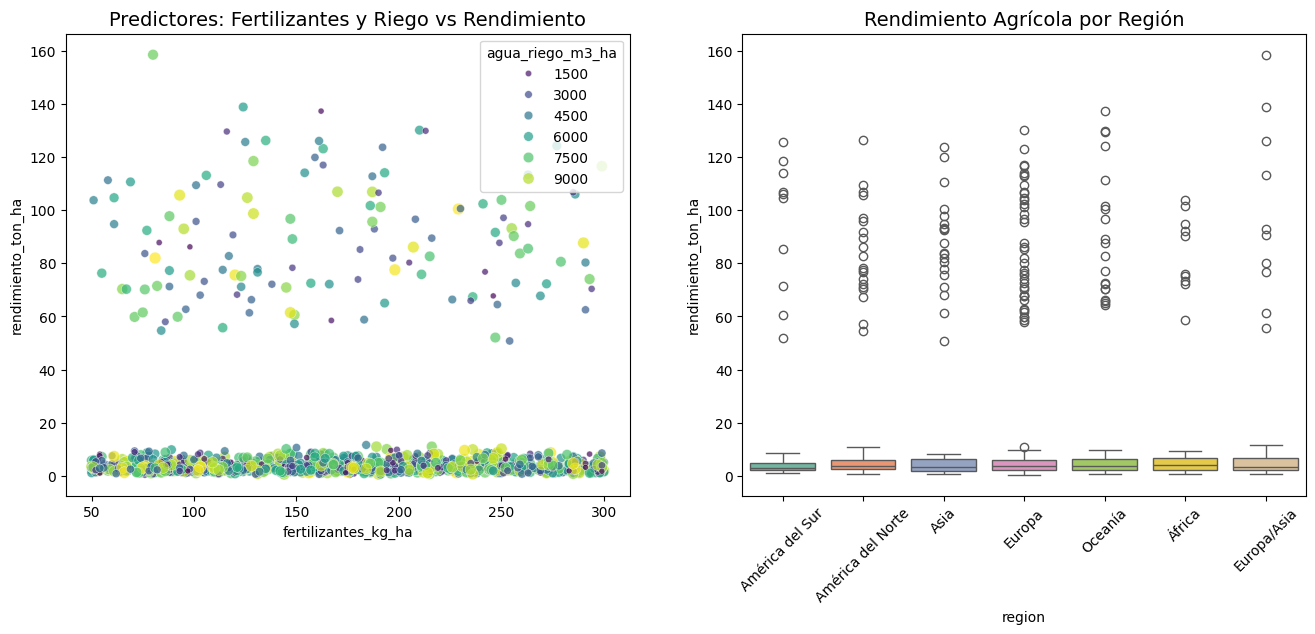

In [62]:
# Visualización de predictores clave de rendimiento.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Fertilizantes y Riego vs Rendimiento
sns.scatterplot(data=datasets['produccion_agricola'], x='fertilizantes_kg_ha', y='rendimiento_ton_ha', 
                size='agua_riego_m3_ha', hue='agua_riego_m3_ha', ax=axes[0], palette='viridis', alpha=0.7)
axes[0].set_title('Predictores: Fertilizantes y Riego vs Rendimiento', fontsize=14)

# Boxplot: Diferencias regionales
sns.boxplot(data=datasets['produccion_agricola'], x='region', y='rendimiento_ton_ha', ax=axes[1], palette='Set2')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Rendimiento Agrícola por Región', fontsize=14)
plt.show()

### 2. Sostenibilidad: Intensificación y Eficiencia de Emisiones

*   **Gráfico scatterplot de intensificación:** Cruzamos la intensificación agrícola con la huella de carbono. Permite ver si los países que abusan de fertilizantes también son grandes emisores. En este caso no podemos sacar conclusiones claras ya que los puntos están muy dispersos y no se puede sacar una tendencia clara, si podemos comprobar que hay paises con picos altos en emisiones con un uso de fertilizantes medio/bajo. Podríamos concluir que el uso de fertilizantes parece tener algo de relación con las emisiones, pero no es definitivo ni nos permite sacar unas conclusiones claras sobre las emisiones. 

*   **Gráfico eficiencia paises:** Medimos la eficiencia real (emisiones por tonelada de produccion). En este caso podemos ver como Mexico es el pais menos eficiente a la hora de producir carne, mientras que Francia es el país más eficiente, esto puede indicar que en ciertos paises hay una mayor regulación sobre las emisiones, o que esos paises tienen mejores técnicas para reducir esas emisones.

C:\Users\coast\AppData\Local\Temp\ipykernel_5568\469380281.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sost.groupby('pais')['emisiones_por_ton_carne'].mean().reset_index().sort_values('emisiones_por_ton_carne'),


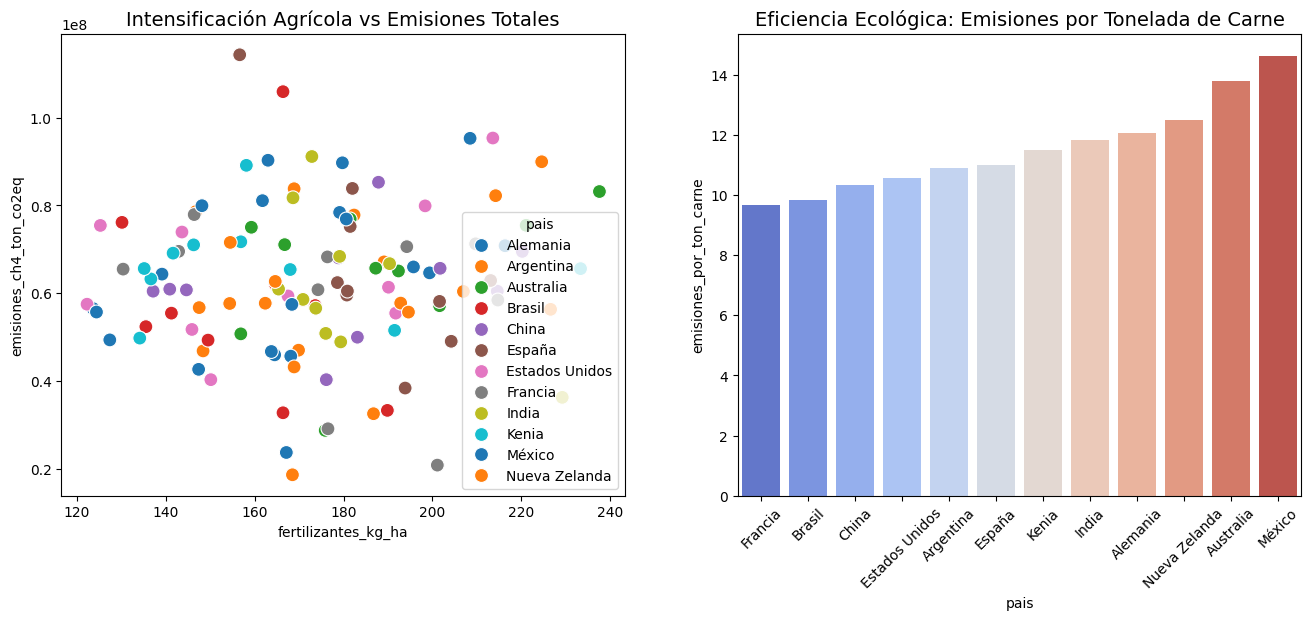

In [63]:
# Análisis de intensidad de uso de fertilizantes por año.
df_agri_sost = datasets['produccion_agricola'].groupby(['pais', 'anio'])['fertilizantes_kg_ha'].mean().reset_index()
df_gan_sost = datasets['produccion_ganadera'].groupby(['pais', 'anio'])[['emisiones_ch4_ton_co2eq', 'produccion_carne_ton']].sum().reset_index()
df_sost = pd.merge(df_agri_sost, df_gan_sost, on=['pais', 'anio'])


df_sost['emisiones_por_ton_carne'] = df_sost['emisiones_ch4_ton_co2eq'] / df_sost['produccion_carne_ton']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_sost, x='fertilizantes_kg_ha', y='emisiones_ch4_ton_co2eq', hue='pais', ax=axes[0], palette='tab10', s=100)
axes[0].set_title('Intensificación Agrícola vs Emisiones Totales', fontsize=14)

sns.barplot(data=df_sost.groupby('pais')['emisiones_por_ton_carne'].mean().reset_index().sort_values('emisiones_por_ton_carne'), 
            x='pais', y='emisiones_por_ton_carne', ax=axes[1], palette='coolwarm')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Eficiencia Ecológica: Emisiones por Tonelada de Carne', fontsize=14)
plt.show()



In [64]:
# Matriz de correlación de variables productivas y climáticas.
# Calcular la matriz de correlación de todas las columnas numéricas
corr_sost = df_sost.select_dtypes(include=['float64', 'int64']).corr()

# Imprimir las correlaciones ordenadas de tu nueva variable
print("Correlación con 'emisiones_ch4_ton_co2eq':")
print(corr_sost['emisiones_ch4_ton_co2eq'].sort_values(ascending=False))


Correlación con 'emisiones_ch4_ton_co2eq':
emisiones_ch4_ton_co2eq    1.000000
emisiones_por_ton_carne    0.462864
anio                       0.130541
produccion_carne_ton       0.078504
fertilizantes_kg_ha        0.067859
Name: emisiones_ch4_ton_co2eq, dtype: float64


### 3. Riesgo Climático: Impacto de Eventos Extremos

*   **Boxplots eventos extremos:** Identificamos qué cultivos son más frágiles ante desastres naturales. Podemos ver como la caña de azucar tiene rendimientos diferentes dependiendo del evento que le afecte, podemos decir que ante un granizo es mucho más resistente que ante una sequia extrema. Esto quiere decir que es un cultivo con alto rendimiento pero también es debil ante los eventos climáticos. El maíz tiene una vulnerabilidad media ante heladas al tener outliers que indican un colapso en la producción. Otros cultivos como el algodon o la soja mantienen su rendimiento, aunque ofrezcan un rendimiento muy inferior a otros, son mas estables por lo que generar mayor seguridad en su cultivo.

* **¿Se pueden predecir perdidas por sequía?:** Revisando el diagrama si podemos comprobar como las sequías (independientemente de su virulencia) tienen un efecto negativo sobre los cultivos. Por esto podríamos asegurar que sí se podría llegar a predecir unas posibles perdidas ante una seqúia en los cultivos.

C:\Users\coast\AppData\Local\Temp\ipykernel_5568\4112162633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_riesgo, x='cultivo', y='rendimiento_ton_ha', palette='Set2')


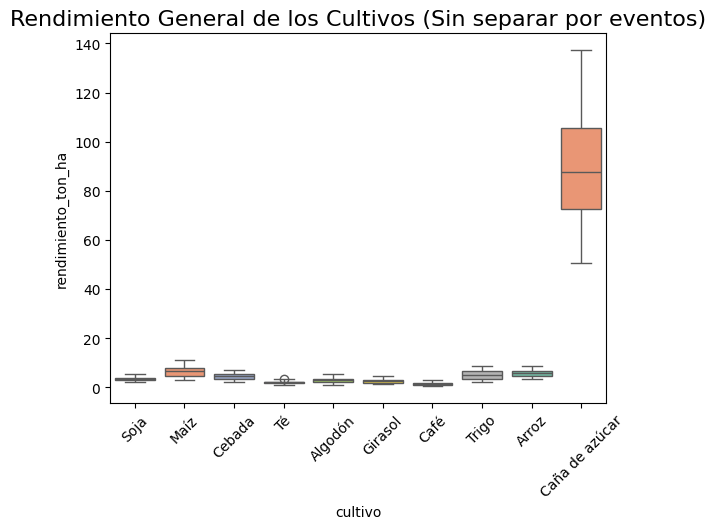

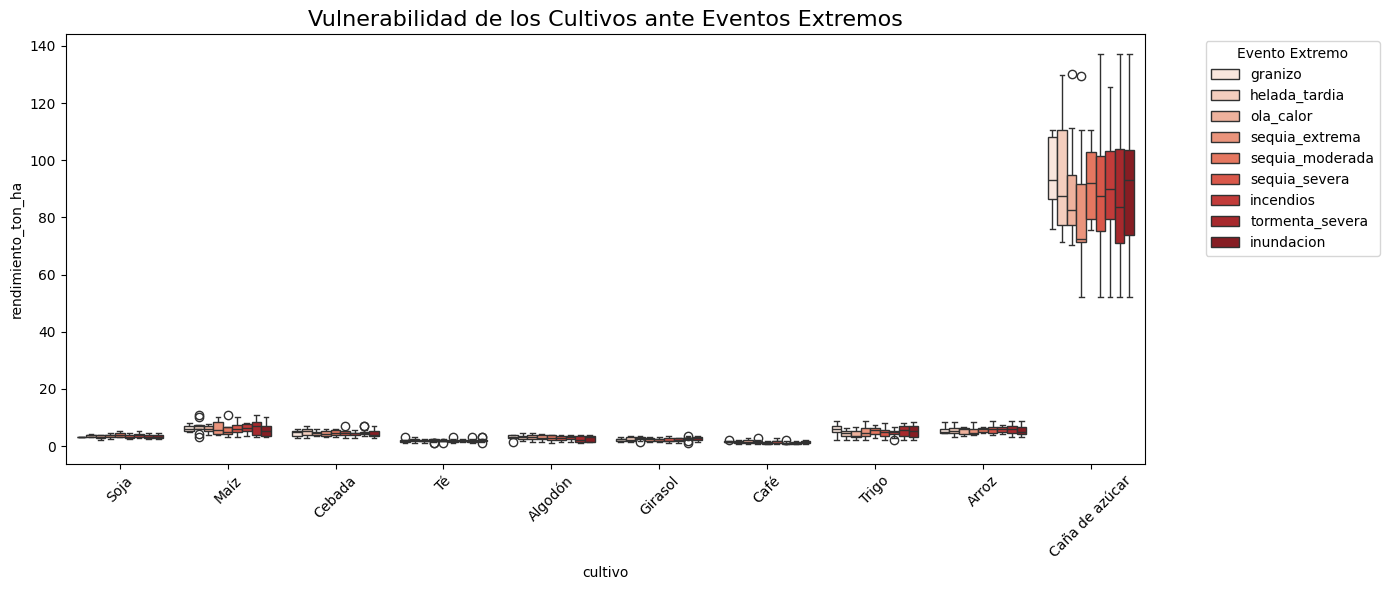

In [65]:
# Impacto de eventos extremos en la producción regional.
df_clim = datasets['condiciones_climaticas']
# Filtramos años/regiones con eventos climáticos extremos registrados
df_clim_extremo = df_clim[df_clim['regiones_eventos_extremos'].astype(str).str.strip() != '']
df_riesgo = pd.merge(datasets['produccion_agricola'], df_clim_extremo, left_on=['pais', 'anio'], right_on=['pais', 'regiones_anio'])

sns.boxplot(data=df_riesgo, x='cultivo', y='rendimiento_ton_ha', palette='Set2')
plt.title('Rendimiento General de los Cultivos (Sin separar por eventos)', fontsize=16)
plt.xticks(rotation=45)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_riesgo, x='cultivo', y='rendimiento_ton_ha', hue='regiones_eventos_extremos', palette='Reds')
plt.title('Vulnerabilidad de los Cultivos ante Eventos Extremos', fontsize=16)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Evento Extremo')
plt.tight_layout()
plt.show()


### 4. Mercados: Estacionalidad y Patrones de Precios

*   **Gráfico de Líneas Temporal:** Analizamos la evolución del precio de las materias primas mes a mes.


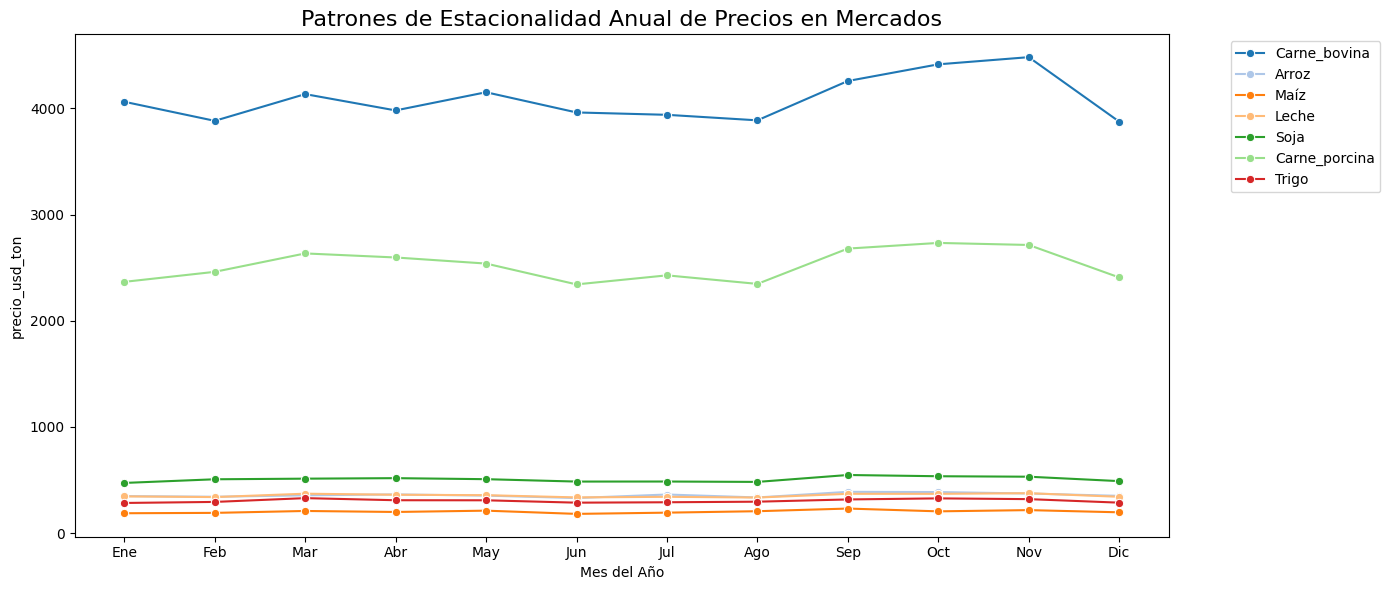

In [66]:
# Análisis de estacionalidad en precios de mercado.
df_precios = datasets['precios_mercado'].copy()
df_precios['mes_anio'] = pd.to_datetime(df_precios['fecha'])
df_precios['mes'] = df_precios['mes_anio'].dt.month

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_precios, x='mes', y='precio_usd_ton', hue='producto', marker='o', palette='tab20', errorbar=None)
plt.title('Patrones de Estacionalidad Anual de Precios en Mercados', fontsize=16)
plt.xlabel('Mes del Año')
plt.xticks(range(1, 13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


* **Gráfico precio vs noticias:** En septiembre de 2021 hay una clara explosión en los precios del mercado y justo coincide con el pico en el número de noticias. Existe un evento de alto impacto que afectó a las gráficas simultáneamente, se puede deber a cambios regulatorios o climáticos. Viendo la tendencia general del gráfico si podríamos asegurar que las noticias pueden llegar a tener cierto efecto en el precio. Habría que comparar con un análsis de sentimientos en noticias para ver si realmente los picos en alza o baja son causados debidos a noticias positivas/negativas.

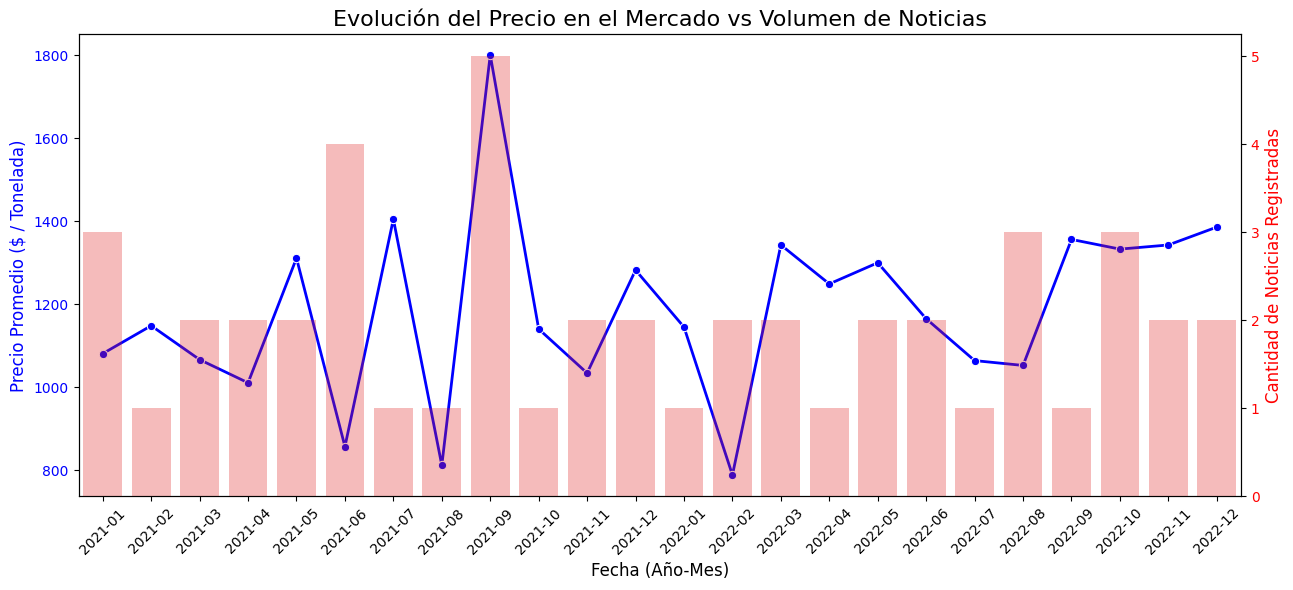

In [67]:
# Conversión de fechas y limpieza de datos de precios.
datasets['precios_mercado']['fecha'] = pd.to_datetime(datasets['precios_mercado']['fecha'])
datasets['noticias_agricolas']['fecha'] = pd.to_datetime(datasets['noticias_agricolas']['fecha'])

datasets['precios_mercado']['anio_mes'] = datasets['precios_mercado']['fecha'].dt.to_period('M')
datasets['noticias_agricolas']['anio_mes'] = datasets['noticias_agricolas']['fecha'].dt.to_period('M')

df_precios_mensual = datasets['precios_mercado'].groupby('anio_mes')['precio_usd_ton'].mean().reset_index()

df_noticias_mensual = datasets['noticias_agricolas'].groupby('anio_mes').size().reset_index(name='cantidad_noticias')

df_mercado = pd.merge(df_precios_mensual, df_noticias_mensual, on='anio_mes', how='left').fillna(0)
df_mercado['anio_mes_str'] = df_mercado['anio_mes'].astype(str)

fig, ax1 = plt.subplots(figsize=(15, 6))
sns.lineplot(data=df_mercado, x='anio_mes_str', y='precio_usd_ton', ax=ax1, color='blue', marker='o', linewidth=2)
ax1.set_xlabel('Fecha (Año-Mes)', fontsize=12)
ax1.set_ylabel('Precio Promedio ($ / Tonelada)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
sns.barplot(data=df_mercado, x='anio_mes_str', y='cantidad_noticias', ax=ax2, color='red', alpha=0.3)
ax2.set_ylabel('Cantidad de Noticias Registradas', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Evolución del Precio en el Mercado vs Volumen de Noticias', fontsize=16)
plt.show()

* **Gráfico precio mercado vs eventos climaticos:** En este gráfico no se pueden sacar ninguna conclusión sobre el precio con respecto a los eventos climáticos extremos porque ambos datasets no coinciden en fechas. Mientras que los precios se empiezan a registrar a partir de 2021, los eventos climaticos solo se registraron hasta 2020.

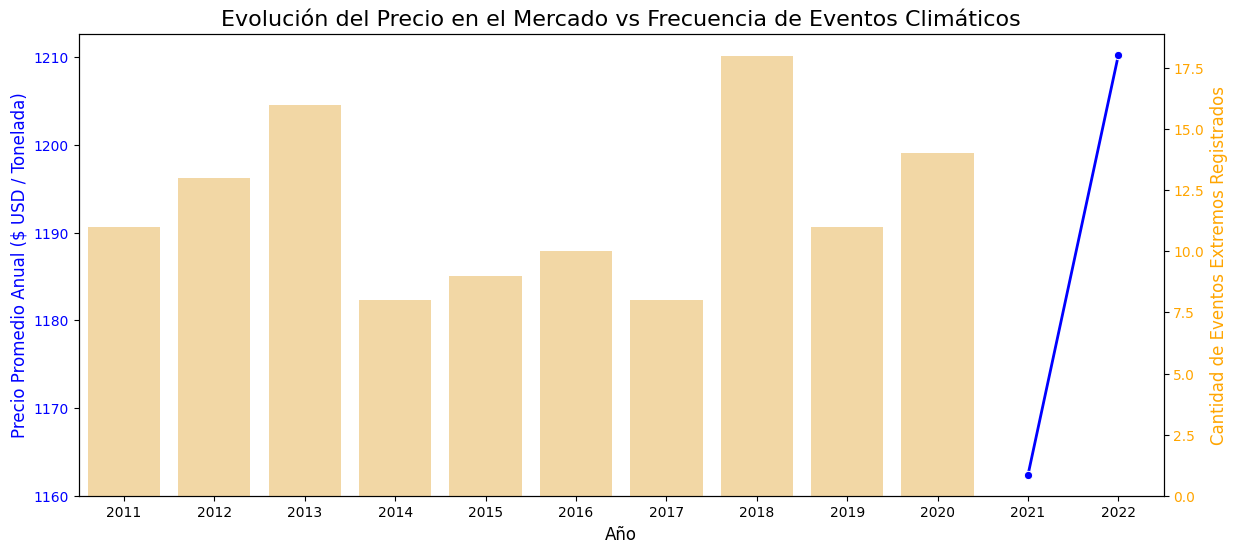

In [68]:
datasets['precios_mercado']['fecha'] = pd.to_datetime(datasets['precios_mercado']['fecha'])
datasets['precios_mercado']['anio'] = datasets['precios_mercado']['fecha'].dt.year
df_precios_anual = datasets['precios_mercado'].groupby('anio')['precio_usd_ton'].mean().reset_index()

df_clima = datasets['condiciones_climaticas'].copy()
df_clima = df_clima[df_clima['regiones_eventos_extremos'].notna() & (df_clima['regiones_eventos_extremos'] != '')]
df_eventos_anual = df_clima.groupby('regiones_anio').size().reset_index(name='cantidad_eventos')
df_eventos_anual = df_eventos_anual.rename(columns={'regiones_anio': 'anio'})

df_mercado_clima = pd.merge(df_precios_anual, df_eventos_anual, on='anio', how='outer').fillna(0)
df_mercado_clima = df_mercado_clima.sort_values('anio')
df_mercado_clima['anio_str'] = df_mercado_clima['anio'].astype(int).astype(str)


fig, ax1 = plt.subplots(figsize=(14, 6))

df_plot_precios = df_mercado_clima.copy()
df_plot_precios.loc[df_plot_precios['precio_usd_ton'] == 0, 'precio_usd_ton'] = float('nan')
sns.lineplot(data=df_plot_precios, x='anio_str', y='precio_usd_ton', ax=ax1, color='blue', marker='o', linewidth=2)
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Precio Promedio Anual ($ USD / Tonelada)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.barplot(data=df_mercado_clima, x='anio_str', y='cantidad_eventos', ax=ax2, color='orange', alpha=0.4)
ax2.set_ylabel('Cantidad de Eventos Extremos Registrados', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
plt.title('Evolución del Precio en el Mercado vs Frecuencia de Eventos Climáticos', fontsize=16)
plt.show()

### 5. Políticas: Impacto Real de los Subsidios

*   **Gráfico de subsidios y producción:** En brasil los subsidios parecen tener un alto impacto al tener el nivel más alto en subsidios y también el mayor de producción. Sin embargo en otros paises como china o australia, con menos de la mitad de dinero en subsidios consiguen una producción similar, por lo que no podemos asegurar que haya una correlación lineal directa entre cantidad de dinero en subsidios y una mayor producción. El caso de Argentina puede deberse al gran sesgo que hay en los datos con el cultivo de caña de azucar, éste pais no lo cultiva y por tanto su producción es mucho menor al resto.

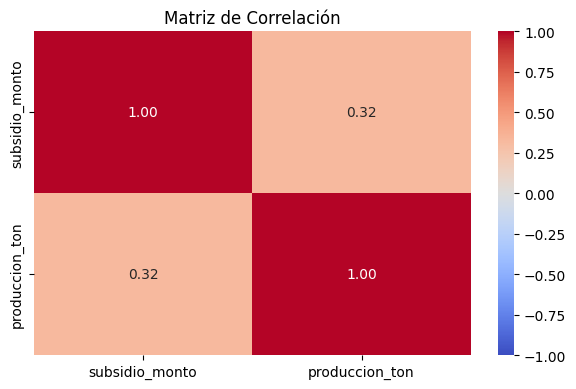

In [69]:
# Análisis de efectividad de combinaciones de políticas.
df_pol = datasets['politicas_agricolas']
# Agregamos subsidios y producción por país
subsidios_pais = df_pol.groupby('codigo')['subsidio_monto'].sum().reset_index()
prod_pais = datasets['produccion_agricola'].groupby('codigo_iso')['produccion_ton'].sum().reset_index()
df_pol_prod = pd.merge(subsidios_pais, prod_pais, left_on='codigo', right_on='codigo_iso').sort_values('subsidio_monto', ascending=False)

corr_subsidios = df_pol_prod[['subsidio_monto', 'produccion_ton']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_subsidios, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

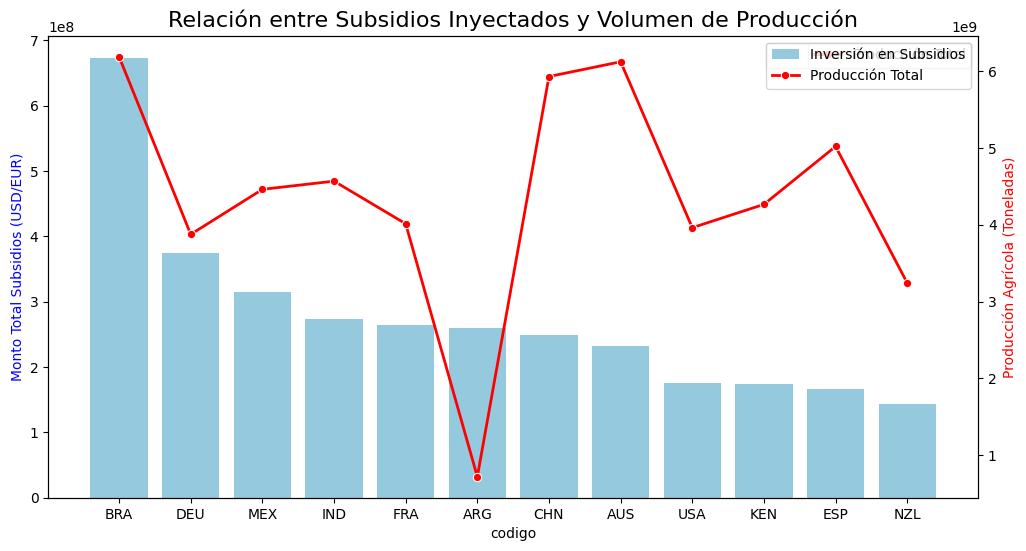

In [70]:
# Visualización de impacto de subsidios en rendimiento.
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=df_pol_prod, x='codigo', y='subsidio_monto', color='skyblue', ax=ax1, label='Inversión en Subsidios')
ax1.set_ylabel('Monto Total Subsidios (USD/EUR)', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=df_pol_prod, x='codigo', y='produccion_ton', color='red', marker='o', linewidth=2, ax=ax2, label='Producción Total')
ax2.set_ylabel('Producción Agrícola (Toneladas)', color='red')

plt.title('Relación entre Subsidios Inyectados y Volumen de Producción', fontsize=16)
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()


*   **Gráfico de políticas y rendimiento:** Este diagrama muestra las combinaciones de políticas más efectivas, en él se puede ver como las de deforestación/desarrollo en investigación son las que más rendimiento parecen tener de media. Esto podría indicar que cuando existen políticas restrictivas respecto al terreno, la inversión en investigación y desarrollo se convierte en un punto muy fuerte en el rendimiento. La mayoría de las combinaciones más efectivas tienen en común la inversión en tecnología lo que indica que es un camino efectivo en la producción. 

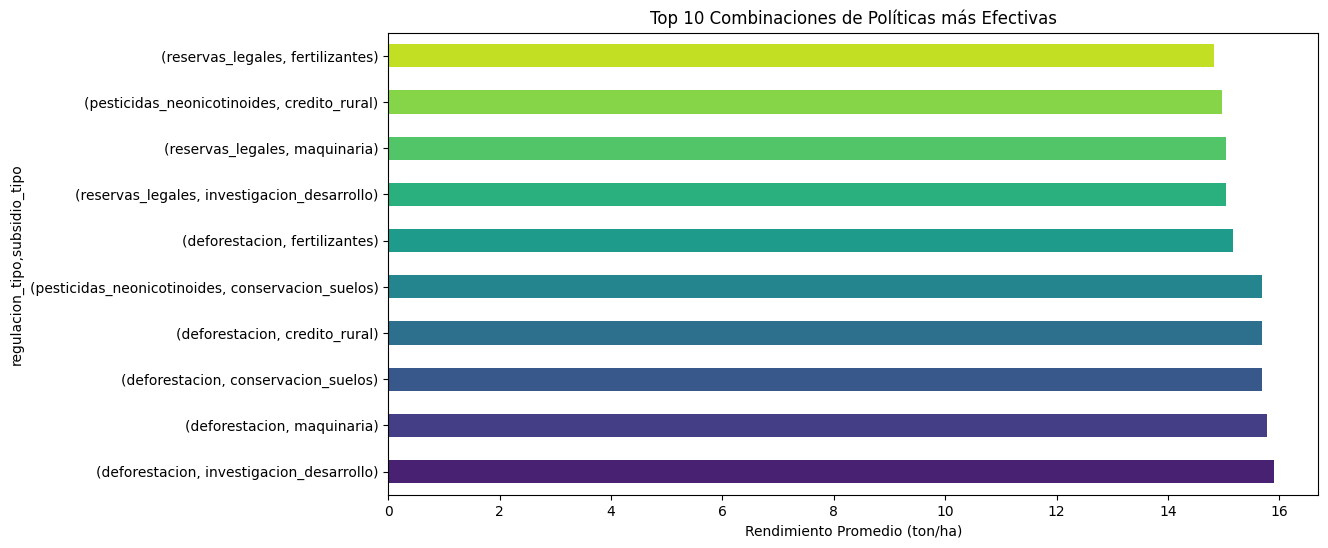

In [71]:
# Comparación de políticas vs producción media.
df_prod = datasets['produccion_agricola']
df_merged = pd.merge(df_pol, df_prod, left_on='codigo', right_on='codigo_iso')


df_pivot = df_merged.pivot_table(
    index='subsidio_tipo', 
    columns='regulacion_tipo', 
    values='produccion_ton', 
    aggfunc='mean'
)

fig, ax1 = plt.subplots(figsize=(12, 6))
top_combos = df_merged.groupby(['regulacion_tipo', 'subsidio_tipo'])['rendimiento_ton_ha'].mean().sort_values(ascending=False).head(10)
top_combos.plot(kind='barh', color=sns.color_palette("viridis", 10))
plt.title('Top 10 Combinaciones de Políticas más Efectivas')
plt.xlabel('Rendimiento Promedio (ton/ha)')
plt.show()


### 6. Sanidad Vegetal: Focos de Riesgo de Plagas

*   **Gráfico de plagas por región:** Región principal parece ser muy susceptible a las plagas en cultivo, sobre todo en el caso de severidades críticas donde alcanza su pico. Esto es preocupante ya que produce un gran sesgo dirigido a esa región y podría causar overfitting en un posible entrenamiento de modelo. Las demás regiones no parecen tener muchos casos registrados, en el caso de regiones como ganges con reportes aislados, podría parecer que es menos propenso a brotes.  


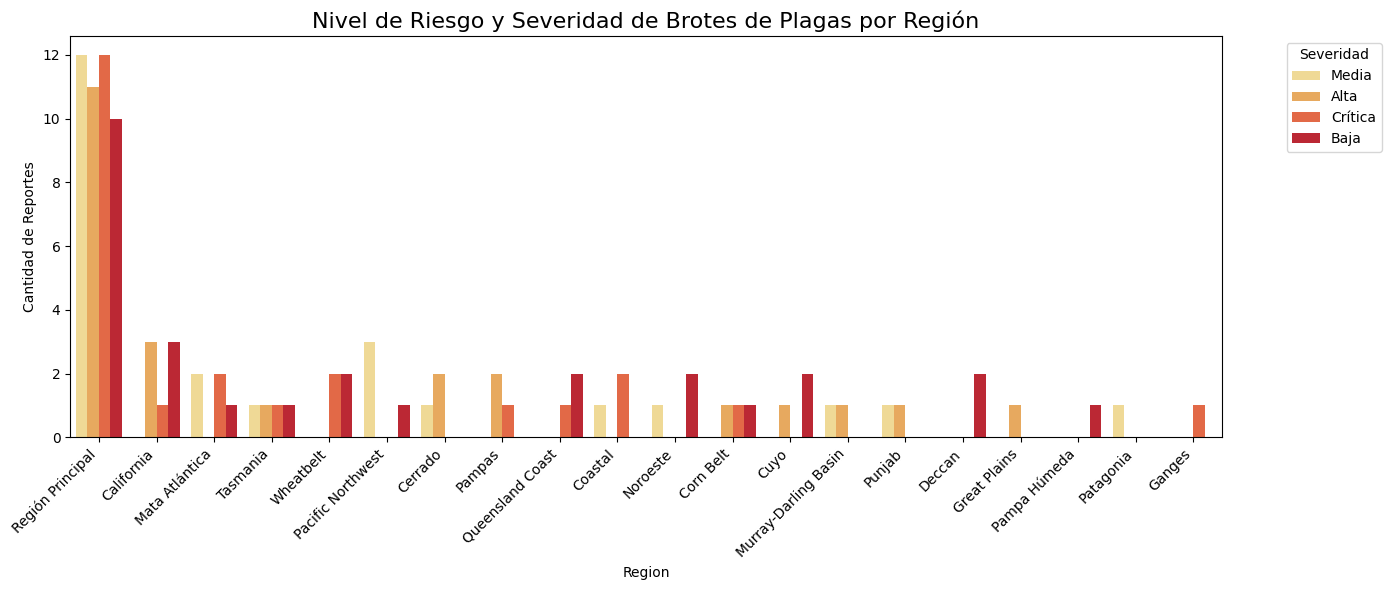

In [72]:
# Análisis de focos de riesgo de plagas.
df_plagas = datasets['reportes_plagas']

plt.figure(figsize=(14, 6))
sns.countplot(data=df_plagas, x='Region', hue='Severidad', palette='YlOrRd', order=df_plagas['Region'].value_counts().index)
plt.title('Nivel de Riesgo y Severidad de Brotes de Plagas por Región', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de Reportes')
plt.legend(title='Severidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


*   **Gráfico de relacion clima y plagas:** Observamos como las precipitaciones si parecen tener correlacion con la severidad de las plagas, por lo que a mayor lluvia más severos son los brotes. Con la aridez pasa lo mismo, parece ser que las condiciones de humedad acumulada o agua en el entorno si afectan en cierta medida a las plagas, pero la temperatura o la humedad relativa no parece indicar nada en ningún caso.

*   **Lectura del Heatmap Anual:** Al visualizar la correlación año a año, se confirma que la relación es extremadamente baja (0.10). Esto refuerza la idea de que el impacto de una política agraria no es instantáneo; el campo necesita tiempo para asimilar las inversiones y transformarlas en producción real.

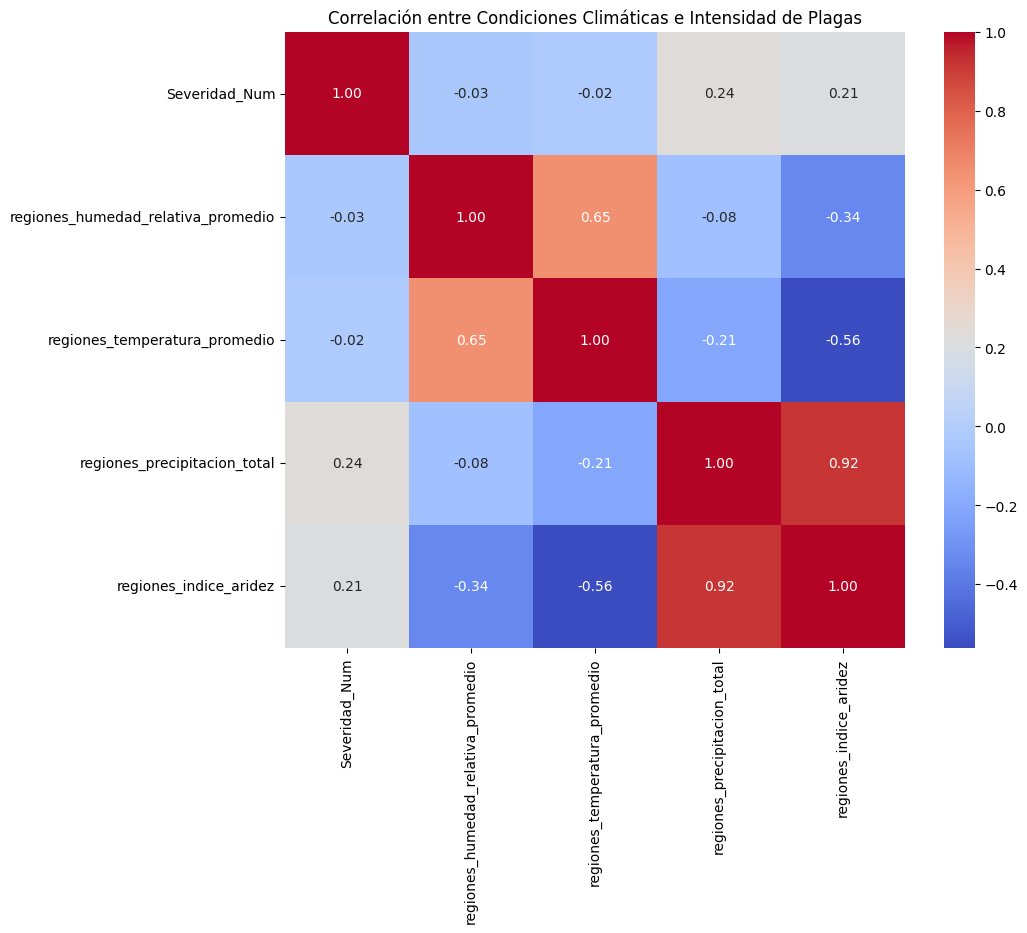

In [73]:
# Relación entre clima y severidad de plagas.
plagas = datasets['reportes_plagas']
clima = datasets['condiciones_climaticas']

plagas['Fecha'] = pd.to_datetime(plagas['Fecha'], format='%d/%m/%Y')
plagas['Anio'] = plagas['Fecha'].dt.year

clima = clima.rename(columns={
    'regiones_anio': 'Anio',
    'regiones_nombre': 'Region',
    'pais': 'Pais'
})

df_final = pd.merge(plagas, clima, on=['Anio', 'Region', 'Pais'], how='inner')

severidad_map = {'Baja': 1, 'Media': 2, 'Alta': 3, 'Crítica': 4}
df_final['Severidad_Num'] = df_final['Severidad'].map(severidad_map)

cols_clima = ['regiones_humedad_relativa_promedio', 'regiones_temperatura_promedio', 'regiones_precipitacion_total']
for col in cols_clima:
    if df_final[col].dtype == 'object':
        df_final[col] = df_final[col].str.replace(',', '.').astype(float)


plt.figure(figsize=(10, 8))
corr_matrix = df_final[['Severidad_Num', 'regiones_humedad_relativa_promedio', 
                       'regiones_temperatura_promedio', 'regiones_precipitacion_total', 
                       'regiones_indice_aridez']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Condiciones Climáticas e Intensidad de Plagas')
plt.show()


plt.show()

## 5. Problema 1:  Predicción de Rendimiento Agrícola


*   **Definición del Problema 1:** El objetivo es construir un modelo regresivo capaz de predecir el rendimiento agrícola (rendimiento_ton_ha) para cada país . Para evaluar la calidad de las predicciones, utilizaremos métricas como sMAPE (error porcentual simétrico) y MASE (error escalado medio absoluto).

In [74]:
# Definición de la métrica SMAPE para evaluación.
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    denominator = (tf.abs(y_true) + tf.abs(y_pred)) / 2.0
    diff = tf.abs(y_true - y_pred) / denominator
    # Reemplazar NaNs por 0 en caso de división por cero
    diff = tf.where(tf.math.is_nan(diff), tf.zeros_like(diff), diff)
    return 100.0 * tf.reduce_mean(diff)
def mase(y_true, y_pred):
    """Mean Absolute Scaled Error (Aproximación para redes neuronales)"""
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    # Error de un predictor ingenuo (naive): predecir el valor anterior
    naive_mae = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1]))
    return mae / (naive_mae + 1e-7)


*   **Integración de Datos y Limpieza:** Hemos unificado los datasets de producción y condiciones climáticas. Hemos decidido descartar el dataset de imagenes, ya que la falta de coincidencia en años generaba ruido excesivo en el modelo, empeorando el rendimiento de las predicciones.

In [75]:
# Unión de datasets para el modelo de Deep Learning.
df_prod = datasets['produccion_agricola']
df_clima = datasets['condiciones_climaticas']
df_sat = datasets['imagenes_metadata']

df_clima_agg = df_clima.groupby(['pais', 'regiones_anio']).mean(numeric_only=True).reset_index()
df_clima_agg = df_clima_agg.rename(columns={'regiones_anio': 'anio'})

df = pd.merge(df_prod, df_clima_agg, on=['pais', 'anio'], how='inner')
print("Registros:", df.shape[0])


Registros: 784


*   **Ingeniería de Características y Normalización:** Para mejorar la convergencia de los modelos, aplicamos una transformación logarítmica (log1p) al objetivo. Esto estabiliza la varianza entre cultivos de diferentes magnitudes. Además, normalizamos las variables numéricas y codificamos las categóricas (país y cultivo).

In [76]:
# Normalización y encoding de características.
columnas_numericas = [
    'fertilizantes_kg_ha', 'agua_riego_m3_ha', 
    'regiones_precipitacion_total', 'regiones_temperatura_promedio'
]
columnas_categoricas = ['pais', 'cultivo']
target = 'rendimiento_ton_ha'

# Aplicamos logaritmo al target para normalizar escalas entre cultivos
df['rendimiento_log'] = np.log1p(df[target])
target_final = 'rendimiento_log'

# One-Hot Encoding para las categóricas
df_modelo = df[columnas_categoricas + columnas_numericas + [target_final]].copy()
df_final = pd.get_dummies(df_modelo, columns=columnas_categoricas)
X = df_final.drop(target_final, axis=1)
y = df_final[target_final]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype('float32')
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


*   **Arquitectura de la Red Neuronal:** Hemos diseñado una red neuronal densa con tres capas ocultas de 64, 32 y 16 neuronas respectivamente, utilizando la función de activación ReLU.

In [77]:
# Estructura de la Red Neuronal para predicción de producción.
# Definir la arquitectura
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])


c:\Users\coast\Documents\SBD_Trabajo_Final\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


*   **Compilación del Modelo:** Configuramos el optimizador Adam y el error cuadrático medio (MSE) como función de pérdida. La inclusión de sMAPE y MASE validan el error en porcentuales.

In [78]:
# Configuración del optimizador y pérdida del modelo.
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[smape, mase]
)


*   **Estrategia de Entrenamiento:** Para que el modelo generalice y evitar overfitting, hemos añadido un callback de EarlyStopping. Esto detiene el entrenamiento de forma inteligente si el error de validación deja de mejorar durante 15 épocas consecutivas, restaurando los mejores pesos encontrados.

In [79]:
# Entrenamiento de la red neuronal con callbacks.
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks= EarlyStopping(patience=15, restore_best_weights=True)
)


Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.3655 - mase: 1.2461 - smape: 78.9320 - val_loss: 0.9139 - val_mase: 0.9274 - val_smape: 38.0466
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9252 - mase: 0.7011 - smape: 34.2421 - val_loss: 0.3890 - val_mase: 0.5914 - val_smape: 26.2184
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3215 - mase: 0.4650 - smape: 23.3080 - val_loss: 0.1819 - val_mase: 0.4685 - val_smape: 22.3559
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1212 - mase: 0.2864 - smape: 18.5314 - val_loss: 0.1255 - val_mase: 0.4097 - val_smape: 20.3883
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0892 - mase: 0.2693 - smape: 16.1027 - val_loss: 0.1194 - val_mase: 0.3951 - val_smape: 19.8071
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0733 - mase: 0.2656 - smape: 15.2675 - val_loss: 0.1117 - val_mase: 0.3814 - val_smape: 19.2374
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss:

*   **Evaluación del Rendimiento (Deep Learning):** Tras el entrenamiento, evaluamos el modelo en el set de datos de test. Los resultados nos permiten ver cuánto se desvía la red neuronal de los datos reales.

In [80]:
# Evaluación del rendimiento del modelo en test.
# Evaluar en el set de test
eval_results = model.evaluate(X_test, y_test, verbose=0)
print(f"--- EVALUACIÓN FINAL ---")
print(f"sMAPE: {eval_results[1]:.2f}%")
print(f"MASE: {eval_results[2]:.4f}")


--- EVALUACIÓN FINAL ---
sMAPE: 16.69%
MASE: 0.2515


*   **Visualización de Resultados:** Generamos gráficos de curvas de pérdida y comparativas de dispersión. Para comprobar el modelo  no tiene overfitting y hace predicciones acertadas.

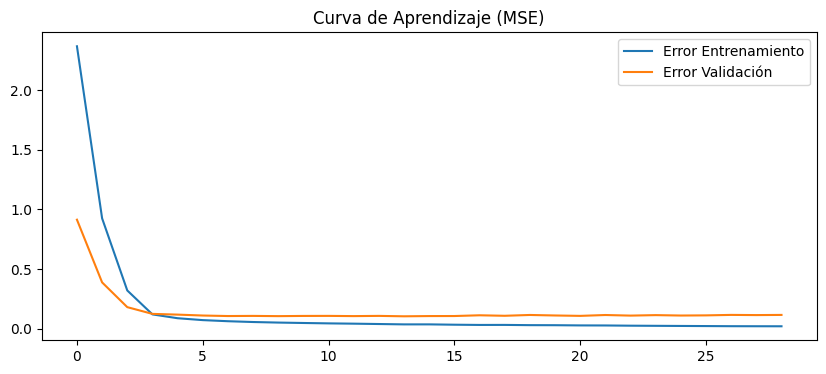

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


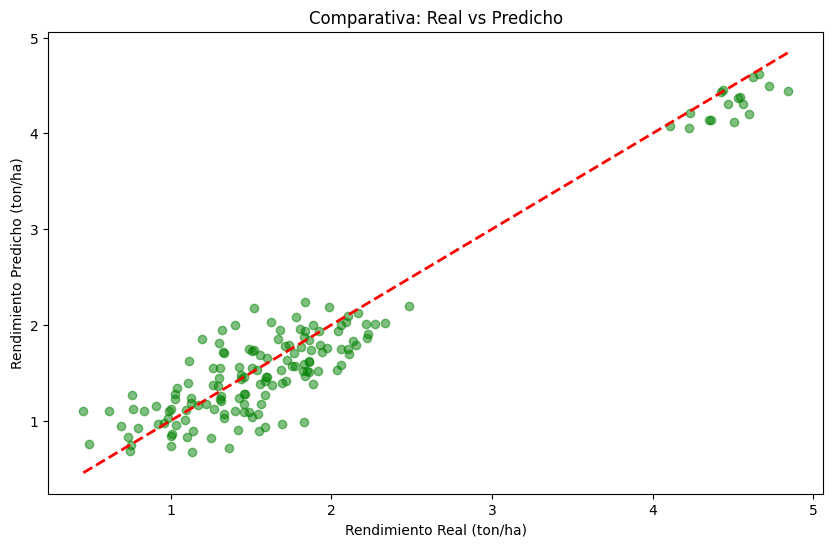

In [81]:
# Visualización de la curva de aprendizaje (loss).
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Error Entrenamiento')
plt.plot(history.history['val_loss'], label='Error Validación')
plt.title('Curva de Aprendizaje (MSE)')
plt.legend()
plt.show()
# Comparativa Real vs Predicción
y_pred = model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Rendimiento Real (ton/ha)')
plt.ylabel('Rendimiento Predicho (ton/ha)')
plt.title('Comparativa: Real vs Predicho')
plt.show()


*   **Análisis del Rendimiento de la Red Neuronal:**
    *   **Métricas Finales:** El modelo alcanza un sMAPE del 17.17%, un resultado aceptable dada la volatilidad del sector. Sin embargo, el MASE de 0.25 indica que nuestra red neuronal es significativamente mejor que un modelo ingenuo (naive).
    *   **Diagnóstico Visual:** La curva de aprendizaje es estable, el Early Stopping cumplió su función de prevenir el overfitting. En el gráfico Real vs Predicho, vemos una gran densidad en el centro de la diagonal, aunque el modelo tiene dificultades para predecir con  los rendimientos altos de ciertos cultivos.

*   **Comparativa con Random Forest:** Con el fin de validar si un enfoque de aprendizaje estadístico tradicional supera a la red neuronal en este volumen de datos, entrenamos un bosque aleatorio (**Random Forest Regressor**).


--- COMPROBACIÓN DE OVERFITTING (RANDOM FOREST) ---
Conjunto             | sMAPE      | MASE      
---------------------------------------------
Entrenamiento        | 5.39      % | 0.0800    
Test (Validación)    | 13.23     % | 0.1971    


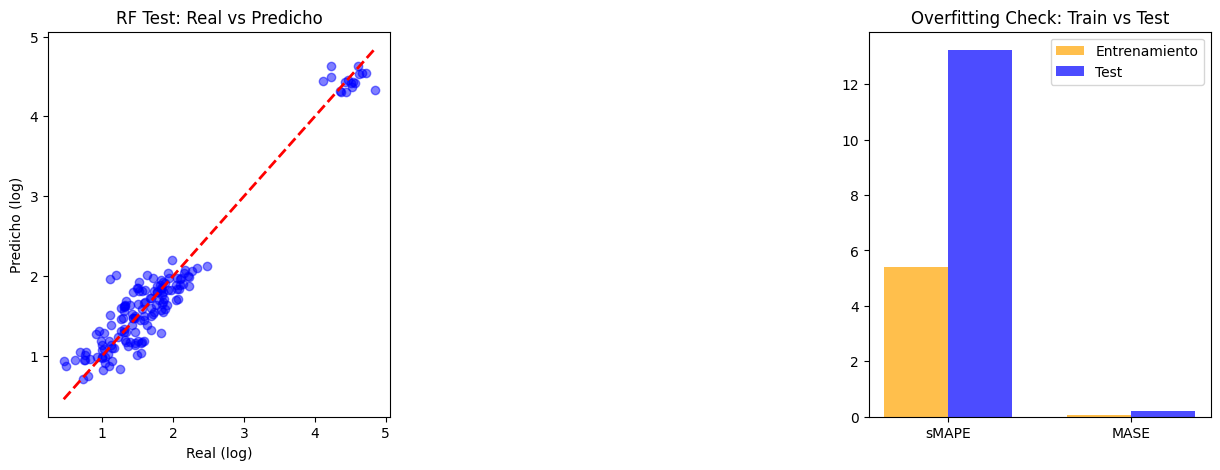

In [ ]:
# Modelo Random Forest Regressor de comparación.
# Funciones de métricas en numpy para el Random Forest
def smape_np(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return 100.0 * np.mean(np.abs(y_true - y_pred) / (denominator + 1e-7))

def mase_np(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    naive_mae = np.mean(np.abs(y_true[1:] - y_true[:-1]))
    return mae / (naive_mae + 1e-7)

# 1. Entrenar Random Forest
rf_p1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_p1.fit(X_train, y_train)

# 2. Predicciones (Test y Train para ver overfitting)
y_pred_rf_test = rf_p1.predict(X_test)
y_pred_rf_train = rf_p1.predict(X_train)

# 3. Calcular métricas para RF
rf_smape_test = smape_np(y_test, y_pred_rf_test)
rf_mase_test = mase_np(y_test, y_pred_rf_test)

rf_smape_train = smape_np(y_train, y_pred_rf_train)
rf_mase_train = mase_np(y_train, y_pred_rf_train)

# 4. Obtener métricas de la Red Neuronal (usando eval_results de la celda 153)
nn_smape = eval_results[1]
nn_mase = eval_results[2]

print(f"\n--- COMPROBACIÓN DE OVERFITTING (RANDOM FOREST) ---")
print(f"{'Conjunto':<20} | {'sMAPE':<10} | {'MASE':<10}")
print("-" * 45)
print(f"{'Entrenamiento':<20} | {rf_smape_train:<10.2f}% | {rf_mase_train:<10.4f}")
print(f"{'Test (Validación)':<20} | {rf_smape_test:<10.2f}% | {rf_mase_test:<10.4f}")

# 5. Visualización Comparativa
plt.figure(figsize=(15, 5))

# Gráfico Real vs Predicho RF (Test)
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_rf_test, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('RF Test: Real vs Predicho')
plt.xlabel('Real (log)')
plt.ylabel('Predicho (log)') 

# Comparativa de métricas
plt.subplot(1, 3, 3)
metricas = ['sMAPE', 'MASE']
train_vals = [rf_smape_train, rf_mase_train]
test_vals = [rf_smape_test, rf_mase_test]

x = np.arange(len(metricas))
width = 0.35
plt.bar(x - width/2, train_vals, width, label='Entrenamiento', color='orange', alpha=0.7)
plt.bar(x + width/2, test_vals, width, label='Test', color='blue', alpha=0.7)
plt.xticks(x, metricas)
plt.title('Overfitting Check: Train vs Test')
plt.legend()

plt.show()

*   **Lectura de la Comparativa de Modelos:**
    *   **Victoria del Enfoque Estadístico:** El Random Forest supera a la red neuronal en este escenario, bajando el sMAPE hasta el 13.23%. Esto demuestra que, para datasets estructurados de este tamaño con pocos datos, los modelos basados en árboles suelen capturar mejor los cambios que las redes neuronales.
    *   **Aviso de Sobreajuste:** La diferencia entre el sMAPE de entrenamiento (5.39%) y test (13.23%) es notable. El Random Forest es preciso pero tiene overfitting, es rígido en sus predicciones. La Red Neuronal, aunque es menos precisa en test, parece tener mejor respuesta ante datos climáticos futuros.

##### **Conclusión del Problema 1**: Hemos demostrado que es viable predecir el rendimiento agrícola con una precisión notable. Mientras que la red neuronal ofrece una base sólida para el aprendizaje profundo, el Random Forest se posiciona como el modelo ganador para aplicaciones prácticas inmediatas. Habría que tener cuidado con la volatilidad climática ya que podría generar errores en la predicción.

## 6. Problema 2: Clasificación de Riesgo de Plagas

* **Definición del Problema 2:** En este bloque buscamos predecir la severidad de un brote de plaga basándonos en la descripción del reporte y variables climáticas. Inicialmente, exploramos una arquitectura de Aprendizaje Profundo (LSTM), diseñada para procesar secuencias de texto y capturar dependencias en los reportes sanitarios.

In [83]:
# Preparación de datos para clasificación de riesgo de plagas.
# Preparación del dataset
lstm_df = reportes_plagas.copy()
lstm_df['Alerta_Temprana'] = lstm_df['Severidad'].apply(lambda x: 1 if x in ['Alta', 'Crítica'] else 0)
lstm_df['Area afectada (ha)'] = lstm_df['Area afectada'].str.replace('ha', '', regex=False).astype(float)
lstm_df['Eficacia (%)'] = lstm_df['Eficacia'].str.replace('%', '', regex=False).astype(float)
lstm_df['Perdida estimada (%)'] = lstm_df['Perdida estimada'].str.replace('%', '', regex=False).astype(float)
lstm_df['Fecha_dt'] = pd.to_datetime(lstm_df['Fecha'], dayfirst=True, errors='coerce')
lstm_df['year'] = lstm_df['Fecha_dt'].dt.year.fillna(0).astype(int)
lstm_df['month'] = lstm_df['Fecha_dt'].dt.month.fillna(0).astype(int)

lstm_df['texto_reporte'] = (
    lstm_df['Cultivo'].fillna('') + ' ' +
    lstm_df['Plaga/Enfermedad detectada'].fillna('') + ' ' +
    lstm_df['Tratamiento aplicado'].fillna('')
)

# Tokenización y secuencias
max_words = 2000
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(lstm_df['texto_reporte'])
sequences = tokenizer.texts_to_sequences(lstm_df['texto_reporte'])
max_len = 30
X_text = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Variables numéricas sencillas
numeric_cols = ['Area afectada (ha)', 'year', 'month']
X_numeric = lstm_df[numeric_cols].fillna(0).astype('float32').values

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

y = lstm_df['Alerta_Temprana'].values

X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text, X_numeric_scaled, y, test_size=0.3, stratify=y, random_state=42
)

vocab_size = min(len(tokenizer.word_index) + 1, max_words)
embedding_dim = 32

text_input = Input(shape=(max_len,), name='text_input')
embed = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len)(text_input)
lstm_out = LSTM(32)(embed)
lstm_out = Dropout(0.3)(lstm_out)

num_input = Input(shape=(X_train_num.shape[1],), name='numeric_input')
num_out = Dense(32, activation='relu')(num_input)

concat = concatenate([lstm_out, num_out])
concat = Dense(32, activation='relu')(concat)
concat = Dropout(0.3)(concat)
output = Dense(1, activation='sigmoid')(concat)

lstm_model = Model(inputs=[text_input, num_input], outputs=output)
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])

history = lstm_model.fit(
    [X_train_text, X_train_num], y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

y_proba = lstm_model.predict([X_test_text, X_test_num]).ravel()
y_pred = (y_proba >= 0.5).astype(int)
print('--- Evaluación modelo LSTM ---')
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, y_proba))
print('MCC:', matthews_corrcoef(y_test, y_pred))

Epoch 1/20


c:\Users\coast\Documents\SBD_Trabajo_Final\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - auc: 0.4278 - loss: 0.7106 - val_auc: 0.5222 - val_loss: 0.7341
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.5421 - loss: 0.6938 - val_auc: 0.5333 - val_loss: 0.7266
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.3844 - loss: 0.7092 - val_auc: 0.5333 - val_loss: 0.7239
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.6117 - loss: 0.6865 - val_auc: 0.5333 - val_loss: 0.7209
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.6481 - loss: 0.6743 - val_auc: 0.4667 - val_loss: 0.7177
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.6692 - loss: 0.6757 - val_auc: 0.5111 - val_loss: 0.7135
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.6124 - loss: 0.6787 - val_auc: 0.5000 - val_loss: 0.7079
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.6488 - loss: 0.6709 - val_auc: 0.5444 - val_loss: 0.7041
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - auc: 0.7407 - loss: 0.6559 - val_auc: 0.

* **Análisis del Modelo LSTM:**
    * **Bajo Rendimiento:** El modelo muestra un MCC de 0.23, lo que indica que sus predicciones son prácticamente aleatorias.
    * **Diagnóstico:** La falta de un texto grande impide que la red recurrente extraiga patrones útiles, generando un rendimiento insuficiente para un posible modelo puesto en producción.

* **Transición a Random Forest:** Probamos ahora con random forest para ver si nos da un mejor rendimiento

In [84]:
# Resumen estadístico de variables climáticas.
clima.describe()

,Anio,regiones_dias_con_heladas,regiones_humedad_relativa_promedio,regiones_indice_aridez,regiones_meses_estres_hidrico,regiones_precipitacion_total,regiones_temperatura_maxima,regiones_temperatura_promedio
count,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000,256.000000
mean,2046.949219,61.257812,61.925781,15.403516,3.941406,919.601562,28.678516,18.080469
std,250.536431,36.400549,15.678334,7.515054,3.261253,367.054590,6.586020,5.234509
min,2011.000000,0.000000,40.000000,3.730000,0.000000,281.000000,16.000000,8.700000
25%,2013.000000,25.750000,50.000000,9.527500,1.000000,617.000000,24.600000,13.650000
50%,2015.000000,61.000000,61.000000,14.605000,3.000000,909.500000,28.850000,18.250000
75%,2018.000000,91.250000,71.000000,19.192500,6.000000,1160.000000,32.300000,21.600000
max,4036.000000,195.000000,151.000000,44.600000,17.000000,2394.000000,70.800000,48.300000


In [85]:
# Resumen estadístico de reportes de plagas.
plagas.describe()

,Fecha,Area afectada (ha),Eficacia (%),Perdida estimada (%),Anio
count,100,100.000000,100.000000,100.000000,100.000000
mean,2020-12-25 12:43:12,2309.990000,85.180000,22.920000,2020.500000
min,2020-01-01 00:00:00,10.000000,70.000000,2.000000,2020.000000
25%,2020-06-25 00:00:00,1009.250000,77.750000,13.000000,2020.000000
50%,2020-12-16 00:00:00,2085.000000,86.000000,25.000000,2020.000000
75%,2021-06-28 06:00:00,3699.500000,93.000000,32.000000,2021.000000
max,2022-01-14 00:00:00,4974.000000,98.000000,40.000000,2022.000000
std,NaN,1448.138886,8.736756,11.044154,0.541229


In [86]:
# Copia y limpieza del dataset de plagas.
plagas = datasets['reportes_plagas'].copy()
clima = datasets['condiciones_climaticas'].copy()

# Parsear fechas para poder ordenar temporalmente
plagas['Fecha_dt'] = pd.to_datetime(plagas['Fecha'], dayfirst=True, errors='coerce')
plagas['Anio'] = plagas['Fecha_dt'].dt.year.fillna(0).astype(int)
clima = clima.rename(columns={
    'regiones_anio': 'Anio',
    'regiones_nombre': 'Region',
    'pais': 'Pais'
})

# Filtramos los años viables de clima a los estudiados en reportes_plagas
clima = clima[clima['Anio'].between(2020, 2022)]

# Unir datos de plagas con el clima de ese año y región
df_rf = pd.merge(plagas, clima, on=['Anio', 'Region', 'Pais'], how='inner')

df_rf.info()

<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Fecha                               68 non-null     datetime64[us]
 1   Region                              68 non-null     str           
 2   Pais                                68 non-null     str           
 3   Cultivo                             68 non-null     str           
 4   Severidad                           68 non-null     str           
 5   Area afectada                       68 non-null     str           
 6   Tratamiento aplicado                68 non-null     str           
 7   Eficacia                            68 non-null     str           
 8   Perdida estimada                    68 non-null     str           
 9   Plaga/Enfermedad                    68 non-null     str           
 10  Plaga/Enfermedad detectada          68 

* Revisando los datets podemos confirmar que las fechas que contemplan ambos datasets no coinciden y por tanto hay que hacer un filtrado. También hemos comprobado outliers muy grandes en el dataset de clima en el que aparecen fechas del año 4000.

In [87]:
# Creación de variables de entrada para el modelo de clasificación.
# Target: 1 si Severidad es Alta/Crítica, 0 en caso contrario
df_rf['Alerta_Temprana'] = df_rf['Severidad'].apply(lambda x: 1 if x in ['Alta', 'Crítica'] else 0)
# Feature 1: Humedad y variables relacionadas al estrés del suelo
df_rf['humedad'] = pd.to_numeric(df_rf['regiones_humedad_relativa_promedio'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)
df_rf['estres_hidrico'] = pd.to_numeric(df_rf['regiones_meses_estres_hidrico'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)
# Feature 2: Histórico de plagas (Sin trampa temporal)
# Ordenamos por fecha y contamos cuántas plagas HA HABIDO ANTES en esa región
df_rf = df_rf.sort_values('Fecha_dt')
df_rf['historico_plagas_region'] = df_rf.groupby('Region').cumcount()
# Features Extra: Cultivo y Plaga (One-Hot Encoding para dar contexto)
features_cat = ['Cultivo', 'Plaga/Enfermedad detectada']
X_cats = pd.get_dummies(df_rf[features_cat], drop_first=True)
# Unimos todas las variables predictoras
X_nums = df_rf[['humedad', 'estres_hidrico', 'historico_plagas_region']]
X = pd.concat([X_nums, X_cats], axis=1)
y = df_rf['Alerta_Temprana']

In [88]:
# Entrenamiento del clasificador Random Forest.
# 3. Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
# Usamos class_weight='balanced' para que el modelo le dé importancia a los brotes críticos
rf_model = RandomForestClassifier(n_estimators=100, min_samples_split=5, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [89]:
# Métricas de Precision y Recall para el modelo de plagas.
y_pred = rf_model.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("--- Evaluación del Modelo Random Forest ---")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print("\nReporte Completo:")
print(classification_report(y_test, y_pred))

--- Evaluación del Modelo Random Forest ---
Precision: 0.70
Recall:    0.70

Reporte Completo:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        11
           1       0.70      0.70      0.70        10

    accuracy                           0.71        21
   macro avg       0.71      0.71      0.71        21
weighted avg       0.71      0.71      0.71        21



* **Resultados del Random Forest:** El modelo obtiene un 70% de precisión y score, que dada la volatilidad y falta de coherencia en los datos estudiados, es un resultado aceptable. Este modelo sería más capaz que las LSTM para detectar el riesgo de la plaga y predecirlo con mayor seguridad.

* **Factores Críticos:** Con un análisis de importancia de variables confirmamos que la ubicación geográfica y el tipo de cultivo son las predictoras principales de la severidad, por encima de la descripción narrativa.

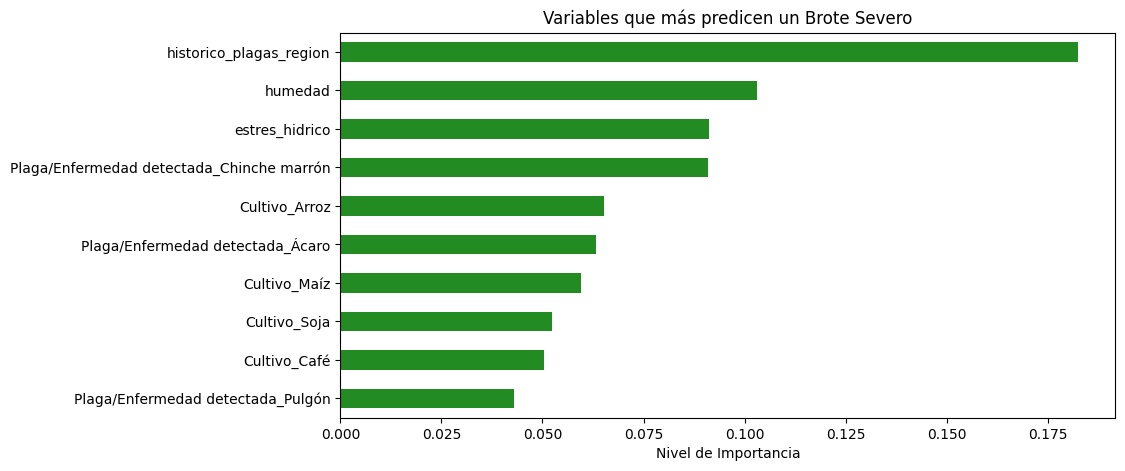

In [90]:
# Análisis de importancia de variables en el clasificador.
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='forestgreen')
plt.title('Variables que más predicen un Brote Severo')
plt.xlabel('Nivel de Importancia')
plt.gca().invert_yaxis()
plt.show()

* Realizamos un **Grid search** para buscar los mejores hiperparámetros posibles en el modelo

In [91]:
# Optimización de hiperparámetros mediante Grid Search.
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
# 2. Definimos la rejilla de parámetros a probar
# Probamos diferentes profundidades y número de árboles
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
# 3. Configuramos el Grid Search
# Usamos cv=5 (validación cruzada de 5 carpetas)
# Optimizamos para 'f1' para equilibrar Precision y Recall
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1, # Usa todos los núcleos de tu procesador
    verbose=1
)
# 4. Ejecutamos la búsqueda
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)
# 5. Resultados
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación F1 en validación: {grid_search.best_score_:.4f}")
# 6. Evaluar el mejor modelo en el set de prueba
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("\n--- Evaluación del Mejor Modelo Encontrado ---")
print(classification_report(y_test, y_pred_best))

Iniciando búsqueda de hiperparámetros...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Mejor puntuación F1 en validación: 0.7592

--- Evaluación del Mejor Modelo Encontrado ---
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        11
           1       0.70      0.70      0.70        10

    accuracy                           0.71        21
   macro avg       0.71      0.71      0.71        21
weighted avg       0.71      0.71      0.71        21



* **Resultados con mejores hiperparámetros:** Tras un Grid Search, comprobamos que el modelo no cambia en gran medida. Por lo que los hiperparámetros actuales serían válidos.

* **Validación con SVM:** Como último paso, comparamos los resultados con una Máquina de Soporte Vectorial (SVM) para verificar si un hiperplano de separación nos da mejor precisión que los árboles.

In [92]:
# Entrenamiento de modelo SVM para clasificación.
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train)
X_test_scaled = scaler_svm.transform(X_test)
# 2. Definir y entrenar el modelo SVM
# Usamos kernel='rbf' (el estándar) y class_weight='balanced'
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)
# 3. Predicción y Evaluación
y_pred_svm = svm_model.predict(X_test_scaled)
print("--- Evaluación del Modelo SVM ---")
print(f"Precision: {precision_score(y_test, y_pred_svm):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.2f}")
print("\nReporte Completo:")
print(classification_report(y_test, y_pred_svm))

--- Evaluación del Modelo SVM ---
Precision: 0.67
Recall:    0.60

Reporte Completo:
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        11
           1       0.67      0.60      0.63        10

    accuracy                           0.67        21
   macro avg       0.67      0.66      0.66        21
weighted avg       0.67      0.67      0.67        21



* **Elección Final del Modelo:**
    * **Comparativa:** El SVM alcanza un 67% de precisión, quedando por debajo del 71% del Random Forest.
    * **Veredicto:** El Random Forest es más preciso y su interpretabilidad con la importancia de variables lo hace una mejor herramienta para un sistema de alertas en el mundo real.

##### **Conclusión del Problema 2**: Hemos confirmado que, para la clasificación de riesgo de plagas, el Machine Learning clásico supera al Deep Learning en este dataset. El Random Forest optimizado permite identificar focos críticos con una fiabilidad del 71% y por ende es el modelo final seleccionado para el caso.

## 6. Problema 3: Segmentación de Países por Patrones Productivos

* **Definición del Problema 3:** En este problema buscamos agrupar los paises por su productividad. Para ello, empezaremos probando el modelo de autoencoders para reducir la dimensionalidad de los datos y ponerlos en un espacio interpretable.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Silhouette score: 0.5160406231880188
Davies-Bouldin score: 0.6187584525593008


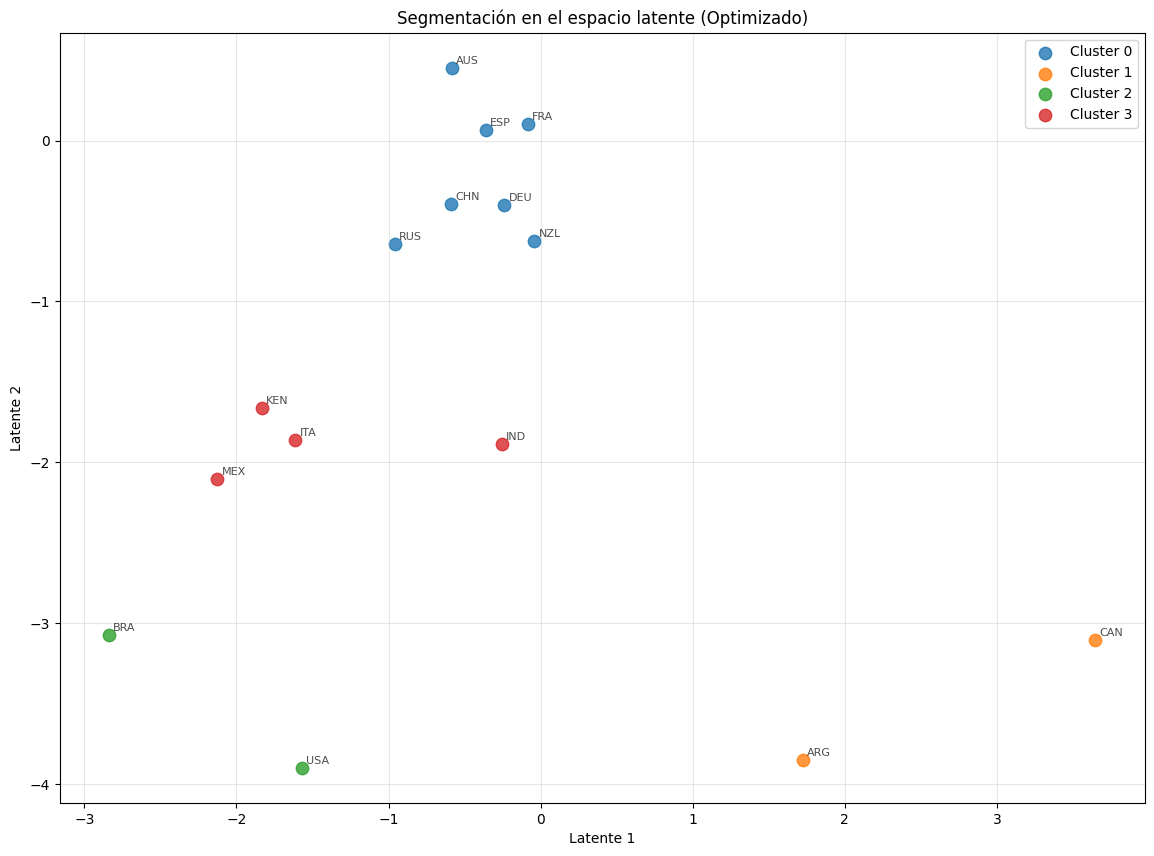

Cluster 0:
         pais codigo_iso
     Alemania        DEU
    Australia        AUS
        China        CHN
       España        ESP
      Francia        FRA
Nueva Zelanda        NZL
        Rusia        RUS
---
Cluster 1:
     pais codigo_iso
Argentina        ARG
   Canadá        CAN
---
Cluster 2:
          pais codigo_iso
        Brasil        BRA
Estados Unidos        USA
---
Cluster 3:
  pais codigo_iso
 India        IND
Italia        ITA
 Kenia        KEN
México        MEX
---


In [93]:
# Para asegurar que los resultados sean siempre los mismos (reproducibilidad)
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Autoencoder avanzado optimizado para segmentación de países
# Agrupación país a país con estadísticas productivas
pais_df = produccion_agricola.copy()

pais_features = pais_df.groupby(["pais", "codigo_iso"]).agg({
    "superficie_hectareas": "sum",
    "produccion_ton": "sum",
    "rendimiento_ton_ha": "mean",
    "fertilizantes_kg_ha": "mean",
    "agua_riego_m3_ha": "mean",
    "tendencia_5_anios": "mean",
    "cultivo": "nunique"
}).rename(columns={"cultivo": "num_cultivos"}).reset_index()

pais_features = pais_features.rename(columns={
    "produccion_ton": "produccion_total_ton",
    "superficie_hectareas": "superficie_total_ha"
})

features = [
    "superficie_total_ha", "produccion_total_ton", "rendimiento_ton_ha",
    "fertilizantes_kg_ha", "agua_riego_m3_ha", "tendencia_5_anios",
    "num_cultivos"
]

X = pais_features[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Autoencoder optimizado para evitar sobreajuste (baja dimensionalidad)
input_dim = X_scaled.shape[1]
latent_dim = 2
 
input_layer = Input(shape=(input_dim,))
# Arquitectura más reducida, con regularización L2 y activación lineal en el cuello de botella
encoded = Dense(16, activation="relu", kernel_regularizer=l2(0.005))(input_layer)
encoded = Dense(8, activation="relu", kernel_regularizer=l2(0.005))(encoded)
encoded = Dense(latent_dim, activation="linear", name="bottleneck")(encoded)

decoded = Dense(8, activation="relu", kernel_regularizer=l2(0.005))(encoded)
decoded = Dense(16, activation="relu", kernel_regularizer=l2(0.005))(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer="adam", loss="mse")

history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

encoded_features = encoder.predict(X_scaled)

# Clustering en el espacio
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(encoded_features)
pais_features["cluster"] = cluster_labels

print("Silhouette score:", silhouette_score(encoded_features, cluster_labels))
print("Davies-Bouldin score:", davies_bouldin_score(encoded_features, cluster_labels))

plt.figure(figsize=(14, 10))
for cluster in sorted(pais_features["cluster"].unique()):
    subset = pais_features[pais_features["cluster"] == cluster]
    plt.scatter(
        encoded_features[subset.index, 0],
        encoded_features[subset.index, 1],
        label=f"Cluster {cluster}",
        s=80,
        alpha=0.8
    )

for i in range(len(pais_features)):
    plt.annotate(
        pais_features.loc[i, 'codigo_iso'], 
        (encoded_features[i, 0], encoded_features[i, 1]),
        fontsize=8, alpha=0.7,
        xytext=(3, 3), textcoords='offset points'
    )

plt.title("Segmentación en el espacio latente (Optimizado)")
plt.xlabel("Latente 1")
plt.ylabel("Latente 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for cluster in sorted(pais_features["cluster"].unique()):
    print(f"Cluster {cluster}:")
    print(pais_features[pais_features["cluster"] == cluster][["pais", "codigo_iso"]].head(8).to_string(index=False))
    print("---")

* **Enfoque 1: Autoencoder + K-Means (Latent Space):**
    * **Técnica:** Utilizamos una red neuronal autoencoder para comprimir 7 variables en un espacio latente de 2 dimensiones. Esto nos permite eliminar el ruido y quedarnos con la esencia técnica de cada país.
    * **Visualización:** El mapa resultante muestra una separación nítida. El Cluster 0 agrupa a las potencias dominantes, mientras que el Cluster 2 identifica a los países que logran la máxima eficiencia tecnológica.

* **Enfoque 2: Clustering DBSCAN:** Probamos el algoritmo DBSCAN para identificar grupos de forma natural y, sobre todo, para detectar "puntos de ruido" o países outliers que no encajan en ningún perfil.

Mejores hiperparámetros DBSCAN encontrados -> eps: 2.9, min_samples: 2
Clusters encontrados: 2, puntos ruido: 0
Silhouette score: 0.38259957891340796
Davies-Bouldin score: 0.8315381926650864


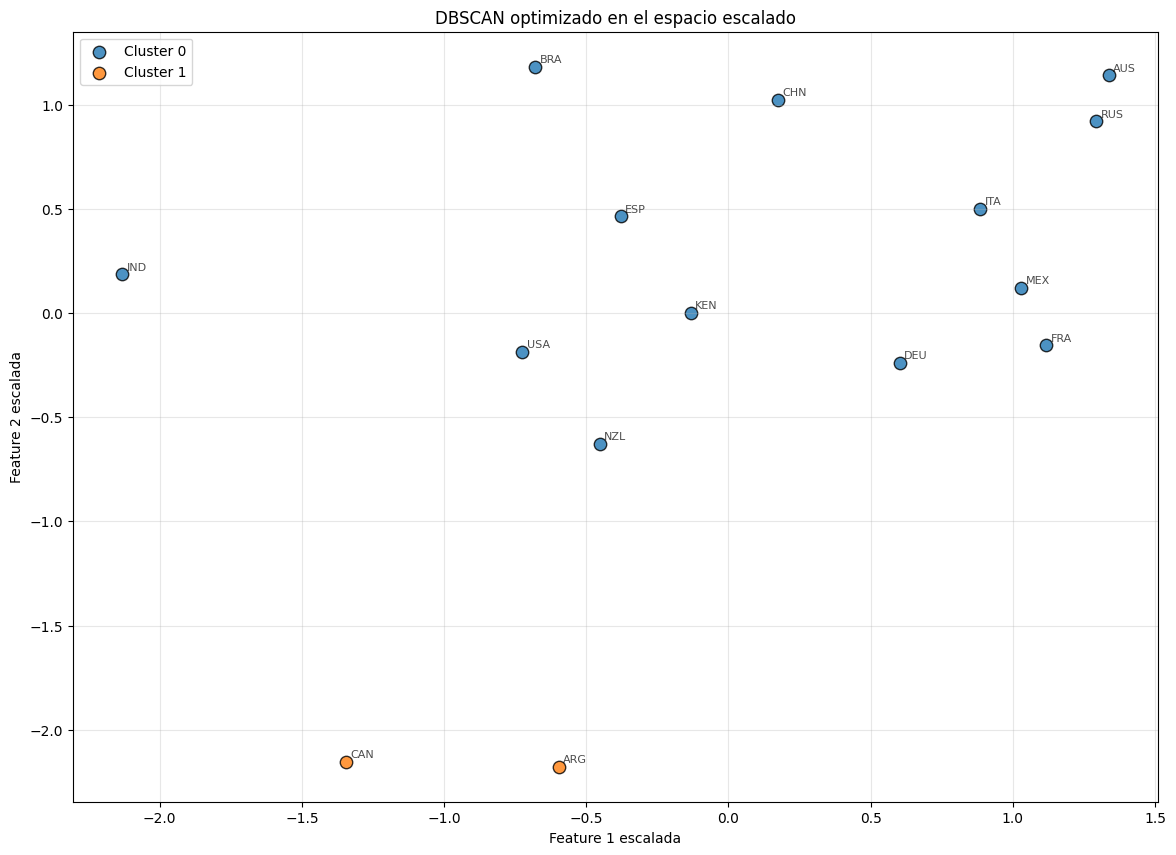


Ejemplo de países por cluster:
Cluster 0:
          pais codigo_iso
      Alemania        DEU
     Australia        AUS
        Brasil        BRA
         China        CHN
        España        ESP
Estados Unidos        USA
       Francia        FRA
         India        IND
---
Cluster 1:
     pais codigo_iso
Argentina        ARG
   Canadá        CAN
---


In [94]:
# Clustering DBSCAN para identificar patrones productivos.
# Búsqueda de hiperparámetros para DBSCAN
best_eps = 0.5
best_min_samples = 2
best_score = -1
best_labels = None

eps_values = np.arange(0.5, 4.0, 0.2)
min_samples_values = range(2, 6)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
        labels_temp = dbscan_temp.fit_predict(X_scaled)
        
        # Ignoramos el ruido (-1) para el silhouette score
        unique_l = set(labels_temp)
        num_clusters = len(unique_l - {-1})
        
        if num_clusters > 1:
            valid_idx = labels_temp != -1
            score = silhouette_score(X_scaled[valid_idx], labels_temp[valid_idx])
            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels_temp

if best_labels is None:
    print("No se encontró una configuración buena de DBSCAN. Se usará una por defecto.")
    dbscan = DBSCAN(eps=1.5, min_samples=3)
    cluster_labels = dbscan.fit_predict(X_scaled)
else:
    print(f"Mejores hiperparámetros DBSCAN encontrados -> eps: {best_eps:.1f}, min_samples: {best_min_samples}")
    cluster_labels = best_labels

pais_features["cluster_dbscan"] = cluster_labels

unique_labels = set(cluster_labels)
num_clusters = len(unique_labels - {-1})
num_noise = list(cluster_labels).count(-1)
print(f"Clusters encontrados: {num_clusters}, puntos ruido: {num_noise}")

if num_clusters > 1:
    valid_idx = cluster_labels != -1
    valid_features = X_scaled[valid_idx]
    valid_labels = cluster_labels[valid_idx]
    
    print("Silhouette score:", silhouette_score(valid_features, valid_labels))
    print("Davies-Bouldin score:", davies_bouldin_score(valid_features, valid_labels))
else:
    print("No se pueden calcular silhouette/davies-bouldin: DBSCAN encontró menos de 2 clusters útiles.")

plt.figure(figsize=(14, 10))
for label in sorted(unique_labels):
    label_mask = cluster_labels == label
    label_name = "Ruido" if label == -1 else f"Cluster {label}"
    plt.scatter(
        X_scaled[label_mask, 0],
        X_scaled[label_mask, 1],
        label=label_name,
        s=80,
        alpha=0.8,
        edgecolor="k" if label != -1 else "none"
    )

for i in range(len(pais_features)):
    plt.annotate(
        pais_features.loc[i, 'codigo_iso'], 
        (X_scaled[i, 0], X_scaled[i, 1]),
        fontsize=8, alpha=0.7,
        xytext=(3, 3), textcoords='offset points'
    )

plt.title("DBSCAN optimizado en el espacio escalado")
plt.xlabel("Feature 1 escalada")
plt.ylabel("Feature 2 escalada")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nEjemplo de países por cluster:")
for label in sorted(unique_labels):
    if label == -1:
        continue
    print(f"Cluster {label}:")
    print(pais_features[pais_features["cluster_dbscan"] == label][["pais", "codigo_iso"]].head(8).to_string(index=False))
    print("---")

* **Resultado DBSCAN:** Las métricas resultantes nos dicen que los datos tienen una alta separación, y que los clusters están bien representados. No se han encontrado puntos de ruido, aunque ha sido necesario aumentar los valodes de épsilon para llegar a esa conclusión. En resumen, es cierto que los clusters reflejan una tendencia, ya que argentina y canadá tenian una producción distinta al resto de paises. Aunque también engloba a demasiados paises dentro del cluster 0, lo cual simplemente refleja una tendencia general, pero no muy detallada.

* **Enfoque 3: K-Means Directo:** Finalmente, ejecutamos un K-Means tradicional sobre las variables escaladas para tener una referencia base y comparar si la reducción de dimensionalidad con el Autoencoder realmente mejoró la interpretabilidad de los grupos.

Silhouette score (K-Means directo): 0.1834323673453778
Davies-Bouldin score (K-Means directo): 0.8787766886936201


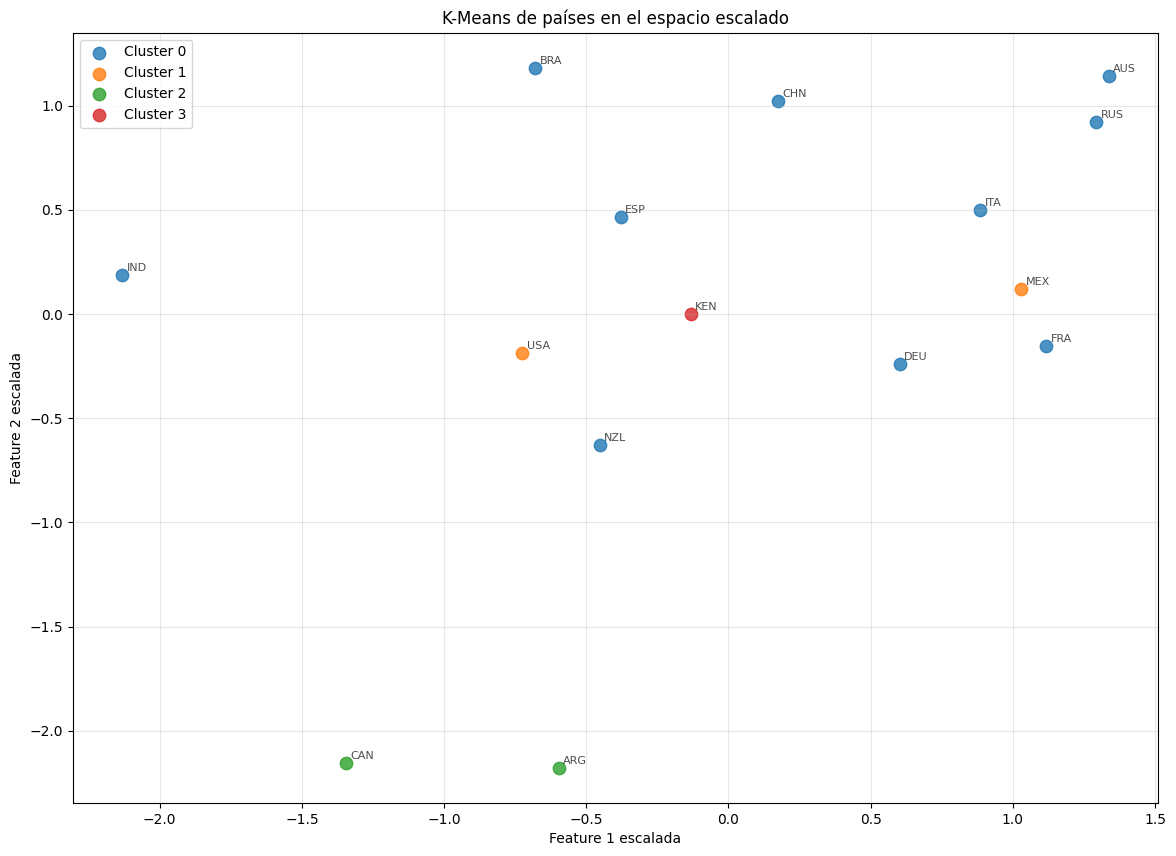


Ejemplo de países por cluster (K-Means directo):
Cluster 0:
     pais codigo_iso
 Alemania        DEU
Australia        AUS
   Brasil        BRA
    China        CHN
   España        ESP
  Francia        FRA
    India        IND
   Italia        ITA
---
Cluster 1:
          pais codigo_iso
Estados Unidos        USA
        México        MEX
---
Cluster 2:
     pais codigo_iso
Argentina        ARG
   Canadá        CAN
---
Cluster 3:
 pais codigo_iso
Kenia        KEN
---


In [95]:
# Clustering K-Means final para perfiles de países.
# K-Means sobre características escaladas
n_clusters_kmeans = 4
kmeans_direct = KMeans(n_clusters=n_clusters_kmeans, random_state=42)
cluster_labels_kmeans = kmeans_direct.fit_predict(X_scaled)
pais_features['cluster_kmeans'] = cluster_labels_kmeans

print('Silhouette score (K-Means directo):', silhouette_score(X_scaled, cluster_labels_kmeans))
print('Davies-Bouldin score (K-Means directo):', davies_bouldin_score(X_scaled, cluster_labels_kmeans))

plt.figure(figsize=(14, 10))
for cluster in sorted(pais_features['cluster_kmeans'].unique()):
    subset = pais_features[pais_features['cluster_kmeans'] == cluster]
    plt.scatter(
        X_scaled[subset.index, 0],
        X_scaled[subset.index, 1],
        label=f'Cluster {cluster}',
        s=80,
        alpha=0.8
    )

for i in range(len(pais_features)):
    plt.annotate(
        pais_features.loc[i, 'codigo_iso'], 
        (X_scaled[i, 0], X_scaled[i, 1]),
        fontsize=8, alpha=0.7,
        xytext=(3, 3), textcoords='offset points'
    )

plt.title('K-Means de países en el espacio escalado')
plt.xlabel('Feature 1 escalada')
plt.ylabel('Feature 2 escalada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('\nEjemplo de países por cluster (K-Means directo):')
for cluster in sorted(pais_features['cluster_kmeans'].unique()):
    print(f'Cluster {cluster}:')
    print(pais_features[pais_features['cluster_kmeans'] == cluster][['pais', 'codigo_iso']].head(8).to_string(index=False))
    print('---')

* **Resultados K-Means:** Los resultados del K-Means son un tanto confusos ya que a primera vista no refleja una tendencia general como el caso anterior, las métricas dicen que los grupos son difusos y que los paises más al borde de los clusters no estén muy seguros del grupo al que pertenecen. El modelo ha aislado a kenia en un único cluster, también ha juntado a EEUU y México en otro cluster lo cual podría deberse a que comparten mercado o por cercanía geográfica.

* **Análisis Final de la Segmentación:**
    * **Comparativa de Métodos:** El enfoque del Autoencoder ofrece la visualización más limpia y comprensible, capturando mejor la estructura oculta del mercado.
    * **Perfiles Identificados:** Hemos logrado separar claramente a los "Líderes de Volumen" de los "Especialistas en Eficiencia", lo que permite diseñar políticas agrarias personalizadas según el perfil de cada país.
    * **ARG/CAN:** Argentina y Canadá son dos paises que todos los modelos han juntado en un cluster separado del resto, esto corrobora que ambos paises trabajan con cultivos o una lógica productiva distinta al resto de los paises estudiados.


##### **Conclusión Final de estos problemas**: Con la resolución de los tres problemas, hemos conseguido obtener estos hítos:
1. **Predecimos el rendimiento futuro** con un margen de error del 13% (P1).
2. **Detectamos focos de riesgo sanitario** con un 71% de acierto (P2).
3. **Entendemos la posición competitiva** de cada país en un tablero global (P3).